# Deteksi Judul Berita COVID-19 yang Dipalsukan

**DAC IFEST 2026 · Babak Penyisihan · Tim cupuu**

## Deklarasi

| hal | isi |
|---|---|
| seed | `SEED = 42` untuk semua proses acak (numpy, random, LightGBM, CatBoost, XGBoost, word2vec, Optuna) |
| model pretrained | **tidak dipakai**. Semua representasi teks (TF-IDF, BM25, LSA, word2vec) dilatih dari nol di teks kompetisi |
| AutoML | **tidak dipakai**. Pemilihan algoritma kami tentukan sendiri. Optuna hanya dipakai untuk mencari hyperparameter di ruang pencarian yang kami tulis manual di bagian 9 |
| label test | tidak pernah dipakai. Semua keputusan (fitur, hyperparameter, ambang, bobot ensemble) diambil dari validasi silang di train |

### Data eksternal

Semua berkas ada di Google Drive: https://drive.google.com/drive/folders/1KMPA945I3oUNZ7BH1zgwiyNKzXXHGHpT?usp=sharing (akses publik). Notebook mencarinya di folder `data_eksternal/`.

| berkas | isi | sumber |
|---|---|---|
| `provinces.csv`, `regencies.csv`, `districts.csv` | wilayah administratif Indonesia: 34 provinsi, 514 kabupaten/kota, 7.215 kecamatan | repositori publik `github.com/edwardsamuel/Wilayah-Administratif-Indonesia` |
| `kamus_domain.csv` | 417 grup istilah: kawasan dan negara dunia, singkatan jabatan dan lembaga, tokoh publik 2020 sampai 2021, julukan media (misalnya Kebon Sirih untuk DPRD DKI) | disusun tim dari pengetahuan umum |
| `alias_wilayah.csv` | singkatan wilayah yang lazim dipakai media (Jabar, Sumsel, Solo) | disusun tim dari pengetahuan umum |

Data eksternal ini gratis, terbuka, tidak memuat label, dan tidak memuat baris test.

### Cara menjalankan

Atur `PAKAI_CACHE` di bagian 2. Run pertama menghitung semuanya (sekitar 45 menit di CPU 16 thread) dan menyimpan hasil antara ke folder `cache_final/` dalam bentuk pickle. Run berikutnya cukup memuat pickle itu sehingga selesai dalam hitungan menit dengan hasil yang identik. Set `PAKAI_CACHE = False` untuk menghitung ulang dari nol.

Keluaran ada di `output_final/` (submission, OOF, peluang test) dan semua tabel serta gambar untuk makalah ada di `laporan/`.

### Peta notebook ke makalah

| makalah | bagian notebook |
|---|---|
| Pendahuluan | 1 |
| Kajian Pustaka | 1 |
| Metodologi: data dan prapemrosesan | 3, 4, 5 |
| Metodologi: desain validasi | 6 |
| Metodologi: rekayasa fitur | 7 |
| Metodologi: pemodelan dan optimasi | 8, 9, 10 |
| Hasil dan pembahasan | 11, 12, 13, 15 |
| Rekomendasi strategis | 16 |
| Kesimpulan | 18 |

### Padanan istilah notebook dan makalah

Makalah menamai kerangka ini **TRACE** (*Token-level Replacement And Consistency Ensemble*). Padanan nama komponennya:

| di makalah | di notebook |
|---|---|
| *Multiple-Instance Replaced-Token Detection* (MI-RTD) | detektor token gaya ELECTRA (7.6) |
| *Hierarchical Domain Gazetteer* (HDG) dan *sibling-substitution prior* | kamus domain dan fitur wilayah saudara (7.5) |
| *Negation-Gap Detector* | detektor celah negasi (7.7) |
| *Generator Artifact Forensics* | jejak mesin pemalsuan (7.8) |
| *Fold-Aware Label Memory* | memori konten dan memori judul per fold (7.10) |
| *Cross-Article Headline Provenance* (S1, S2) | memori judul mirip, fitur `tmf_pos`, `tmf_neg`, `orphan` (7.10) |
| *Regime-Preserving Cross-Validation* | desain validasi 5×2 dengan memori per fold (6) |
| *Heterogeneous Calibrated Stacking* | stacking empat model (10) |
| *Pairwise Exclusivity Constraint* | aturan pasangan (7.8) |
| *noise-aware model selection* | aturan pemilihan model (10) |

## 1. Pendahuluan dan kajian pustaka

### Latar belakang

Judul adalah bagian berita yang paling banyak dibaca. Banyak orang hanya membaca judul lalu membagikannya. Judul yang tidak sesuai isinya bisa menyesatkan pembaca walaupun isi artikelnya benar, apalagi di masa pandemi ketika informasi kesehatan cepat menyebar.

Dataset kompetisi berisi pasangan judul dan konten berita COVID-19 berbahasa Indonesia dari Juli 2020 sampai Februari 2021. Kontennya selalu teks artikel asli. Yang dipalsukan adalah judulnya. Tugas kami menebak apakah judul itu asli (`1`) atau dipalsukan (`0`). Metriknya macro-F1, yaitu rata-rata F1 kelas 0 dan kelas 1.

### Kenapa tugas ini sulit

1. Judul palsu dibuat dengan perubahan kecil, misalnya mengganti satu nama tempat, tokoh, atau angka, atau menghapus kata "tidak". Kata penggantinya sering diambil dari isi artikel itu sendiri, jadi judul palsu tetap terlihat nyambung.
2. Sebagian judul palsu adalah judul asli milik artikel lain yang topiknya mirip. Judul seperti ini konsisten dengan kontennya sehingga tidak bisa ketahuan hanya dengan membaca.
3. Kelas palsu hanya sekitar 10%, sehingga ambang keputusan sangat menentukan skor.

### Manfaat dan tujuan

Sistem yang bisa menandai judul tidak sesuai isi berguna untuk redaksi berita, platform cek fakta, dan moderasi media sosial. Tujuan analisis ini:

1. memahami bagaimana judul dipalsukan lewat data train,
2. membangun model yang menangkap tiap jenis pemalsuan tanpa model pretrained,
3. menjelaskan cara kerja model, batas kemampuannya, dan cara memakainya di dunia nyata.

### Kajian pustaka ringkas

**Deteksi judul tidak kongruen.** Chesney dkk. [1] menunjukkan judul yang tidak sesuai isi adalah bentuk misinformasi tersendiri. Yoon dkk. [2] mendeteksinya dengan encoder hierarkis judul dan isi. Fake News Challenge [3] membingkainya sebagai klasifikasi sikap judul terhadap isi. Kami tidak boleh memakai model pretrained, jadi pendekatan kami berbasis fitur yang dibangun dari nol.

**Konsistensi faktual.** FactCC [4] dan CLIFF [17] melatih pendeteksi inkonsistensi dengan contoh negatif sintetis, misalnya menukar entitas. Kami menguji ide ini dan hasilnya tidak membantu di data ini (bagian 18).

**Deteksi token pengganti.** ELECTRA [5] melatih model untuk menebak token mana yang diganti. Kami meminjam gagasan ini tanpa jaringan saraf: setiap kata judul dinilai "apakah ini kata pengganti" oleh model gradient boosting. Label katanya berasal dari pasangan judul asli dan palsu di train. Untuk judul palsu yang kata penggantinya tidak diketahui, kami memakai prinsip multiple instance learning [6], yaitu judul palsu pasti punya minimal satu kata pengganti.

**Representasi teks dari nol.** TF-IDF, BM25 [14], LSA [15], dan word2vec [7] dilatih hanya dari teks kompetisi.

**Gradient boosting dan ensemble.** LightGBM [8], CatBoost [9], dan XGBoost [10] kuat untuk data tabular berisi fitur campuran. Hasilnya digabung dengan rata-rata atau stacking [16].

**Optimasi.** Hyperparameter dicari dengan Optuna [11] memakai sampler TPE [12]. Untuk ambang F1, Lipton dkk. [13] membuktikan ambang optimal sama dengan setengah F1 terbaik, sehingga pada kelas langka model perlu yakin cukup tinggi sebelum menebak kelas itu.

### Referensi

[1] S. Chesney, M. Liakata, M. Poesio, M. Purver, "Incongruent headlines: Yet another way to mislead your readers," *Proc. EMNLP Workshop NLP meets Journalism*, 2017.
[2] S. Yoon dkk., "Detecting incongruity between news headline and body text via a deep hierarchical encoder," *AAAI*, 2019.
[3] D. Pomerleau, D. Rao, "Fake News Challenge Stage 1 (FNC-1)," 2017.
[4] W. Kryściński, B. McCann, C. Xiong, R. Socher, "Evaluating the factual consistency of abstractive text summarization," *EMNLP*, 2020.
[5] K. Clark, M.-T. Luong, Q. V. Le, C. D. Manning, "ELECTRA: Pre-training text encoders as discriminators rather than generators," *ICLR*, 2020.
[6] T. G. Dietterich, R. H. Lathrop, T. Lozano-Pérez, "Solving the multiple instance problem with axis-parallel rectangles," *Artificial Intelligence*, 1997.
[7] T. Mikolov, K. Chen, G. Corrado, J. Dean, "Efficient estimation of word representations in vector space," *arXiv:1301.3781*, 2013.
[8] G. Ke dkk., "LightGBM: A highly efficient gradient boosting decision tree," *NeurIPS*, 2017.
[9] L. Prokhorenkova dkk., "CatBoost: Unbiased boosting with categorical features," *NeurIPS*, 2018.
[10] T. Chen, C. Guestrin, "XGBoost: A scalable tree boosting system," *KDD*, 2016.
[11] T. Akiba dkk., "Optuna: A next-generation hyperparameter optimization framework," *KDD*, 2019.
[12] J. Bergstra, R. Bardenet, Y. Bengio, B. Kégl, "Algorithms for hyper-parameter optimization," *NeurIPS*, 2011.
[13] Z. C. Lipton, C. Elkan, B. Narayanaswamy, "Optimal thresholding of classifiers to maximize F1 measure," *ECML PKDD*, 2014.
[14] S. Robertson, H. Zaragoza, "The probabilistic relevance framework: BM25 and beyond," *Foundations and Trends in IR*, 2009.
[15] S. Deerwester dkk., "Indexing by latent semantic analysis," *JASIS*, 1990.
[16] D. H. Wolpert, "Stacked generalization," *Neural Networks*, 1992.
[17] S. Cao, L. Wang, "CLIFF: Contrastive learning for improving faithfulness and factuality in abstractive summarization," *EMNLP*, 2021.

## 2. Setup

Semua pengaturan ada di sel ini. Fungsi `cache` menyimpan hasil tahap yang berat ke pickle supaya run kedua tinggal memuat. Fungsi `simpan_gambar` dan `simpan_tabel` mengekspor bahan makalah ke `laporan/`.

Catatan reproducibility: urutan iterasi `set` di Python berubah antar proses, jadi setiap penjumlahan di atas himpunan memakai `sorted()` atau `math.fsum`. LightGBM memakai `deterministic=True`, word2vec memakai satu worker dengan fungsi hash tetap, dan Optuna memakai sampler dengan seed.

In [1]:
import os, re, sys, json, math, time, random, pickle, hashlib, difflib, zlib, warnings, platform, itertools
import unicodedata, unicodedata as ud
from collections import Counter, defaultdict
import numpy as np, pandas as pd
import scipy.sparse as sp
from scipy.stats import ks_2samp
import sklearn, lightgbm as lgb, catboost as cb, xgboost as xgb, optuna, gensim
import matplotlib, matplotlib.pyplot as plt, seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import (f1_score, roc_auc_score, average_precision_score as APS, confusion_matrix,
                             log_loss, precision_recall_curve)
from sklearn.calibration import calibration_curve
from gensim.models import Word2Vec
from rapidfuzz import process as rfp
from rapidfuzz.distance import Levenshtein as LEV
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.width', 180); pd.set_option('display.max_columns', 40); pd.set_option('display.max_colwidth', 90)

NAMA_TIM = 'cupuu'
SEED = 42
PAKAI_CACHE = True
N_SPLITS, N_REPEATS = 5, 2
N_TRIALS = {'lightgbm': 30, 'xgboost': 30, 'catboost': 20, 'logreg': 20}
N_THREADS = max(1, (os.cpu_count() or 2) - 1)
random.seed(SEED); np.random.seed(SEED)

def cari_folder(nama_berkas, kandidat):
    for d in kandidat:
        if not os.path.isdir(d): continue
        for r, _, fs in os.walk(d):
            if all(f in fs for f in nama_berkas): return r
    raise FileNotFoundError(f'{nama_berkas} tidak ditemukan')
DATA_DIR = cari_folder(['train.csv', 'test.csv'], ['../data baru', 'data baru', '/kaggle/input'])
EXT_DIR = cari_folder(['kamus_domain.csv', 'provinces.csv'], ['data_eksternal', '../model/data_eksternal', '/kaggle/input'])
DI_KAGGLE = DATA_DIR.startswith('/kaggle')
OUT_DIR = '/kaggle/working/output_final' if DI_KAGGLE else 'output_final'
CACHE_DIR = '/kaggle/working/cache_final' if DI_KAGGLE else 'cache_final'
LAPORAN_DIR = '/kaggle/working/laporan' if DI_KAGGLE else 'laporan'
for d in [OUT_DIR, CACHE_DIR, os.path.join(LAPORAN_DIR, 'gambar'), os.path.join(LAPORAN_DIR, 'tabel')]:
    os.makedirs(d, exist_ok=True)

T0 = time.time(); TIMES = {}
class Timer:
    def __init__(s, n): s.n = n
    def __enter__(s): s.t = time.time(); return s
    def __exit__(s, *a):
        TIMES[s.n] = TIMES.get(s.n, 0) + time.time() - s.t
        print(f'[{s.n}] {time.time() - s.t:.1f}s')

def cache(nama, fungsi):
    p = os.path.join(CACHE_DIR, f'{nama}.pkl')
    if PAKAI_CACHE and os.path.exists(p):
        with open(p, 'rb') as f: obj = pickle.load(f)
        print(f'[cache] {nama} dimuat')
        return obj
    with Timer(nama): obj = fungsi()
    with open(p, 'wb') as f: pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    return obj

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight', 'font.size': 10})
def simpan_gambar(nama):
    for ext in ('png', 'pdf'): plt.savefig(os.path.join(LAPORAN_DIR, 'gambar', f'{nama}.{ext}'))
    plt.show()
def simpan_tabel(df, nama, index=True, desimal=4):
    df.to_csv(os.path.join(LAPORAN_DIR, 'tabel', f'{nama}.csv'), index=index)
    with open(os.path.join(LAPORAN_DIR, 'tabel', f'{nama}.tex'), 'w', encoding='utf-8') as f:
        f.write(df.round(desimal).to_latex(index=index, escape=True))
    return df

VERSI = {'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__, 'scikit-learn': sklearn.__version__,
         'lightgbm': lgb.__version__, 'catboost': cb.__version__, 'xgboost': xgb.__version__, 'optuna': optuna.__version__,
         'gensim': gensim.__version__, 'matplotlib': matplotlib.__version__}
print(VERSI)
print('data:', DATA_DIR, '| eksternal:', EXT_DIR, '| output:', OUT_DIR, '| cache:', CACHE_DIR, '| threads:', N_THREADS)

{'python': '3.13.1', 'numpy': '2.2.1', 'pandas': '2.2.3', 'scikit-learn': '1.6.1', 'lightgbm': '4.6.0', 'catboost': '1.2.8', 'xgboost': '3.0.0', 'optuna': '4.4.0', 'gensim': '4.4.0', 'matplotlib': '3.10.0'}
data: ../data baru | eksternal: data_eksternal | output: output_final | cache: cache_final | threads: 15


## 3. Data dan kualitas data

Kami mulai dari pemeriksaan dasar: ukuran, sebaran label, nilai kosong, duplikat, dan teks yang panjangnya tidak wajar.

In [2]:
tr = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
te = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
sample = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv')) \
    if os.path.exists(os.path.join(DATA_DIR, 'sample_submission.csv')) else te[['id']].assign(label=1)

def nh(s):
    return re.sub(r'\s+', ' ', unicodedata.normalize('NFKC', str(s)).lower()).strip()

ALL = pd.concat([tr.assign(is_test=0), te.assign(is_test=1, label=-1)], ignore_index=True)
ALL['th'] = ALL.title.map(nh); ALL['ch'] = ALL.content.map(nh)
NTR, NTE = len(tr), len(te)
Y = tr.label.values.astype(int)
Y0 = 1 - Y
TH, CH = ALL.th.values, ALL.ch.values
print(tr.head(3).assign(content=tr.content.head(3).str[:110] + ' ...').to_string())
simpan_tabel(pd.DataFrame({'baris': [NTR, NTE], 'kolom': [tr.shape[1], te.shape[1]],
                           'label 1 (asli)': [int((Y == 1).sum()), np.nan], 'label 0 (palsu)': [int((Y == 0).sum()), np.nan],
                           'porsi label 0': [Y0.mean(), np.nan]}, index=['train', 'test']), 'ringkasan_data')

        id                                                                                            title                                                                                                             content  label
0  tr00000                                     Tak Lagi Jadi Jubir Yurianto Tak Umumkan Update Harian Covid  Ada perubahan besar besaran dalam pemaparan data harian perkembangan virus corona Covid 19 di Indonesia Selasa ...      0
1  tr00001  Aturan Swab PCR Bagi Penumpang Pesawat ke Kalbar Diperpanjang hingga 28 Februari   kumparan com  Aturan Swab PCR Bagi Penumpang Pesawat ke Kalbar Diperpanjang hingga 28 FebruariHi Pontianak   Pemerintah Prov ...      1
2  tr00002                                      Tim Riset Vaksin Sinovac Siapkan Laporan Perdana Uji Klinis  Tim riset dari Fakultas Kedokteran Universitas Padjadjaran FK Unpad bakal merampungkan laporan perdana terkait ...      1


,baris,kolom,label 1 (asli),label 0 (palsu),porsi label 0
train,14397,4,12960.0,1437.0,0.099812
test,3603,3,NaN,NaN,NaN


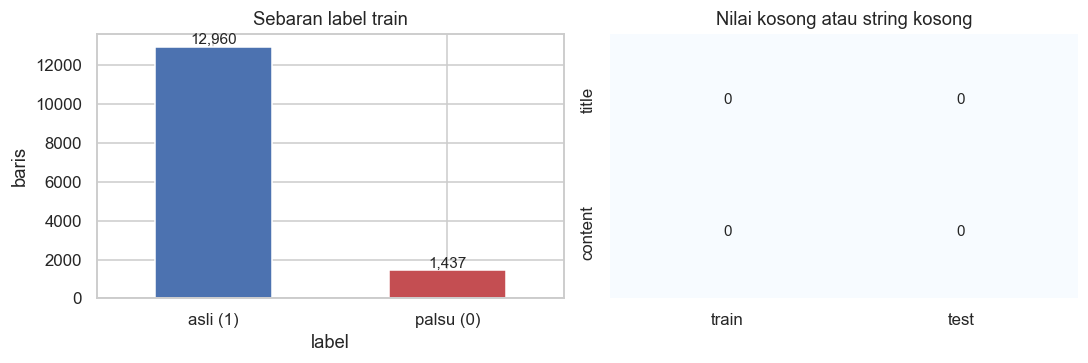

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
tr.label.map({1: 'asli (1)', 0: 'palsu (0)'}).value_counts().plot.bar(ax=ax[0], color=['#4C72B0', '#C44E52'], rot=0)
ax[0].set_title('Sebaran label train'); ax[0].set_ylabel('baris')
for p in ax[0].patches: ax[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
kosong = pd.DataFrame({k: [d[c].isna().sum() + (d[c].astype(str).str.strip() == '').sum() for c in ['title', 'content']]
                       for k, d in [('train', tr), ('test', te)]}, index=['title', 'content'])
sns.heatmap(kosong, annot=True, fmt='d', cbar=False, cmap='Blues', ax=ax[1]); ax[1].set_title('Nilai kosong atau string kosong')
plt.tight_layout(); simpan_gambar('01_label_dan_kosong')

Tidak ada nilai kosong, jadi tidak perlu imputasi. Kelas palsu hanya sekitar 10%, sehingga metrik macro-F1 akan sangat dipengaruhi seberapa baik kelas kecil ini ditangkap.

### 3.1 Duplikat

Duplikat di sini bukan kesalahan data. Satu konten bisa muncul beberapa kali dengan judul berbeda, yaitu judul asli dan judul palsunya. Pola ini justru informasi penting, jadi duplikat tidak dibuang.

In [4]:
ALL['n_pair'] = ALL.groupby(['th', 'ch']).th.transform('size')
ALL['n_ch'] = ALL.ch.map(ALL.ch.value_counts()).values
ALL['nt_ch'] = ALL.ch.map(ALL.groupby('ch').th.nunique()).values
ALL['n_th'] = ALL.th.map(ALL.th.value_counts()).values
ALL['nc_th'] = ALL.th.map(ALL.groupby('th').ch.nunique()).values
T_ = ALL.iloc[:NTR]
dup = pd.DataFrame({
    'pasangan (judul, konten) muncul lebih dari sekali': [int((T_.n_pair > 1).sum()), int((ALL.iloc[NTR:].n_pair > 1).sum())],
    'konten muncul lebih dari sekali': [int((T_.n_ch > 1).sum()), int((ALL.iloc[NTR:].n_ch > 1).sum())],
    'konten punya lebih dari satu judul': [int((T_.nt_ch > 1).sum()), int((ALL.iloc[NTR:].nt_ch > 1).sum())],
    'judul dipakai untuk lebih dari satu konten': [int((T_.nc_th > 1).sum()), int((ALL.iloc[NTR:].nc_th > 1).sum())]},
    index=['train', 'test']).T
dup['porsi label 0 (train)'] = [Y0[(T_.n_pair > 1).values].mean(), Y0[(T_.n_ch > 1).values].mean(),
                                Y0[(T_.nt_ch > 1).values].mean(), Y0[(T_.nc_th > 1).values].mean()]
simpan_tabel(dup, 'duplikat')

,train,test,porsi label 0 (train)
"pasangan (judul, konten) muncul lebih dari sekali",4547,1185,0.001759
konten muncul lebih dari sekali,6392,1622,0.171308
konten punya lebih dari satu judul,2381,563,0.458631
judul dipakai untuk lebih dari satu konten,296,66,0.472973


### 3.2 Panjang teks dan outlier

Panjang judul dan konten dibandingkan antar label. Teks yang sangat pendek atau sangat panjang kami periksa sebagai calon outlier.

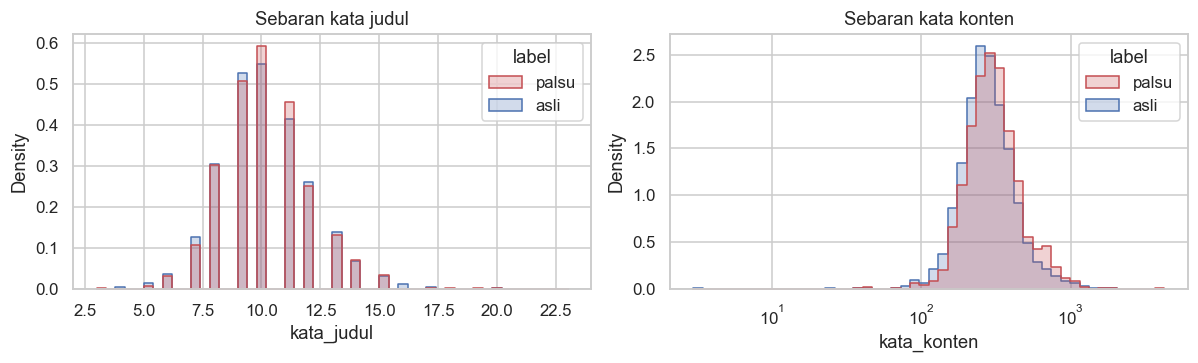

label                 asli   palsu    test
kata_judul  count  12960.0  1437.0  3603.0
            mean      10.1    10.1    10.1
            std        2.0     1.9     2.0
            min        3.0     3.0     3.0
            25%        9.0     9.0     9.0
            50%       10.0    10.0    10.0
            75%       11.0    11.0    11.0
            max       23.0    20.0    23.0
kata_konten count  12960.0  1437.0  3603.0
            mean     306.9   337.3   303.5
            std      166.2   195.5   144.8
            min        3.0    37.0     3.0
            25%      217.0   233.0   216.0
            50%      273.0   297.0   275.0
            75%      353.0   381.0   355.0
            max     4238.0  4238.0  1782.0


,train,test,porsi label 0 (train)
konten < 30 kata,19,8,0.000000
konten > 1500 kata,21,1,0.142857
konten placeholder video,2142,508,0.109244
judul < 5 kata,35,10,0.028571
judul > 20 kata,7,1,0.000000


In [5]:
LEN = pd.DataFrame({'kata_judul': ALL.title.str.split().str.len(), 'kata_konten': ALL.content.str.split().str.len(),
                    'label': ALL.label.map({1: 'asli', 0: 'palsu', -1: 'test'})})
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for k, c in enumerate(['kata_judul', 'kata_konten']):
    d = LEN[LEN.label != 'test']
    sns.histplot(d, x=c, hue='label', stat='density', common_norm=False, bins=50, log_scale=(c == 'kata_konten'),
                 element='step', ax=ax[k], palette={'asli': '#4C72B0', 'palsu': '#C44E52'})
    ax[k].set_title(f'Sebaran {c.replace("_", " ")}')
plt.tight_layout(); simpan_gambar('02_panjang_teks')
print(LEN.groupby('label')[['kata_judul', 'kata_konten']].describe().T.round(1).to_string())

k_ = LEN.kata_konten.values
OUTLIER = pd.DataFrame({
    'konten < 30 kata': k_ < 30, 'konten > 1500 kata': k_ > 1500,
    'konten placeholder video': ALL.ch.str.contains('gambas video').values,
    'judul < 5 kata': LEN.kata_judul.values < 5, 'judul > 20 kata': LEN.kata_judul.values > 20})
out_tab = pd.DataFrame({'train': OUTLIER.iloc[:NTR].sum(), 'test': OUTLIER.iloc[NTR:].sum(),
                        'porsi label 0 (train)': [Y0[OUTLIER.iloc[:NTR][c].values].mean() if OUTLIER.iloc[:NTR][c].any() else np.nan for c in OUTLIER]})
simpan_tabel(out_tab, 'outlier')

### 3.3 Tanda baca sudah dibuang

Panitia membuang tanda baca dari judul maupun konten. Konsekuensinya penting untuk rekayasa fitur: angka seperti "1.484" menjadi "1 484", sehingga token angka yang bersebelahan perlu disatukan saat dibandingkan.

In [6]:
tb = pd.DataFrame({k: [ALL[c].iloc[s].str.contains(r'[^\w\s]').mean() for c in ['title', 'content']]
                   for k, s in [('train', slice(0, NTR)), ('test', slice(NTR, None))]}, index=['judul', 'konten'])
print('porsi teks yang masih mengandung tanda baca:'); print(tb.round(4))
print('contoh angka terpisah:', ALL.content[ALL.content.str.contains(r'\b\d{1,3} \d{3}\b')].str.extract(r'(\b\d{1,3} \d{3}\b)')[0].head(5).tolist())

porsi teks yang masih mengandung tanda baca:
         train    test
judul   0.0027  0.0031
konten  0.0401  0.0505


contoh angka terpisah: ['1 665', '1 620', '7 371', '1 000', '4 392']


**Penanganan kualitas data.**

1. Nilai kosong tidak ada, jadi tidak ada imputasi.
2. Duplikat dipertahankan karena memberi informasi struktur. Konten yang punya beberapa judul biasanya berisi satu judul asli dan judul palsunya.
3. Teks yang sangat pendek, sangat panjang, atau berisi placeholder video tetap dipakai. Kelompok ini nyata ada di data dan juga muncul di test, jadi membuangnya hanya membuat model buta terhadap kasus itu. Model berbasis pohon juga tidak terganggu nilai ekstrem karena hanya melihat urutan nilai.
4. Tanda baca yang hilang ditangani di prapemrosesan (bagian 5).

## 4. Eksplorasi data (EDA)

Bagian ini mencari tahu bagaimana judul dipalsukan. Semua perhitungan hanya memakai teks train dan test serta label train.

### 4.1 Membaca saja tidak cukup

Cara paling sederhana adalah mengukur seberapa banyak kata judul yang ada di konten. Kami juga mencoba baseline klasik TF-IDF dengan regresi logistik.

[baseline tfidf] 31.5s


AUC overlap kata judul terhadap label palsu: 0.6053
AUC TF-IDF + regresi logistik: 0.5469


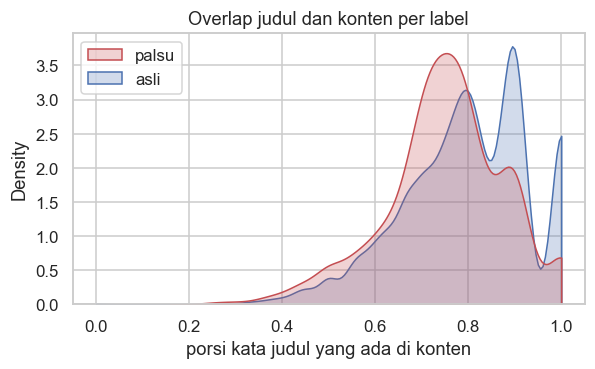

In [7]:
def f1_terbaik(y, p_asli):
    grid = np.linspace(0.02, 0.98, 97)
    return max(f1_score(y, (p_asli >= t).astype(int), average='macro') for t in grid)

cov_judul = np.array([np.mean([w in set(c.split()) for w in t.split()]) if t.split() else 0 for t, c in zip(TH, CH)])
with Timer('baseline tfidf'):
    tv = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2), max_features=200000, dtype=np.float32)
    tv.fit(pd.concat([tr.title, tr.content]))
    Xbl = sp.hstack([tv.transform(tr.title), tv.transform(tr.content)]).tocsr()
    P_TFIDF = np.zeros(NTR)
    for a, b in StratifiedKFold(5, shuffle=True, random_state=SEED).split(Xbl, Y):
        P_TFIDF[b] = LogisticRegression(C=4, max_iter=3000, class_weight='balanced').fit(Xbl[a], Y[a]).predict_proba(Xbl[b])[:, 1]
BASELINE = {'tebak semua asli': f1_score(Y, np.ones(NTR, int), average='macro'),
            'overlap kata judul di konten': f1_terbaik(Y, cov_judul[:NTR]),
            'TF-IDF + regresi logistik': f1_terbaik(Y, P_TFIDF)}
print('AUC overlap kata judul terhadap label palsu:', round(roc_auc_score(Y0, -cov_judul[:NTR]), 4))
print('AUC TF-IDF + regresi logistik:', round(roc_auc_score(Y0, -P_TFIDF), 4))
simpan_tabel(pd.Series(BASELINE, name='macro-F1 (CV 5 fold)').to_frame(), 'baseline_awal')

fig, ax = plt.subplots(figsize=(6, 3.2))
sns.kdeplot(x=cov_judul[:NTR], hue=np.where(Y == 1, 'asli', 'palsu'), common_norm=False, fill=True, ax=ax,
            palette={'asli': '#4C72B0', 'palsu': '#C44E52'}, clip=(0, 1))
ax.set_xlabel('porsi kata judul yang ada di konten'); ax.set_title('Overlap judul dan konten per label')
simpan_gambar('03_overlap_judul_konten')

Overlap kata hampir tidak membedakan judul asli dan palsu, dan TF-IDF hanya sedikit di atas menebak semua asli. Judul palsu sering memakai kata yang juga ada di konten, jadi pendekatan bag-of-words tidak cukup. Kami perlu memahami cara pemalsuannya.

### 4.2 Test adalah sampel acak per baris

Kalau test diambil acak dari data yang sama, pasangan (judul, konten) yang muncul tepat dua kali akan terbagi ke train dan test mengikuti peluang binomial. Kalau jumlah aktualnya cocok, validasi silang acak adalah simulasi yang tepat untuk test. Ini dasar desain validasi di bagian 6.

In [8]:
pair_n = ALL.groupby(['th', 'ch']).size()
kembar = ALL[ALL.n_pair == 2].groupby(['th', 'ch']).is_test.sum().value_counts().sort_index()
p_ = NTE / len(ALL); n2 = int((pair_n == 2).sum())
simpan_tabel(pd.DataFrame({'aktual': kembar.values, 'harapan bila acak': [n2 * (1 - p_) ** 2, 2 * n2 * p_ * (1 - p_), n2 * p_ * p_]},
                          index=['train-train', 'train-test', 'test-test']).round(0), 'uji_sampel_acak')

,aktual,harapan bila acak
train-train,1810,1833.0
train-test,927,918.0
test-test,129,115.0


### 4.3 Label menurut pola struktur

Berapa judul yang dimiliki sebuah konten ternyata sangat menentukan label.

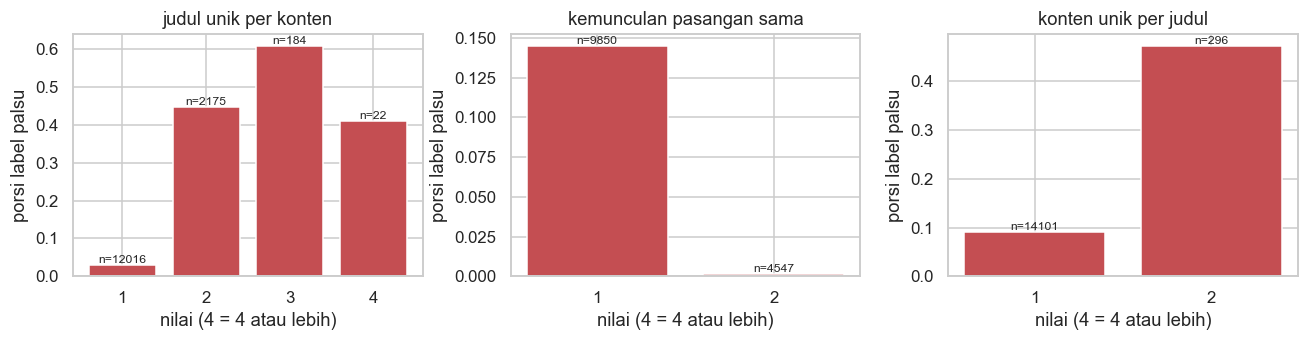

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
for k, (c, j) in enumerate([('nt_ch', 'judul unik per konten'), ('n_pair', 'kemunculan pasangan sama'), ('nc_th', 'konten unik per judul')]):
    t_ = pd.DataFrame({'x': ALL[c].values[:NTR].clip(max=4), 'y0': Y0}).groupby('x').y0.agg(['mean', 'size'])
    ax[k].bar(t_.index.astype(str), t_['mean'], color='#C44E52')
    for i, (m, n) in enumerate(zip(t_['mean'], t_['size'])): ax[k].text(i, m, f'n={n}', ha='center', va='bottom', fontsize=8)
    ax[k].set_title(j); ax[k].set_ylabel('porsi label palsu'); ax[k].set_xlabel('nilai (4 = 4 atau lebih)')
plt.tight_layout(); simpan_gambar('04_label_per_struktur')

Konten yang muncul sekali dengan satu judul hampir selalu asli, sedangkan konten dengan dua judul biasanya berisi satu asli dan satu palsu. Pasangan yang muncul kembar hampir selalu asli. Pola ini dimanfaatkan lewat fitur struktural, saudara, dan memori di bagian 7.

### 4.4 Sensus pemalsuan pada pasangan minimal

Konten yang di train punya tepat satu judul asli dan beberapa judul palsu memperlihatkan persis bagaimana judul dipalsukan. Kami bandingkan judul asli dan palsunya kata per kata.

pasangan minimal: 911 | {'yang dihapus kata negasi': 101, 'kata asli ada di konten': 647, 'kata pengganti ada di konten': 339}
                      jenis                                                      judul asli                                                  judul palsu
        hapus kata (negasi) Targetkan Bangun 25 RS hingga 2035 Ridwan Kamil Bukan Dana APBD    Targetkan Bangun 25 RS hingga 2035 Ridwan Kamil Dana APBD
ganti kata (entitas, angka) Gubernur Koster Siap jadi Orang Pertama Divaksin Corona di Bali Kapolda Bali Siap jadi Orang Pertama Divaksin Corona di Bali
   judul milik artikel lain             Pemerintah Ubah Skema Pengumuman Data Harian Corona Tak Lagi Jadi Jubir Yurianto Tak Umumkan Update Harian Covid
                 sisip kata        Dokter Sebut Virus Corona Bisa Bertahan 5 Hari di Ponsel Dokter Sebut Virus Corona tak Bisa Bertahan 5 Hari di Ponsel


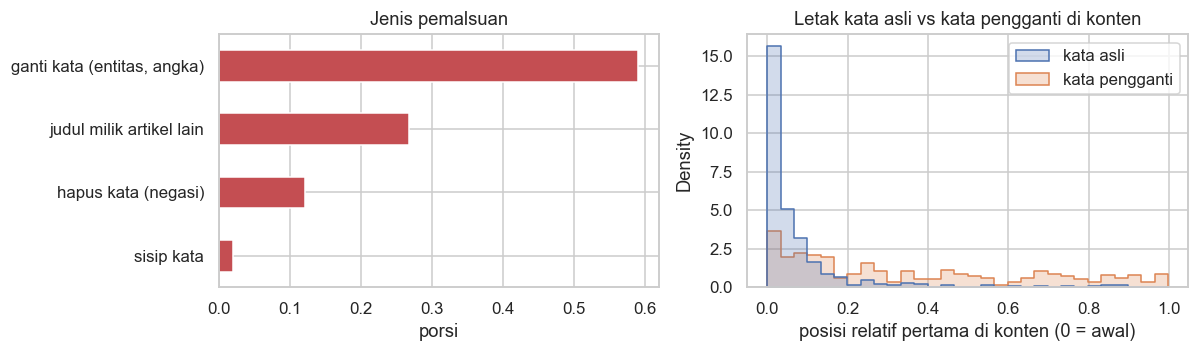

median posisi: kata asli 0.031 | kata pengganti 0.269


In [10]:
D = tr.assign(th=TH[:NTR], ch=CH[:NTR]).drop_duplicates(['th', 'ch'])
PAIRS = []
for c, g in D.groupby('ch'):
    p1, p0 = g[g.label == 1], g[g.label == 0]
    if len(p1) == 1:
        for _, r in p0.iterrows():
            PAIRS.append((p1.iloc[0].title, r.title, g.iloc[0].content))
jenis = Counter(); pos_asli, pos_sisip = [], []; ada = Counter(); JENIS_KEY = {}; CONTOH = {}
for a, b, c in PAIRS:
    A, B = a.lower().split(), b.lower().split(); Cl = c.lower().split(); Cp = {}
    for i, w in enumerate(Cl): Cp.setdefault(w, i)
    sm = difflib.SequenceMatcher(None, A, B)
    ops = [o for o in sm.get_opcodes() if o[0] != 'equal']
    rem = [w for o in ops for w in A[o[1]:o[2]]]; add = [w for o in ops for w in B[o[3]:o[4]]]
    j = 'judul_lain' if sm.ratio() < 0.5 else ('hapus' if rem and not add else ('sisip' if add and not rem else 'ganti'))
    jenis[j] += 1; JENIS_KEY[(nh(b), nh(c))] = j; CONTOH.setdefault(j, (a, b))
    if j == 'ganti':
        for w in rem:
            ada['kata asli ada di konten'] += w in Cp
            if w in Cp: pos_asli.append(Cp[w] / len(Cl))
        for w in add:
            ada['kata pengganti ada di konten'] += w in Cp
            if w in Cp: pos_sisip.append(Cp[w] / len(Cl))
    if j == 'hapus': ada['yang dihapus kata negasi'] += any(w in ('tak', 'tidak', 'bukan', 'belum') for w in rem)
MUT_P = {k: v / sum(jenis.values()) for k, v in jenis.items()}
NAMA_JENIS = {'ganti': 'ganti kata (entitas, angka)', 'judul_lain': 'judul milik artikel lain', 'hapus': 'hapus kata (negasi)', 'sisip': 'sisip kata'}
sensus = pd.DataFrame({'pasangan': pd.Series(jenis), 'porsi': pd.Series(MUT_P)}).rename(index=NAMA_JENIS).sort_values('pasangan', ascending=False)
simpan_tabel(sensus, 'sensus_mutasi')
print('pasangan minimal:', len(PAIRS), '|', dict(ada))
contoh = pd.DataFrame([(NAMA_JENIS[j], a, b) for j, (a, b) in CONTOH.items()], columns=['jenis', 'judul asli', 'judul palsu'])
simpan_tabel(contoh, 'contoh_mutasi', index=False)
print(contoh.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
sensus.porsi.plot.barh(ax=ax[0], color='#C44E52'); ax[0].invert_yaxis(); ax[0].set_title('Jenis pemalsuan'); ax[0].set_xlabel('porsi')
sns.histplot({'kata asli': pos_asli, 'kata pengganti': pos_sisip}, stat='density', common_norm=False, bins=30, element='step', ax=ax[1])
ax[1].set_xlabel('posisi relatif pertama di konten (0 = awal)'); ax[1].set_title('Letak kata asli vs kata pengganti di konten')
plt.tight_layout(); simpan_gambar('05_sensus_mutasi')
print(f'median posisi: kata asli {np.median(pos_asli):.3f} | kata pengganti {np.median(pos_sisip):.3f}')

Ada empat jenis pemalsuan. Yang terbanyak adalah **mengganti satu kata**, biasanya nama tempat, tokoh, lembaga, atau angka. Kata aslinya hampir selalu muncul di awal konten, sedangkan kata penggantinya kalau ada di konten letaknya jauh di belakang. Jenis kedua adalah **judul milik artikel lain** yang topiknya mirip. Jenis ketiga adalah **menghapus kata negasi** sehingga makna judul terbalik. Temuan ini menjadi dasar detektor token dan detektor celah negasi di bagian 7.

### 4.5 Jejak mesin pemalsuan pada spasi

Judul asli yang semula bertanda baca, misalnya titik dua, menyisakan spasi ganda setelah tanda bacanya dibuang. Mesin pemalsuan menyambung ulang kata dengan spasi tunggal, sehingga judul palsu tidak pernah berspasi ganda.

In [11]:
sp_tab = pd.DataFrame({
    'judul berspasi ganda': [int(tr.title.str.contains('  ').sum()), Y0[tr.title.str.contains('  ').values].mean()],
    'konten berspasi ganda': [int(tr.content.str.contains('  ').sum()), Y0[tr.content.str.contains('  ').values].mean()],
    'semua baris train': [NTR, Y0.mean()]}, index=['baris', 'porsi label palsu']).T
simpan_tabel(sp_tab, 'jejak_spasi')

,baris,porsi label palsu
judul berspasi ganda,5300.0,0.000000
konten berspasi ganda,6541.0,0.000000
semua baris train,14397.0,0.099812


## 5. Prapemrosesan

Langkahnya sengaja ringan karena detail kecil seperti spasi dan huruf kapital justru membawa sinyal.

1. **Normalisasi kunci identitas.** Unicode NFKC, huruf kecil, spasi dirapikan. Dipakai untuk mengenali judul atau konten yang sama.
2. **Tokenisasi.** Pisah per spasi dalam huruf kecil. Teks asli tetap disimpan untuk fitur spasi dan kapital.
3. **Kata umum dan negasi.** Daftar kata umum (stopword) dan kata negasi disusun manual.
4. **Pengupasan akar kata.** Imbuhan umum dikupas supaya "pelanggar" dan "langgar" dianggap sama.
5. **Statistik korpus.** IDF dan tingkat kapital tiap kata dihitung dari seluruh konten unik tanpa label. Karena judul memakai huruf kapital di setiap kata, sebuah kata dianggap entitas bila di konten ia sering ditulis kapital.
6. **Penggabungan angka.** Token angka yang bersebelahan disatukan sebelum dibandingkan karena tanda baca pemisah ribuan sudah hilang.

In [12]:
UC = ALL.drop_duplicates('ch')[['ch', 'content']].reset_index(drop=True)
NEG = {'tidak', 'tak', 'bukan', 'belum', 'tanpa', 'jangan'}
NEGW = NEG | {'enggan', 'batal', 'gagal', 'urung', 'tiada'}
STOP = set('''yang dan di ke dari untuk pada dengan itu ini akan telah sudah adalah oleh dalam
karena juga bisa dapat saat ada atau jadi hingga agar bagi sebagai para kata ujar tutur sebut
lebih masih harus kami kita saya ia dia mereka se usai jelang soal lagi baru kini'''.split())
_AW = ('menyeng', 'meng', 'meny', 'peng', 'peny', 'mem', 'men', 'pem', 'pen', 'ber', 'ter', 'per', 'me', 'pe', 'di', 'ke', 'se')
_AK = ('kannya', 'annya', 'nya', 'kan', 'an', 'i')
def akar(w):
    for p in _AW:
        if w.startswith(p) and len(w) - len(p) >= 4: w = w[len(p):]; break
    for s in _AK:
        if w.endswith(s) and len(w) - len(s) >= 4: w = w[:-len(s)]; break
    return w

with Timer('statistik korpus'):
    df_cnt = Counter(); cap = Counter(); tot = Counter()
    for c in UC.content:
        ws = c.split()
        df_cnt.update(set(w.lower() for w in ws))
        for w in ws:
            wl = w.lower(); tot[wl] += 1
            if w[:1].isupper(): cap[wl] += 1
    NU = len(UC)
    IDF = {w: math.log((NU + 1) / (d + 1)) + 1 for w, d in df_cnt.items()}
    IDF_UNK = math.log(NU + 1) + 1
    CAP = {w: cap[w] / tot[w] for w in tot if tot[w] >= 3}
def is_ent(w): return (not w.isdigit()) and CAP.get(w, 0) >= 0.6

_CI = {}
def cinfo(ch, content):
    x = _CI.get(ch)
    if x is None:
        cl = content.lower().split(); pos = {}; cnt = Counter(cl)
        for i, w in enumerate(cl): pos.setdefault(w, i)
        big = set(zip(cl, cl[1:])); nxt = defaultdict(set); prv = defaultdict(set)
        for a, b in zip(cl, cl[1:]): nxt[a].add(b); prv[b].add(a)
        negbr = set(); negd = set()
        for i, w in enumerate(cl):
            if w in NEG:
                if 0 < i < len(cl) - 1: negbr.add((cl[i - 1], cl[i + 1]))
                for k in (1, 2):
                    if i + k < len(cl): negd.add(cl[i + k])
        x = dict(cl=cl, n=max(len(cl), 1), pos=pos, cnt=cnt, big=big, nxt=nxt, prv=prv,
                 negbr=negbr, negd=negd, text=' ' + ' '.join(cl) + ' ')
        _CI[ch] = x
    return x

def salience(tokens, ci):
    if not tokens: return 0.0
    s = []
    for w in sorted(tokens):
        if w in ci['pos']:
            s.append(0.7 * (1 - ci['pos'][w] / ci['n']) + 0.3 * min(math.log1p(ci['cnt'][w]) / 3, 1))
        else:
            s.append(-1.0)
    return math.fsum(s) / len(s)

demo = pd.DataFrame({
    'contoh': ['Kasus  Covid  di JABAR Naik', 'pelanggar', 'melanggar', 'pemeriksaan', 'jakarta', 'positif'],
    'hasil': [nh('Kasus  Covid  di JABAR Naik'), akar('pelanggar'), akar('melanggar'), akar('pemeriksaan'),
              f'kapital {CAP.get("jakarta", 0):.2f} -> entitas {is_ent("jakarta")}', f'kapital {CAP.get("positif", 0):.2f} -> entitas {is_ent("positif")}']},
    index=['normalisasi', 'akar kata', 'akar kata', 'akar kata', 'deteksi entitas', 'deteksi entitas'])
print(demo.to_string())
print(f'konten unik {NU} | kosakata {len(tot)} | kata entitas {sum(is_ent(w) for w in CAP)}')

[statistik korpus] 4.7s
                                      contoh                          hasil
normalisasi      Kasus  Covid  di JABAR Naik      kasus covid di jabar naik
akar kata                          pelanggar                        langgar
akar kata                          melanggar                        langgar
akar kata                        pemeriksaan                         eriksa
deteksi entitas                      jakarta   kapital 0.99 -> entitas True
deteksi entitas                      positif  kapital 0.01 -> entitas False
konten unik 13781 | kosakata 63343 | kata entitas 11928


## 6. Formulasi masalah dan desain validasi

**Formulasi.** Untuk setiap baris $i$ dengan judul $t_i$ dan konten $c_i$, model menghasilkan peluang judul asli $p_i = P(y_i = 1 \mid t_i, c_i, \mathcal{D})$. Di sini $\mathcal{D}$ adalah seluruh teks yang tersedia beserta label train. Tebakan akhirnya $\hat y_i = 1$ bila $p_i \ge \tau$, lalu beberapa aturan keras yang terbukti di train boleh menimpa tebakan itu.

**Metrik.** Macro-F1 $= (F1_0 + F1_1)/2$. Karena kelas palsu hanya 10%, $F1_0$ jauh lebih mudah turun. Menurut Lipton dkk. [13], menebak kelas 0 baru menguntungkan bila peluang baris itu palsu melebihi $F1_0^*/2$. Artinya model perlu cukup yakin dulu. Ambang $\tau$ dipilih dari kurva macro-F1 OOF yang dihaluskan supaya tidak melompat antar run.

**Validasi silang.** Bagian 4.2 menunjukkan test adalah sampel acak per baris. Maka kami memakai `StratifiedKFold` acak 5 fold yang diulang 2 kali dengan seed berbeda. Validasi berkelompok per konten (GroupKFold) justru salah di sini karena menghapus situasi yang nyata ada di test, yaitu konten yang judul lainnya sudah terlihat di train.

**Fitur memori dihitung per fold.** Beberapa fitur memakai label baris train lain, misalnya "konten ini sudah punya judul asli di train". Di validasi silang, memori baris validasi hanya diambil dari fold latih, dan memori baris latih adalah fold latih tanpa baris itu sendiri. Di test, memorinya seluruh train. Dengan begitu kondisi setiap baris validasi terbentuk persis seperti di test.

**Regime.** Berdasarkan memori, setiap baris masuk salah satu dari enam kelompok:

| regime | arti |
|---|---|
| `C_exact` | pasangan judul dan konten persis sama sudah ada di memori |
| `B_haspos` | kontennya ada di memori dan punya judul asli lain |
| `B_nopos` | kontennya ada di memori tapi tanpa judul asli |
| `A_multi` | konten baru dengan dua judul atau lebih |
| `A_dup` | konten baru, pasangan kembar |
| `A_single` | konten baru yang muncul sekali |

Pembagian 5×2 dipakai untuk memilih algoritma, ambang, bobot ensemble, dan ablasi. Pembagian terpisah dengan seed lain dipakai khusus untuk tuning Optuna, supaya hyperparameter tidak dipilih dengan fold yang sama dengan fold penilaian.

In [13]:
SPLITS = [list(StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED + r).split(np.zeros(NTR), Y)) for r in range(N_REPEATS)]
SPLITS_TUNE = list(StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED + 100).split(np.zeros(NTR), Y))
print('ukuran fold validasi:', [len(b) for _, b in SPLITS[0]], '| porsi label 0 per fold:', [round(Y0[b].mean(), 4) for _, b in SPLITS[0]])

ukuran fold validasi: [2880, 2880, 2879, 2879, 2879] | porsi label 0 per fold: [np.float64(0.1), np.float64(0.1), np.float64(0.0997), np.float64(0.0997), np.float64(0.0997)]


## 7. Rekayasa fitur

Fitur disusun berlapis, mengikuti jenis pemalsuan yang ditemukan di EDA.

| kelompok | menyasar | subbagian |
|---|---|---|
| konsistensi judul dan konten | semua jenis | 7.1 |
| kemiripan vektor dan retrieval | judul milik artikel lain | 7.2 |
| letak entitas | ganti kata | 7.3 |
| word2vec dari nol | kata sejenis | 7.4 |
| kamus domain | pengetahuan umum tentang wilayah, lembaga, tokoh | 7.5 |
| detektor token | ganti kata | 7.6 |
| detektor celah negasi | hapus negasi | 7.7 |
| jejak mesin pemalsuan | semua jenis | 7.8 |
| struktural dan saudara | memanfaatkan judul lain untuk konten yang sama | 7.9 |
| memori konten dan memori judul | judul milik artikel lain | 7.10 |
| model konsistensi tahap 1 | ringkasan fitur 7.1 sampai 7.3 | 7.11 |

Setiap subbagian ditutup diagnostik kecil, biasanya AUC terhadap label palsu atau presisi di skor teratas pada baris yang kontennya muncul sekali (`A_single`, kelompok tersulit).

### 7.1 Fitur konsistensi judul dan konten

Fitur ini hanya melihat pasangan judul dan konten itu sendiri: berapa kata judul yang ada di konten, seberapa awal kata itu muncul, jendela 40 kata terbaik yang memuat kata judul, bigram dan trigram judul di konten, slot kata yang diisi kata lain di konten, pola negasi, dan angka.

In [14]:
def cons_feats(title, ch, content):
    ci = cinfo(ch, content); cl, n, pos, cnt = ci['cl'], ci['n'], ci['pos'], ci['cnt']
    tl = title.lower().split(); L = max(len(tl), 1)
    ns = [w for w in tl if w not in STOP]
    ents = [w for w in tl if is_ent(w)]
    nums = [w for w in tl if w.isdigit()]
    f = {}
    f['len_t'] = len(tl); f['len_c'] = n
    f['cov'] = sum(w in pos for w in tl) / L
    f['cov_ns'] = sum(w in pos for w in ns) / max(len(ns), 1)
    iw = [IDF.get(w, IDF_UNK) for w in ns]
    f['cov_idf'] = sum(i for w, i in zip(ns, iw) if w in pos) / max(sum(iw), 1e-9)
    for k in (60, 150):
        f[f'cov_lead{k}'] = sum(pos.get(w, 1e9) < k for w in ns) / max(len(ns), 1)
    f['n_miss_ns'] = sum(w not in pos for w in ns)
    f['n_unseen'] = sum(w not in tot for w in tl)
    f['n_ent'] = len(ents); f['n_miss_ent'] = sum(w not in pos for w in ents)
    fp = [pos[w] / n if w in pos else 1.0 for w in ents]
    f['ent_first_mean'] = np.mean(fp) if fp else 0.0
    f['ent_first_max'] = max(fp) if fp else 0.0
    f['ent_min_cnt'] = min((cnt.get(w, 0) for w in ents), default=-1)
    f['ent_lead_frac'] = np.mean([p < 60 / n for p in fp]) if fp else 1.0
    fpn = [pos[w] / n if w in pos else 1.0 for w in ns]
    f['ns_first_max'] = max(fpn) if fpn else 0.0; f['ns_first_mean'] = np.mean(fpn) if fpn else 0.0
    f['sal_title'] = salience(ns, ci)
    S = set(ns); best = 0; bi = 0; best_i = 0.0
    for i in range(0, max(1, n - 39), 5):
        win = set(cl[i:i + 40]); hit = S & win
        if len(hit) > best: best, bi = len(hit), i
        v = math.fsum(IDF.get(w, IDF_UNK) for w in hit)
        if v > best_i: best_i = v
    f['win40'] = best / max(len(S), 1); f['win40_pos'] = bi / n
    f['win40_idf'] = best_i / max(math.fsum(IDF.get(w, IDF_UNK) for w in S), 1e-9)
    tb = list(zip(tl, tl[1:])); ttr = list(zip(tl, tl[1:], tl[2:]))
    f['big_cov'] = sum(b in ci['big'] for b in tb) / max(len(tb), 1)
    f['tri_cov'] = sum(' %s %s %s ' % t in ci['text'] for t in ttr) / max(len(ttr), 1)
    sb = sl = sr = 0; alt_ent = 0
    for i, w in enumerate(tl):
        if w in pos or w in STOP: continue
        Lw = tl[i - 1] if i > 0 else None; Rw = tl[i + 1] if i + 1 < len(tl) else None
        if Lw and Rw and any((x, Rw) in ci['big'] and x != w for x in ci['nxt'].get(Lw, ())): sb += 1
        if Lw and any(is_ent(x) and x != w for x in ci['nxt'].get(Lw, ())): sl += 1
        if Rw and any(is_ent(x) and x != w for x in ci['prv'].get(Rw, ())): sr += 1
        if is_ent(w) and any(is_ent(x) and x not in S for x in cl[bi:bi + 40]): alt_ent += 1
    f['slot_both'] = sb; f['slot_left'] = sl; f['slot_right'] = sr; f['alt_ent_win'] = alt_ent
    tneg = [w for w in tl if w in NEG]; f['neg_title'] = len(tneg)
    f['neg_del_strict'] = sum((a, b) in ci['negbr'] for a, b in tb)
    tnegd = {tl[i + k] for i, w in enumerate(tl) if w in NEG for k in (1, 2) if i + k < len(tl)}
    f['neg_del_loose'] = sum(w in ci['negd'] and w not in tnegd for w in ns)
    ins = 0
    for i, w in enumerate(tl):
        if w in NEG and 0 < i < len(tl) - 1:
            a, b = tl[i - 1], tl[i + 1]
            if (a, b) in ci['big'] and (a, b) not in ci['negbr']: ins += 1
    f['neg_ins_strict'] = ins
    f['neg_win'] = sum(w in NEG for w in cl[bi:bi + 40])
    f['n_num'] = len(nums); f['num_miss'] = sum(w not in pos for w in nums)
    seqs = re.findall(r'(?:\b\d+\b ?)+', ' '.join(tl))
    f['numseq_miss'] = sum((' ' + s.strip() + ' ') not in ci['text'] for s in seqs)
    return f

CONS = cache('fitur_konsistensi', lambda: pd.DataFrame([cons_feats(t, c, x) for t, c, x in zip(ALL.title, ALL.ch, ALL.content)]))
CONS_COLS = list(CONS.columns)
print(len(CONS_COLS), 'fitur konsistensi')

[cache] fitur_konsistensi dimuat
35 fitur konsistensi


### 7.2 Kemiripan vektor dan retrieval

TF-IDF kata dan karakter, LSA, dan BM25 dilatih dari nol di teks kompetisi. Fitur terpenting di sini adalah `ret_margin`: kemiripan judul dengan kontennya sendiri dikurangi kemiripan terbaik dengan konten lain. Judul milik artikel lain biasanya lebih cocok dengan artikel lain.

In [15]:
cid = {c: i for i, c in enumerate(UC.ch)}; own = np.array([cid[c] for c in ALL.ch])

def hitung_vektor():
    lead = UC.content.map(lambda s: ' '.join(s.split()[:200]))
    wv = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2), max_features=300000, dtype=np.float32)
    wv.fit(pd.concat([UC.content, ALL.title.drop_duplicates()]))
    Cw = normalize(wv.transform(UC.content)); Cl_ = normalize(wv.transform(lead)); Tw = normalize(wv.transform(ALL.title))
    V = pd.DataFrame(index=ALL.index)
    V['tfidf_full'] = np.asarray(Tw.multiply(Cw[own]).sum(1)).ravel()
    V['tfidf_lead'] = np.asarray(Tw.multiply(Cl_[own]).sum(1)).ravel()
    cv_ = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), sublinear_tf=True, min_df=3, max_features=200000, dtype=np.float32)
    cv_.fit(pd.concat([lead, ALL.title.drop_duplicates()]))
    Cc = normalize(cv_.transform(lead)); Tc = normalize(cv_.transform(ALL.title))
    V['char_lead'] = np.asarray(Tc.multiply(Cc[own]).sum(1)).ravel()
    svd = TruncatedSVD(200, random_state=SEED).fit(sp.vstack([Cw, Tw]))
    Cs = normalize(svd.transform(Cw)); Ts = normalize(svd.transform(Tw))
    V['lsa'] = (Ts * Cs[own]).sum(1)
    so, sm_ = np.zeros(len(ALL), np.float32), np.zeros(len(ALL), np.float32)
    ClT = Cl_.T.tocsr()
    for s in range(0, len(ALL), 1500):
        S = (Tw[s:s + 1500] @ ClT).toarray(); rr = np.arange(S.shape[0]); oo = own[s:s + 1500]
        so[s:s + 1500] = S[rr, oo]; S[rr, oo] = -1; sm_[s:s + 1500] = S.max(1)
    V['ret_own'] = so; V['ret_other'] = sm_; V['ret_margin'] = so - sm_
    lmax = np.zeros(len(Ts), np.float32)
    for s in range(0, len(Ts), 2000): lmax[s:s + 2000] = (Ts[s:s + 2000] @ Cs.T).max(1)
    V['lsa_rank_margin'] = V['lsa'] - lmax
    BM = pd.DataFrame([bm25_feats(t, c, x) for t, c, x in zip(ALL.title, ALL.ch, ALL.content)])
    return pd.concat([V.reset_index(drop=True), BM], axis=1)

def bm25_feats(title, ch, content, k1=1.5, b=0.75):
    ci = cinfo(ch, content); cl = ci['cl']; q = sorted(w for w in set(title.lower().split()) if w not in STOP)
    ch_ = [cl[i:i + 50] for i in range(0, max(1, len(cl) - 25), 25)] or [cl]
    avg = 50.0; sc = []
    for c in ch_:
        tf = Counter(c); s = 0.0
        for w in q:
            if w in tf: s += IDF.get(w, IDF_UNK) * tf[w] * (k1 + 1) / (tf[w] + k1 * (1 - b + b * len(c) / avg))
        sc.append(s)
    sc = np.array(sc); qn = math.fsum(IDF.get(w, IDF_UNK) for w in q) or 1
    return dict(bm25_max=sc.max() / qn, bm25_mean=sc.mean() / qn, bm25_first=sc[0] / qn,
                bm25_argmax=float(np.argmax(sc)) / max(len(sc) - 1, 1))

VEC = cache('fitur_vektor', hitung_vektor)
VEC_COLS = list(VEC.columns)
CONS = pd.concat([CONS, VEC], axis=1); CONS_COLS = CONS_COLS + VEC_COLS
print(len(VEC_COLS), 'fitur vektor:', VEC_COLS)

[cache] fitur_vektor dimuat
12 fitur vektor: ['tfidf_full', 'tfidf_lead', 'char_lead', 'lsa', 'ret_own', 'ret_other', 'ret_margin', 'lsa_rank_margin', 'bm25_max', 'bm25_mean', 'bm25_first', 'bm25_argmax']


### 7.3 Letak entitas

Entitas asli muncul di awal konten dan dikelilingi kata judul lainnya. Entitas pengganti, walaupun ada di konten, letaknya jauh dari kata judul lain. Fitur `ent_ctx_*` menghitung berapa kata judul lain di sekitar entitas judul, `lead_swap` menandai awal konten yang menyebut entitas lain yang tidak disebut judul.

[cache] fitur_entitas dimuat


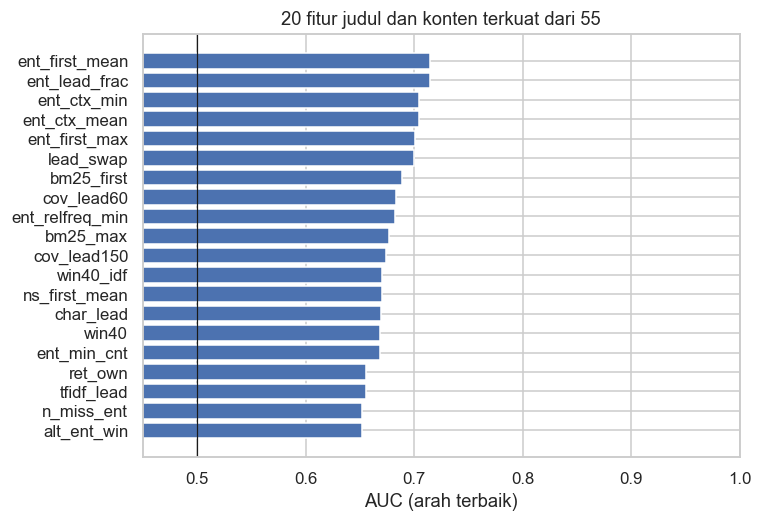

In [16]:
def ent_feats(title, ch, content):
    ci = cinfo(ch, content); cl, n, pos, cnt = ci['cl'], ci['n'], ci['pos'], ci['cnt']
    tl = title.lower().split(); ns = [w for w in tl if w not in STOP]; S = set(ns)
    occ = defaultdict(list)
    for i, w in enumerate(cl):
        if w in S: occ[w].append(i)
    best, bi = -1, 0
    for i in range(0, max(1, n - 39), 3):
        h = len(S & set(cl[i:i + 40]))
        if h > best: best, bi = h, i
    lo, hi = bi, bi + 40
    ents = [w for w in ns if is_ent(w)]
    f = {}
    out, far = 0, 0.0
    for w in ents:
        if w in occ:
            d = min(0 if lo <= p < hi else min(abs(p - lo), abs(p - hi)) for p in occ[w])
            out += d > 0; far = max(far, d / n)
    f['ent_out_win'] = out; f['ent_far'] = far
    ctx = []
    for w in ents:
        if w in occ:
            ctx.append(max(len((S - {w}) & set(cl[max(0, p - 8):p + 9])) for p in occ[w][:20]) / max(len(S) - 1, 1))
        else:
            ctx.append(-0.2)
    f['ent_ctx_min'] = min(ctx) if ctx else 0.5
    f['ent_ctx_mean'] = float(np.mean(ctx)) if ctx else 0.5
    lead_ents = [w for w in set(cl[:60]) if is_ent(w) and w not in S and cnt[w] >= 2]
    t_not_lead = [w for w in ents if pos.get(w, 1e9) >= 60]
    f['lead_ent_unmentioned'] = len(lead_ents)
    f['lead_swap'] = float(bool(lead_ents) and bool(t_not_lead))
    ce = [cnt[w] for w in set(cl) if is_ent(w)]; cmax = max(ce) if ce else 1
    f['ent_relfreq_min'] = min((cnt.get(w, 0) / cmax for w in ents), default=1.0)
    rare = sorted(ns, key=lambda w: cnt.get(w, 0))[:2]
    f['rare_first'] = max((pos.get(w, n) / n for w in rare), default=0)
    return f

ENT = cache('fitur_entitas', lambda: pd.DataFrame([ent_feats(t, c, x) for t, c, x in zip(ALL.title, ALL.ch, ALL.content)]))
CONS = pd.concat([CONS, ENT], axis=1); CONS_COLS = CONS_COLS + list(ENT.columns)

SG = (ALL.n_ch.values[:NTR] == 1)
A_ = pd.DataFrame({'AUC semua': {c: roc_auc_score(Y0, CONS[c].values[:NTR]) for c in CONS_COLS},
                   'AUC konten sekali': {c: roc_auc_score(Y0[SG], CONS[c].values[:NTR][SG]) for c in CONS_COLS}})
A_['kekuatan'] = (A_['AUC semua'] - 0.5).abs()
A_ = A_.sort_values('kekuatan', ascending=False)
simpan_tabel(A_.head(20), 'auc_fitur_konsistensi')
fig, ax = plt.subplots(figsize=(7, 5))
top = A_.head(20)
ax.barh(top.index[::-1], (top['AUC semua'] - 0.5).abs()[::-1] + 0.5, color='#4C72B0')
ax.axvline(0.5, color='k', lw=0.8); ax.set_xlim(0.45, 1); ax.set_xlabel('AUC (arah terbaik)')
ax.set_title(f'20 fitur judul dan konten terkuat dari {len(CONS_COLS)}')
simpan_gambar('06_auc_fitur_konsistensi')

### 7.4 Word2vec dilatih dari nol

Detektor token perlu tahu kata mana yang sejenis, misalnya Jabar dan Jateng, atau Surabaya dan Sidoarjo. Word2vec skip-gram dilatih dari nol pada konten unik dan judul (train dan test, tanpa label). Satu worker dan fungsi hash tetap membuat hasilnya sama di setiap run.

In [17]:
def _stable_hash(s): return zlib.crc32(str(s).encode())
def latih_w2v():
    sents = [c.lower().split() for c in UC.content] + [t.lower().split() for t in ALL.title.drop_duplicates()]
    return Word2Vec(sents, vector_size=100, window=5, min_count=3, sg=1, negative=10, epochs=5,
                    workers=1, seed=SEED, hashfxn=_stable_hash)
W2V = cache('word2vec', latih_w2v)
KV = W2V.wv
VEC_ = KV.vectors / np.linalg.norm(KV.vectors, axis=1, keepdims=True); KIDX = KV.key_to_index
def vec(w):
    i = KIDX.get(w); return None if i is None else VEC_[i]
tetangga = pd.DataFrame({w: [x for x, _ in KV.most_similar(w, topn=6)] for w in ['jabar', 'surabaya', 'jepang', 'anies', 'menkes'] if w in KIDX}).T
tetangga.columns = [f'tetangga {k + 1}' for k in range(tetangga.shape[1])]
print('kosakata word2vec:', len(KIDX)); simpan_tabel(tetangga, 'word2vec_tetangga')

[cache] word2vec dimuat
kosakata word2vec: 29741


,tetangga 1,tetangga 2,tetangga 3,tetangga 4,tetangga 5,tetangga 6
jabar,banten,jatim,jateng,jawa,dki,barat
surabaya,sidoarjo,malang,whisnu,blitar,buana,febriadhitya
jepang,india,singapura,jerman,inggris,thailand,kanada
anies,baswedan,ariza,riza,patria,dki,pemprov
menkes,terawan,gunadi,sadikin,saksono,9860,putranto


### 7.5 Kamus domain dari data eksternal

Model tidak otomatis tahu hal yang semua orang tahu, misalnya Sumsel berbeda dengan Sulsel, Kebon Sirih adalah sebutan media untuk DPRD DKI, dan Suriah termasuk Timur Tengah. Kamus domain memuat pengetahuan ini dari data eksternal yang dideklarasikan di atas. Setiap grup adalah satu hal di dunia nyata dengan banyak cara penulisan, lengkap dengan kelas dan induknya. Wilayah disusun bertingkat dari kawasan, negara, provinsi, kabupaten/kota, sampai kecamatan.

Kamus tidak memakai label apa pun. Ia hanya dipakai untuk menjawab dua pertanyaan tentang setiap kata judul: apakah kata ini atau aliasnya ada di konten, dan apakah awal konten menyebut wilayah saudaranya (setingkat dengan induk yang sama).

In [18]:
KG = []
def _g(kelas, frasa, lvl=0, induk=()):
    KG.append(dict(kelas=kelas, frasa=sorted(set(f.lower() for f in frasa)), lvl=lvl, induk=list(induk)))
    return len(KG) - 1

kd = pd.read_csv(os.path.join(EXT_DIR, 'kamus_domain.csv'), dtype=str, keep_default_na=False)
for r in kd.itertuples():
    _g(r.kelas, r.frasa.split('|'), int(r.lvl), [int(x) for x in r.induk.split('|') if x])
NEGARA_ID = next(i for i, g in enumerate(KG) if g['kelas'] == 'negara' and 'indonesia' in g['frasa'])
al_ = pd.read_csv(os.path.join(EXT_DIR, 'alias_wilayah.csv'), dtype=str, keep_default_na=False)
PROV_AL = dict(zip(al_[al_.tingkat == 'provinsi'].nama, al_[al_.tingkat == 'provinsi'].alias))
KAB_AL = dict(zip(al_[al_.tingkat == 'kabkota'].nama, al_[al_.tingkat == 'kabkota'].alias))

PROV = {}
for ln in open(os.path.join(EXT_DIR, 'provinces.csv'), encoding='utf-8'):
    kode, nama = ln.strip().split(',', 1)
    PROV[kode] = _g('provinsi', [nama.lower()] + [a for a in PROV_AL.get(nama, '').split('|') if a], lvl=3, induk=[NEGARA_ID])
_kab = defaultdict(set); KAB_OF = {}
for ln in open(os.path.join(EXT_DIR, 'regencies.csv'), encoding='utf-8'):
    kode, kp, nama = ln.strip().split(',', 2)
    nm = re.sub(r'^(KABUPATEN|KOTA)\s+', '', nama).replace('ADM. ', '').replace('ADMINISTRASI ', '').lower().strip()
    _kab[nm].add(kp); KAB_OF[kode] = nm
KAB = {}
for nm, kps in sorted(_kab.items()):
    KAB[nm] = _g('kabkota', [nm] + [a for a in KAB_AL.get(nm, '').split('|') if a], lvl=4, induk=[PROV[k] for k in sorted(kps)])
_kec = defaultdict(set)
for ln in open(os.path.join(EXT_DIR, 'districts.csv'), encoding='utf-8'):
    kode, kk, nama = ln.strip().split(',', 2)
    nm = nama.lower().strip()
    if len(nm) >= 5 and nm not in _kab and kk in KAB_OF: _kec[nm].add(KAB[KAB_OF[kk]])
for nm, ks in sorted(_kec.items()):
    _g('kecamatan', [nm], lvl=5, induk=sorted(ks))

KG_LVL = np.array([g['lvl'] for g in KG]); KG_KELAS = [g['kelas'] for g in KG]
FRASA = defaultdict(list)
for gid, g in enumerate(KG):
    for f in g['frasa']:
        if f: FRASA[tuple(f.split())].append(gid)
FR_MAXN = max(len(k) for k in FRASA)
_ANC = {}
def leluhur(gid):
    x = _ANC.get(gid)
    if x is None:
        x = set(); st = list(KG[gid]['induk'])
        while st:
            a = st.pop()
            if a not in x: x.add(a); st.extend(KG[a]['induk'])
        _ANC[gid] = x
    return x
GEO_KELAS = {'kawasan', 'negara', 'kota_dunia', 'provinsi', 'kabkota', 'kecamatan'}
def _ok_tunggal(w, gids):
    if not any(KG_KELAS[g] in GEO_KELAS for g in gids): return True
    c = CAP.get(w)
    return c is None or c >= 0.6
def cocok_frasa(toks):
    out = []
    for i in range(len(toks)):
        for n in range(1, FR_MAXN + 1):
            k = tuple(toks[i:i + n])
            if len(k) < n: break
            gs = FRASA.get(k)
            if gs and (n > 1 or _ok_tunggal(k[0], gs)):
                out.extend((i, i + n, g) for g in gs)
    return out
simpan_tabel(pd.Series(Counter(KG_KELAS), name='grup').sort_values(ascending=False).to_frame(), 'kamus_per_kelas')
print(f'kamus: {len(KG)} grup, {len(FRASA)} frasa')

kamus: 7367 grup, 7989 frasa


### 7.6 Detektor token gaya ELECTRA

Setiap kata judul (selain kata umum) diberi skor "apakah ini kata pengganti". Skor baris adalah skor kata tertinggi. Ini meniru ide ELECTRA [5] tanpa jaringan saraf.

**Label kata.** Dari pasangan minimal di train, kata yang diganti atau disisipkan pada judul palsu diberi label positif dan semua kata pada judul asli diberi label negatif. Judul palsu lain yang kata penggantinya tidak diketahui dipakai lewat relabel multiple instance [6]: kata dengan skor OOF tertinggi (minimal 0,3) dijadikan positif berbobot 0,5. Relabel dibatasi satu putaran supaya kebocoran orde dua dari skor OOF tetap kecil.

**Fitur per kata** (semuanya dari teks):

1. letak dan frekuensi di konten, keentitasan, IDF, posisi di judul,
2. kemiripan word2vec dengan kata awal konten yang tidak disebut judul (kandidat kata asli), dan apakah kandidat itu cocok dengan slot kata judul ("Bupati [Malang]" di judul, "Bupati Lumajang" di konten),
3. singkatan dari rangkaian kata konten (Jabar dari Jawa Barat, Kadis dari Kepala Dinas), kemiripan ejaan untuk salah ketik asli, kata ulang tanpa tanda hubung,
4. ko-okurensi dengan entitas awal konten di artikel lain, dan asosiasi kata judul dengan kata awal konten yang dipelajari dari judul asli train fold lain (metonimi seperti "Kebon Sirih" dengan DPRD DKI),
5. fitur kamus domain dari 7.5.

Validasi detektor memakai 5 fold berkelompok per konten. Kata di test dinilai model yang dilatih di seluruh train.

In [19]:
LEAD_N = 60
_LEAD = {}
def lead_info(ch, content):
    x = _LEAD.get(ch)
    if x is None:
        cl = cinfo(ch, content)['cl']
        lw = [w for w in dict.fromkeys(cl[:LEAD_N]) if w not in STOP and not w.isdigit() and vec(w) is not None]
        M = np.array([vec(w) for w in lw]) if lw else np.zeros((0, VEC_.shape[1]))
        allw = [w for w in dict.fromkeys(cl) if w not in STOP and not w.isdigit() and vec(w) is not None]
        MA = np.array([vec(w) for w in allw]) if allw else np.zeros((0, VEC_.shape[1]))
        x = (lw, M, allw, {w: k for k, w in enumerate(allw)}, MA); _LEAD[ch] = x
    return x

def is_abbrev(t, words):
    def rec(ti, wi, used):
        if ti == len(t): return used >= 2
        if wi >= len(words) or used >= 5: return False
        w = words[wi]
        for k in range(min(len(w), len(t) - ti), 0, -1):
            if w[:k] == t[ti:ti + k] and rec(ti + k, wi + 1, used + 1): return True
        return False
    return rec(0, 0, 0)
def is_abbrev2(t, words):
    def rec(ti, wi, used):
        if ti == len(t): return used >= 2
        if wi >= len(words) or used >= 5: return False
        w = words[wi]
        for k in range(min(len(w), len(t) - ti), 0, -1):
            if w[:k] == t[ti:ti + k] and rec(ti + k, wi + 1, used + 1): return True
            if k + 1 <= len(t) - ti and w[:k] + w[-1] == t[ti:ti + k + 1] and rec(ti + k + 1, wi + 1, used + 1): return True
        return False
    return rec(0, 0, 0)
def abbrev_pos(t, cl):
    if 2 <= len(t) <= 12 and not t.isdigit():
        for p in range(len(cl)):
            if cl[p][:1] == t[:1] and is_abbrev(t, cl[p:p + 5]): return p / max(len(cl), 1)
    return -1.0
DOCSETS = [set(c.lower().split()) for c in UC.content]
INV = defaultdict(set)
for d_, s_ in enumerate(DOCSETS):
    for w in s_: INV[w].add(d_)
_UW = {}
def uniq_words(ch, cl):
    x = _UW.get(ch)
    if x is None: x = sorted(set(w for w in cl if not w.isdigit() and len(w) >= 3)); _UW[ch] = x
    return x

def token_feats(title, ch, content, own_id):
    ci = cinfo(ch, content); cl, pos, cnt, n = ci['cl'], ci['pos'], ci['cnt'], ci['n']
    tl = title.lower().split(); S = set(tl); L = len(tl)
    lw, M, allw, aidx, MA = lead_info(ch, content)
    uw = uniq_words(ch, cl)
    lead_e = [w for w in dict.fromkeys(cl[:60]) if is_ent(w) and w not in S][:8]
    rows = []
    for j, w in enumerate(tl):
        if w in STOP or w in ('kumparan', 'com'): continue
        f = dict(j=j, tpos=j / max(L - 1, 1), L=L, is_num=float(w.isdigit()), in_c=float(w in pos),
                 first=pos[w] / n if w in pos else 1.5, cnt=cnt.get(w, 0), is_ent=float(is_ent(w)),
                 cap=CAP.get(w, -1), idf=IDF.get(w, IDF_UNK), lfreq=math.log1p(tot.get(w, 0)),
                 wlen=len(w), first_tok=float(j == 0))
        v = vec(w)
        cand = [k for k, x in enumerate(lw) if x not in S]
        if v is not None and cand:
            sims = M[cand] @ v; b = int(np.argmax(sims)); e = lw[cand[b]]
            ss = np.sort(sims)[::-1]
            f.update(sim_lead=float(sims[b]), sim_lead_first=pos[e] / n, sim_lead_cnt=cnt[e],
                     sim_lead_ent=float(is_ent(e)), sim_lead_gap=float(ss[0] - (ss[1] if len(ss) > 1 else 0)))
        else:
            f.update(sim_lead=np.nan, sim_lead_first=np.nan, sim_lead_cnt=np.nan, sim_lead_ent=np.nan, sim_lead_gap=np.nan)
        if v is not None and len(allw):
            sims = MA @ v
            if w in aidx: sims[aidx[w]] = -1
            f['sim_any'] = float(sims.max())
        else:
            f['sim_any'] = np.nan
        f['vknown'] = float(v is not None)
        Lw = tl[j - 1] if j > 0 else None; Rw = tl[j + 1] if j + 1 < L else None
        fl = sorted(x for x in ci['nxt'].get(Lw, ()) if x != w) if Lw else []
        fr = sorted(x for x in ci['prv'].get(Rw, ()) if x != w) if Rw else []
        f['big_l'] = float(Lw is not None and (Lw, w) in ci['big'])
        f['big_r'] = float(Rw is not None and (w, Rw) in ci['big'])
        def best_sim(xs):
            if v is None: return np.nan
            vs = [vec(x) for x in xs if vec(x) is not None]
            return float(max(x @ v for x in vs)) if vs else np.nan
        f['slot_l_sim'] = best_sim(fl[:50]); f['slot_r_sim'] = best_sim(fr[:50])
        f['slot_both'] = float(bool(Lw and Rw and any((x, Rw) in ci['big'] for x in fl)))
        if w in pos:
            occ = [i for i, x in enumerate(cl) if x == w][:15]
            f['ctx'] = max(len((S - {w}) & set(cl[max(0, p - 8):p + 9])) for p in occ) / max(len(S) - 1, 1)
        else:
            f['ctx'] = -0.2
        f['abbr'] = abbrev_pos(w, cl) if w not in pos else -2.0
        if w not in pos and not w.isdigit() and uw:
            m = rfp.extractOne(w, uw, scorer=LEV.normalized_similarity)
            f['ed_sim'] = m[1] if m else 0.0
            f['ed_prefix'] = float(any(x.startswith(w) or w.startswith(x) for x in uw if len(x) >= 4 and len(w) >= 4))
        else:
            f['ed_sim'] = -1.0; f['ed_prefix'] = -1.0
        A_ = INV.get(w, set()); cs = []
        for e in lead_e:
            B_ = INV.get(e)
            if B_ and len(B_) > 1:
                cs.append((len(A_ & B_) - (1 if (own_id in A_ and own_id in B_) else 0)) / (len(B_) - 1))
        f['cooc_max'] = max(cs) if cs else -1.0
        f['cooc_mean'] = float(np.mean(cs)) if cs else -1.0
        f['df_t'] = math.log1p(len(A_))
        rows.append((j, w, f))
    return rows

def token_feats3(title, ch, content):
    ci = cinfo(ch, content); cl = ci['cl']
    tl = title.lower().split(); S = set(tl); L = len(tl)
    lw = lead_info(ch, content)[0]
    occ_all = defaultdict(list)
    for p, x in enumerate(cl):
        if len(occ_all[x]) < 15: occ_all[x].append(p)
    def ctx_of(w):
        oc = occ_all.get(w)
        if not oc: return -0.2
        return max(len((S - {w}) & set(cl[max(0, p - 8):p + 9])) for p in oc) / max(len(S) - 1, 1)
    out = []
    for j, w in enumerate(tl):
        if w in STOP or w in ('kumparan', 'com'): continue
        Lw = tl[j - 1] if j > 0 else None; Rw = tl[j + 1] if j + 1 < L else None
        v = vec(w); cand = [x for x in lw if x not in S]; e_list = []
        if v is not None and cand:
            sims = np.array([vec(x) @ v for x in cand]); order = np.argsort(-sims, kind='stable')[:3]
            e_list = [(cand[k], sims[k]) for k in order]
        best_slot = 0.0; best_ctx = -0.2; best_sim_slot = 0.0
        for e, s_ in e_list:
            sl = float(Lw is not None and (Lw, e) in ci['big']) + float(Rw is not None and (e, Rw) in ci['big'])
            if sl > best_slot or (sl == best_slot and s_ > best_sim_slot): best_slot, best_sim_slot = sl, s_
            best_ctx = max(best_ctx, ctx_of(e))
        f = dict(e_slot=best_slot, e_slot_sim=best_sim_slot if best_slot > 0 else 0.0,
                 e_ctx=best_ctx, ctx_diff=best_ctx - ctx_of(w))
        if w.isdigit():
            f['num_slot'] = (float(bool(Rw) and any(x.isdigit() and x != w for x in ci['prv'].get(Rw, ())))
                             + float(bool(Lw) and any(x.isdigit() and x != w for x in ci['nxt'].get(Lw, ()))))
        else:
            f['num_slot'] = -1.0
        out.append(f)
    return out

KAMUS_TOK_COLS = ['k_known', 'k_geo', 'k_in_c', 'g_child_c', 'g_parent_c', 'g_same_lead', 'g_sib_lead', 'g_sib_first']
_KC = {}
def kamus_konten(ch, content):
    x = _KC.get(ch)
    if x is None:
        cl = cinfo(ch, content)['cl']; n = max(len(cl), 1)
        first = {}; lead = set()
        for a, b, g in cocok_frasa(cl):
            if g not in first: first[g] = a / n
            if a < 80: lead.add(g)
        anc = set()
        for g in first:
            if KG_KELAS[g] in GEO_KELAS: anc |= leluhur(g)
        x = (first, lead, anc); _KC[ch] = x
    return x
def kamus_feats(i):
    tl = ALL.title.values[i].lower().split(); first, lead, anc = kamus_konten(CH[i], ALL.content.values[i])
    cov = defaultdict(set); tgs = set()
    for a, b, g in cocok_frasa(tl):
        tgs.add(g)
        for j in range(a, b): cov[j].add(g)
    tanc = set()
    for g in tgs: tanc |= leluhur(g)
    out = []
    for j, w in enumerate(tl):
        if w in STOP or w in ('kumparan', 'com'): continue
        G = cov.get(j, set())
        if not G:
            out.append([0, 0, -2, -1, -1, -1, -1, -1]); continue
        pres = [1 - first[g] for g in G if g in first]
        geo = [g for g in G if KG_KELAS[g] in GEO_KELAS]
        f = [1, max((KG_LVL[g] for g in geo), default=0), max(pres) if pres else -1.0]
        if geo:
            child = float(any(g in anc for g in geo))
            parent = float(any(leluhur(g) & set(first) for g in geo))
            same, sib = set(), set()
            for h in lead:
                if h in tgs or KG_KELAS[h] not in GEO_KELAS or h in tanc: continue
                ah = leluhur(h)
                for g in geo:
                    if KG_LVL[h] == KG_LVL[g] and g not in ah:
                        same.add(h)
                        if set(KG[h]['induk']) & set(KG[g]['induk']): sib.add(h)
            sf = [first[h] for h in same]
            f += [child, parent, len(same), len(sib), min(sf) if sf else -1.0]
        else:
            f += [-1, -1, -1, -1, -1]
        out.append(f)
    return out

EXTRA_COLS = ['redup', 'abbr2', 'assoc', 'assoc_n']
ch_ids = np.array(sorted(set(own[:NTR].tolist())))
perm = np.random.RandomState(SEED).permutation(len(ch_ids))
FOLD_OF_CH = {c: k % 5 for k, c in zip(range(len(ch_ids)), ch_ids[perm])}
def token_extra():
    TL_ = [ALL.title.values[i].lower().split() for i in range(len(ALL))]
    TW_ = [[x for x in tl if x not in STOP and x not in ('kumparan', 'com')] for tl in TL_]
    redup, abb2 = [], []
    for i in range(len(ALL)):
        tl = TL_[i]; ci = cinfo(CH[i], ALL.content.values[i]); cl, pos = ci['cl'], ci['pos']
        for j, w in enumerate(tl):
            if w in STOP or w in ('kumparan', 'com'): continue
            f = 0.0
            for x in ([tl[j - 1]] if j > 0 else []) + ([tl[j + 1]] if j + 1 < len(tl) else []):
                a, b = akar(w), akar(x)
                if len(a) >= 3 and len(b) >= 3 and (a == b or a in x or b in w): f = 1.0
            redup.append(f)
            v = -2.0
            if w not in pos and 2 <= len(w) <= 12 and not w.isdigit():
                v = -1.0
                for p in range(len(cl)):
                    if cl[p][:1] == w[:1] and is_abbrev2(w, cl[p:p + 5]): v = p / max(len(cl), 1); break
            abb2.append(v)
    lead = [sorted(set(w for w in cinfo(CH[i], ALL.content.values[i])['cl'][:80] if w not in STOP and not w.isdigit()))
            for i in range(len(ALL))]
    fold_row = np.array([FOLD_OF_CH.get(own[i], -1) for i in range(len(ALL))])
    pc = [Counter() for _ in range(5)]; cc = [Counter() for _ in range(5)]; seen = set()
    for i in range(NTR):
        if Y[i] != 1 or (TH[i], CH[i]) in seen: continue
        seen.add((TH[i], CH[i])); k = fold_row[i]; ts = set(TW_[i])
        cc[k].update(lead[i]); pc[k].update((c, t) for c in lead[i] for t in ts)
    PC = sum(pc, Counter()); CC = sum(cc, Counter())
    assoc, assoc_n = [], []
    for i in range(len(ALL)):
        k = fold_row[i] if i < NTR else -1
        for w in TW_[i]:
            best, bn = 0.0, 0
            for c in lead[i]:
                if c == w: continue
                n_c = CC[c] - (cc[k][c] if k >= 0 else 0)
                if n_c < 5: continue
                n_ct = PC.get((c, w), 0) - (pc[k].get((c, w), 0) if k >= 0 else 0)
                if n_ct / n_c > best: best, bn = n_ct / n_c, n_ct
            assoc.append(best); assoc_n.append(bn)
    return np.column_stack([redup, abb2, assoc, assoc_n])

IDX_PAIR = {(TH[i], CH[i]): i for i in range(NTR)}
INS = {}
for a_, b_, c_ in PAIRS:
    A_, B_ = a_.lower().split(), b_.lower().split()
    sm = difflib.SequenceMatcher(None, A_, B_)
    if sm.ratio() < 0.5: continue
    k = IDX_PAIR.get((nh(b_), nh(c_)))
    if k is None: continue
    ins = set()
    for o in sm.get_opcodes():
        if o[0] in ('replace', 'insert'): ins.update(range(o[3], o[4]))
    if ins: INS[k] = ins

def hitung_fitur_token():
    tok = []
    for i in range(len(ALL)):
        for j, w, f in token_feats(ALL.title.values[i], CH[i], ALL.content.values[i], own[i]):
            lab = 0 if (i < NTR and Y[i] == 1) else (int(j in INS[i]) if i in INS else -1)
            tok.append((i, j, w, lab, f))
    tf = pd.DataFrame([t[4] for t in tok]); tf['row'] = [t[0] for t in tok]; tf['pos_judul'] = [t[1] for t in tok]
    tf['kata'] = [t[2] for t in tok]; tf['lab'] = [t[3] for t in tok]
    t3 = pd.DataFrame([f for i in range(len(ALL)) for f in token_feats3(ALL.title.values[i], CH[i], ALL.content.values[i])])
    for c in t3.columns: tf[c] = t3[c].values
    kam = np.array([f for i in range(len(ALL)) for f in kamus_feats(i)], dtype=float)
    ext = token_extra()
    assert len(kam) == len(tf) == len(ext)
    return tf, kam, ext
TOKF, KAM_TOK, EXT_TOK = cache('fitur_token', hitung_fitur_token)
TCOLS = [c for c in TOKF.columns if c not in ('row', 'lab', 'pos_judul', 'kata')]
print(f'token {len(TOKF)} | positif {(TOKF.lab == 1).sum()} | negatif {(TOKF.lab == 0).sum()} | tak berlabel {(TOKF.lab == -1).sum()}')
_tl = TOKF.lab.values; _m = (TOKF.row.values < NTR) & (_tl >= 0)
kam_diag = []
for nm, m in [('semua token berlabel', np.ones(len(TOKF), bool)),
              ('dikenal kamus dan aliasnya ada di konten', KAM_TOK[:, 2] >= 0),
              ('tak ada di konten, awal konten menyebut wilayah saudara', (KAM_TOK[:, 6] > 0) & (KAM_TOK[:, 2] < 0))]:
    mm = _m & m; kam_diag.append((nm, int(mm.sum()), _tl[mm].mean()))
simpan_tabel(pd.DataFrame(kam_diag, columns=['kondisi', 'token', 'porsi kata pengganti']).set_index('kondisi'), 'diagnostik_kamus')

[cache] fitur_token dimuat
token 158726 | positif 704 | negatif 118458 | tak berlabel 39564


,token,porsi kata pengganti
kondisi,,
semua token berlabel,119162,0.005908
dikenal kamus dan aliasnya ada di konten,34691,0.006572
"tak ada di konten, awal konten menyebut wilayah saudara",147,0.891156


[cache] detektor_token dimuat


relabel multiple instance: 272 kata dijadikan positif


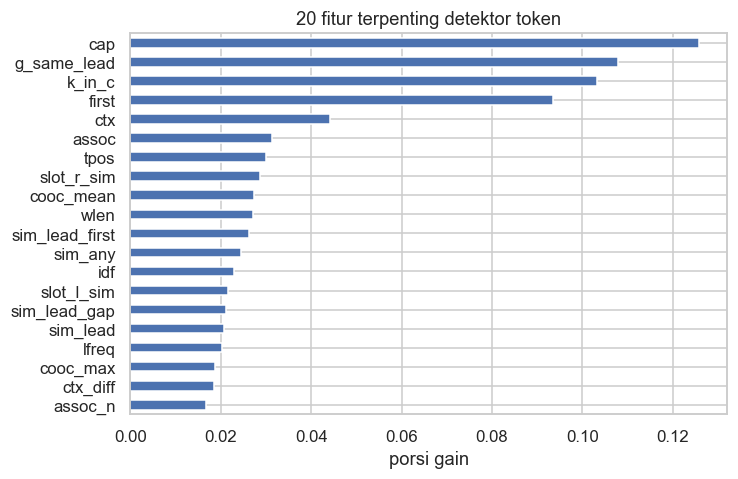

In [20]:
LGB_TOK = dict(objective='binary', learning_rate=0.03, num_leaves=31, min_child_samples=20,
               feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
               n_estimators=600, verbose=-1, n_jobs=N_THREADS, random_state=SEED,
               deterministic=True, force_row_wise=True, scale_pos_weight=5)
LGB_TOK2 = dict(LGB_TOK, learning_rate=0.02, n_estimators=1500, num_leaves=63, min_child_samples=15)
MIL_THR, MIL_W = 0.3, 0.5
rowsT = TOKF.row.values; lt = TOKF.lab.values; is_tr = rowsT < NTR
fk = np.array([FOLD_OF_CH.get(g, -1) for g in own[rowsT]])
lab_m = is_tr & (lt >= 0)

def tok_oof(X, params, labels, weights):
    oof = np.full(len(TOKF), np.nan)
    for k in range(5):
        tm = is_tr & (fk != k) & (labels >= 0); vm = is_tr & (fk == k)
        oof[vm] = lgb.LGBMClassifier(**params).fit(X[tm], labels[tm], sample_weight=weights[tm]).predict_proba(X[vm])[:, 1]
    return oof
def row_max(s):
    return TOKF[['row']].assign(s=s).groupby('row').s.max().reindex(range(len(ALL))).fillna(0).values
def tail(score):
    s = score[:NTR][SG]; y = Y0[SG]; o = np.argsort(-s)
    return dict(AUC_single=round(roc_auc_score(y, s), 4), AP_single=round(APS(y, s), 4),
                **{f'P@{k}': round(y[o[:k]].mean(), 3) for k in (50, 100, 200)})
def token_ronde2(X, cols, LT2, W2):
    oof2 = tok_oof(X, LGB_TOK2, LT2, W2)
    m = is_tr & (LT2 >= 0)
    mt = lgb.LGBMClassifier(**LGB_TOK2).fit(X[m], LT2[m], sample_weight=W2[m])
    s = oof2.copy(); s[~is_tr] = mt.predict_proba(X[~is_tr])[:, 1]
    imp = pd.Series(mt.booster_.feature_importance('gain'), index=cols)
    return s, imp / imp.sum()
def ringkas_token(s):
    g_ = TOKF[['row']].assign(s=s).groupby('row').s
    return pd.DataFrame({'tok_max': g_.max(), 'tok_mean': g_.mean(),
                         'tok_2nd': g_.apply(lambda v: np.sort(v.values)[-2] if len(v) > 1 else 0.0)}
                        ).reindex(range(len(ALL))).fillna(0).reset_index(drop=True)

def latih_detektor_token():
    X1 = TOKF[TCOLS].values
    oof0 = tok_oof(X1, LGB_TOK, lt, np.ones(len(TOKF)))
    unl = np.where(is_tr & (lt == -1))[0]
    top_ = pd.Series(oof0[unl], index=unl).groupby(rowsT[unl]).idxmax().values
    sel = np.array(sorted(k for k in top_ if oof0[k] >= MIL_THR))
    LT2 = lt.copy(); LT2[sel] = 1; W2 = np.ones(len(TOKF)); W2[sel] = MIL_W
    X2 = np.column_stack([X1, EXT_TOK, KAM_TOK]); cols2 = TCOLS + EXTRA_COLS + KAMUS_TOK_COLS
    s, imp = token_ronde2(X2, cols2, LT2, W2)
    return dict(oof0=oof0, sel=sel, LT2=LT2, W2=W2, TOK_S=s, imp=imp)
DT = cache('detektor_token', latih_detektor_token)
TOK_S, LT2, W2 = DT['TOK_S'], DT['LT2'], DT['W2']
TOKROW = ringkas_token(TOK_S)
diag_tok = pd.DataFrame([dict(tahap='putaran 1 (label pasangan saja)', AUC_token=roc_auc_score(lt[lab_m], DT['oof0'][lab_m]), **tail(row_max(DT['oof0']))),
                         dict(tahap='putaran 2 (+ relabel, + fitur tambahan dan kamus)', AUC_token=roc_auc_score(lt[lab_m], TOK_S[lab_m]), **tail(TOKROW.tok_max.values))]).set_index('tahap')
print(f'relabel multiple instance: {len(DT["sel"])} kata dijadikan positif')
simpan_tabel(diag_tok, 'diagnostik_detektor_token')
fig, ax = plt.subplots(figsize=(7, 4.5))
DT['imp'].sort_values().tail(20).plot.barh(ax=ax, color='#4C72B0'); ax.set_xlabel('porsi gain'); ax.set_title('20 fitur terpenting detektor token')
simpan_gambar('07_importance_detektor_token')

### 7.7 Detektor celah negasi

Untuk jenis pemalsuan "hapus negasi", judul palsu terlihat seperti kalimat biasa. Petunjuknya ada di konten: konten memuat "tidak" atau "tak" tepat sebelum kata yang sama (dicocokkan per akar kata), sementara judul tidak. Setiap kata judul yang punya celah seperti ini menjadi kandidat. Kandidat positif adalah tempat negasi dihapus pada pasangan minimal, dan kandidat negatif berasal dari judul asli. Skor baris adalah skor kandidat tertinggi.

In [21]:
_NI = {}
def neg_info(ch, content):
    x = _NI.get(ch)
    if x is None:
        cl = cinfo(ch, content)['cl']; n = max(len(cl), 1)
        occ = defaultdict(list); negocc = defaultdict(list)
        for p, w in enumerate(cl):
            a = akar(w); occ[a].append(p)
            if (p >= 1 and cl[p - 1] in NEGW) or (p >= 2 and cl[p - 2] in NEGW): negocc[a].append(p)
        x = (occ, negocc, set(zip(cl, cl[1:], cl[2:])), n); _NI[ch] = x
    return x
def gap_feats(title, ch, content):
    occ, negocc, tri, n = neg_info(ch, content); big = cinfo(ch, content)['big']
    tl = title.lower().split(); L = len(tl); tneg = sum(w in NEGW for w in tl)
    out = []
    for g in range(L):
        b = tl[g]
        if b in NEGW or b.isdigit() or (g > 0 and tl[g - 1] in NEGW): continue
        a_ = akar(b); no = negocc.get(a_, []); oc = occ.get(a_, [])
        if not no: continue
        out.append((g, dict(g=g, gpos=g / max(L - 1, 1), L=L, tneg=tneg, n_neg=len(no), n_occ=len(oc),
            neg_frac=len(no) / max(len(oc), 1), first_neg=no[0] / n, first_occ=oc[0] / n,
            neg_is_first=float(no[0] == oc[0]),
            strict=float(g > 0 and any((tl[g - 1], x, b) in tri for x in sorted(NEGW))),
            is_ent=float(is_ent(b)), is_stop=float(b in STOP), cap=CAP.get(b, -1), idf=IDF.get(b, IDF_UNK),
            exact_neg=float(any((x, b) in big for x in sorted(NEGW))))))
    return out
HAPUS = {}
for a_, b_, c_ in PAIRS:
    A_, B_ = a_.lower().split(), b_.lower().split()
    ops = [o for o in difflib.SequenceMatcher(None, A_, B_).get_opcodes() if o[0] != 'equal']
    if len(ops) == 1 and ops[0][0] == 'delete' and any(w in NEGW for w in A_[ops[0][1]:ops[0][2]]):
        k = IDX_PAIR.get((nh(b_), nh(c_)))
        if k is not None: HAPUS[k] = ops[0][3]
LGB_GAP = dict(objective='binary', learning_rate=0.03, num_leaves=15, min_child_samples=10,
               feature_fraction=0.9, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
               n_estimators=400, verbose=-1, n_jobs=N_THREADS, random_state=SEED,
               deterministic=True, force_row_wise=True)
def latih_detektor_celah():
    gap = [(i, g, 0 if (i < NTR and Y[i] == 1) else (int(g == HAPUS[i]) if i in HAPUS else -1), f)
           for i in range(len(ALL)) for g, f in gap_feats(ALL.title.values[i], CH[i], ALL.content.values[i])]
    gf = pd.DataFrame([x[3] for x in gap]); gr = np.array([x[0] for x in gap]); gl = np.array([x[2] for x in gap])
    Xg = gf.values; gtr = gr < NTR
    gfk = np.array([FOLD_OF_CH.get(g, -1) for g in own[gr]])
    s = np.full(len(gf), np.nan)
    for k in range(5):
        tm = gtr & (gfk != k) & (gl >= 0); vm = gtr & (gfk == k)
        s[vm] = lgb.LGBMClassifier(**LGB_GAP).fit(Xg[tm], gl[tm]).predict_proba(Xg[vm])[:, 1]
    s[~gtr] = lgb.LGBMClassifier(**LGB_GAP).fit(Xg[gtr & (gl >= 0)], gl[gtr & (gl >= 0)]).predict_proba(Xg[~gtr])[:, 1]
    return gr, gl, s
GAP_R, GAP_L, GAP_S = cache('detektor_celah', latih_detektor_celah)
GAPROW = pd.DataFrame({'gap_max': pd.Series(GAP_S).groupby(GAP_R).max()}).reindex(range(len(ALL))).fillna(0).reset_index(drop=True)
lm_ = (GAP_R < NTR) & (GAP_L >= 0)
print(f'pasangan hapus negasi {len(HAPUS)} | kandidat celah {len(GAP_S)} | positif {(GAP_L == 1).sum()}')
simpan_tabel(pd.DataFrame([dict(AUC_kandidat=roc_auc_score(GAP_L[lm_], GAP_S[lm_]), **tail(GAPROW.gap_max.values))], index=['detektor celah']), 'diagnostik_detektor_celah')

[cache] detektor_celah dimuat
pasangan hapus negasi 111 | kandidat celah 5164 | positif 78


,AUC_kandidat,AUC_single,AP_single,P@50,P@100,P@200
detektor celah,0.899874,0.5369,0.0658,0.24,0.18,0.135


### 7.8 Jejak mesin pemalsuan

Bagian 4.5 memperlihatkan judul palsu tidak pernah berspasi ganda. Mesin pemalsuan ternyata juga merapikan konten baris palsu, jadi konten berspasi ganda juga pasti milik baris asli. Jejak lain:

1. negasi berhuruf kecil di tengah judul yang semua katanya kapital ("... tak Bisa ...") adalah jejak negasi yang disisipkan,
2. judul yang sama persis muncul di konten lain dan salinan di sana berspasi ganda, berarti di sana ia judul asli dan di baris ini ia judul pinjaman.

Jejak ini dipakai dua kali: sebagai fitur model dan sebagai aturan keras. Spasi ganda atau karakter spasi khusus di judul atau konten langsung ditebak asli. Negasi berhuruf kecil atau judul pinjaman langsung ditebak palsu. Semua dihitung dari teks, tanpa label test.

In [22]:
LOWER_OK = set('''di ke dari dan yang untuk dengan pada atau oleh dalam hingga vs per jadi soal usai
jelang saat sejak bagi tentang agar karena demi via ala the of and in on at to for by a an is'''.split())
def surface(title):
    ws = title.split()
    neg_kecil = sum(1 for k, w in enumerate(ws) if k > 0 and w.lower() in NEGW and w[:1].islower())
    sesudah = sum(1 for k, w in enumerate(ws[:-1]) if w.lower() in NEGW and ws[k + 1][:1].islower()
                  and ws[k + 1].lower() not in LOWER_OK and ws[k + 1].lower() not in ('kumparan', 'com'))
    return dict(dbl_space=float('  ' in title),
                odd_char=float(any((ud.category(ch) == 'Zs' and ch != ' ') or ord(ch) > 127 or ch in '\t\r\n' for ch in title)),
                neg_kecil=float(neg_kecil), sesudah_neg_kecil=float(sesudah))
SURF = pd.DataFrame([surface(t) for t in ALL.title])
_byc = defaultdict(list)
for i, c in enumerate(CH): _byc[c].append(i)
_d = SURF.dbl_space.values
SURF['sib_dbl'] = [float(any(_d[j] > 0 and TH[j] != TH[i] for j in _byc[CH[i]])) for i in range(len(ALL))]
_C = ALL.content.values
SURF['c_dbl'] = [float('  ' in c) for c in _C]
SURF['c_odd'] = [float(any((ud.category(ch) == 'Zs' and ch != ' ') or ch in '\t\r\n' for ch in c)) for c in _C]
SURF['c_nonascii'] = [float(any(ord(ch) > 127 for ch in c)) for c in _C]
_cd, _cn = SURF.c_dbl.values, SURF.c_nonascii.values
SURF['sib_cdbl'] = [float(_cd[i] == 0 and any(_cd[j] > 0 for j in _byc[CH[i]] if j != i)) for i in range(len(ALL))]
SURF['sib_cna'] = [float(_cn[i] == 0 and any(_cn[j] > 0 for j in _byc[CH[i]] if j != i)) for i in range(len(ALL))]
FORCE1 = ((SURF.dbl_space + SURF.odd_char + SURF.c_dbl + SURF.c_odd) > 0).values
_byt = defaultdict(list)
for i, t in enumerate(TH): _byt[t].append(i)
_td = SURF.dbl_space.values > 0
SURF['twin_dbl'] = [float(not _td[i] and any(_td[j] and CH[j] != CH[i] for j in _byt[TH[i]] if j != i)) for i in range(len(ALL))]
SURF['twin_cert'] = [float(not FORCE1[i] and any(FORCE1[j] and CH[j] != CH[i] for j in _byt[TH[i]] if j != i)) for i in range(len(ALL))]
FORCE0 = ((SURF.neg_kecil > 0) | (SURF.twin_dbl > 0)).values & ~FORCE1
F1_TR, F0_TR = FORCE1[:NTR], FORCE0[:NTR]
F1_TE, F0_TE = FORCE1[NTR:], FORCE0[NTR:]
jejak = []
for nm, m in [('judul spasi ganda', SURF.dbl_space.values > 0), ('judul karakter khusus', SURF.odd_char.values > 0),
              ('negasi huruf kecil', SURF.neg_kecil.values > 0), ('saudara berspasi ganda', SURF.sib_dbl.values > 0),
              ('konten spasi ganda', SURF.c_dbl.values > 0), ('konten spasi khusus', SURF.c_odd.values > 0),
              ('konten non-ASCII', SURF.c_nonascii.values > 0), ('judul pinjaman (kembar berspasi ganda)', SURF.twin_dbl.values > 0),
              ('ATURAN tebak asli', FORCE1), ('ATURAN tebak palsu', FORCE0)]:
    jejak.append((nm, int(m[:NTR].sum()), Y0[m[:NTR]].mean() if m[:NTR].any() else np.nan, int(m[NTR:].sum())))
simpan_tabel(pd.DataFrame(jejak, columns=['jejak', 'baris train', 'porsi palsu train', 'baris test']).set_index('jejak'), 'jejak_mesin')

,baris train,porsi palsu train,baris test
jejak,,,
judul spasi ganda,5300,0.000000,1296
judul karakter khusus,21,0.000000,5
negasi huruf kecil,23,0.956522,6
saudara berspasi ganda,504,0.974206,143
konten spasi ganda,6541,0.000000,1602
konten spasi khusus,2108,0.000000,528
konten non-ASCII,2552,0.015282,677
judul pinjaman (kembar berspasi ganda),140,1.000000,38
ATURAN tebak asli,6546,0.000000,1604


**Aturan pasangan.** Konten baru di test yang punya tepat dua judul berbeda (regime `A_multi`) di train hampir selalu berisi tepat satu judul asli. Maka judul dengan skor asli lebih tinggi ditebak asli dan yang lain palsu. Aturan ini hanya berlaku bila selisih skor kedua judul minimal sebesar margin yang dipilih dari OOF. Aturan keras lain tetap didahulukan.

In [23]:
_BYC_P = defaultdict(list)
for i, c in enumerate(CH): _BYC_P[c].append(i)
def pair_rule(pred_all, p_all, reg_all, force1, force0, exlab_all, margin=0.0):
    out = pred_all.copy()
    for c, rows in _BYC_P.items():
        rows = [i for i in rows if reg_all[i] == 'A_multi']
        if len(rows) < 2: continue
        titles = sorted(set(TH[i] for i in rows))
        if len(titles) != 2: continue
        sc = {t: np.mean([p_all[i] for i in rows if TH[i] == t]) for t in titles}
        if any(np.isnan(v) for v in sc.values()): continue
        if abs(sc[titles[0]] - sc[titles[1]]) < margin: continue
        hi = titles[0] if sc[titles[0]] >= sc[titles[1]] else titles[1]
        for i in rows:
            if force1[i] or force0[i] or not np.isnan(exlab_all[i]): continue
            out[i] = 1 if TH[i] == hi else 0
    return out

### 7.9 Fitur struktural dan saudara

Fitur struktural menghitung berapa kali konten, judul, dan pasangannya muncul di seluruh data. Fitur saudara membandingkan judul ini dengan judul lain untuk konten yang sama (dari train maupun test). Pada pasangan minimal, kata pembeda judul asli muncul lebih awal dan lebih sering di konten. Saudara yang pasangannya kembar hampir pasti asli, jadi itu bukti bahwa judul ini yang palsu.

Fitur ini memakai teks test (bukan labelnya). Ini praktik transduktif yang umum dan sah karena tidak ada label test yang terlibat.

In [24]:
STRUCT_COLS = ['n_pair', 'n_ch', 'nt_ch', 'n_th', 'nc_th']
TOKS = [set(t.split()) for t in TH]
by_ch = defaultdict(list)
for i, c in enumerate(CH): by_ch[c].append(i)
ROW_CI = [cinfo(c, x) for c, x in zip(ALL.ch, ALL.content)]

def pair_cmp(i, j):
    ci = ROW_CI[i]; A, B = TOKS[i], TOKS[j]
    ua, ub = A - B, B - A
    return dict(sa=salience(ua, ci), sb=salience(ub, ci), na=len(ua), nb=len(ub),
                ja=len(A & B) / max(len(A | B), 1),
                nega=len(ua & NEG), negb=len(ub & NEG),
                inc_a=sum(w in ci['pos'] for w in ua) / len(ua) if ua else 1.0,
                inc_b=sum(w in ci['pos'] for w in ub) / len(ub) if ub else 1.0)

def sib_feats(i):
    sib = {}
    for j in by_ch[CH[i]]:
        if TH[j] != TH[i] and TH[j] not in sib: sib[TH[j]] = j
    f = dict(sib_n=len(sib))
    if not sib: return f
    cmps = [(pair_cmp(i, j), j) for j in sib.values()]
    c, j = max(cmps, key=lambda x: x[0]['ja'])
    f.update(sib_jacc=c['ja'], sib_sal_diff=c['sa'] - c['sb'], sib_n_own=c['na'], sib_n_oth=c['nb'],
             sib_neg_own=c['nega'], sib_neg_oth=c['negb'], sib_inc_own=c['inc_a'], sib_inc_oth=c['inc_b'],
             sib_oth_kembar=float(ALL.n_pair.values[j] >= 2),
             sib_any_kembar=float(any(ALL.n_pair.values[jj] >= 2 for jj in sib.values())),
             sib_sal_diff_min=min(x[0]['sa'] - x[0]['sb'] for x in cmps))
    for k in ['win40', 'ent_first_mean', 'cov_ns', 'tfidf_lead', 'bm25_max']:
        f[f'sib_d_{k}'] = CONS[k].values[i] - max(CONS[k].values[jj] for jj in sib.values())
    return f

with Timer('fitur saudara'):
    SIB = pd.DataFrame([sib_feats(i) for i in range(len(ALL))])
SIB_COLS = list(SIB.columns)
mm_ = (SIB.sib_n.values[:NTR] == 1) & (ALL.nt_ch.values[:NTR] == 2)
print(len(SIB_COLS), 'fitur saudara | baris punya saudara:', int((SIB.sib_n > 0).sum()),
      '| AUC selisih saliensi pada baris bersaudara:', round(roc_auc_score(Y0[mm_], -SIB.sib_sal_diff.values[:NTR][mm_]), 4))

[fitur saudara] 0.4s
17 fitur saudara | baris punya saudara: 2944 | AUC selisih saliensi pada baris bersaudara: 0.8798


### 7.10 Memori konten, memori judul, dan memori judul mirip

"Memori" adalah baris train berlabel yang tersedia untuk sebuah baris kueri, tanpa baris itu sendiri (bagian 6).

1. **Memori konten.** Label train lain untuk konten yang sama. Contohnya pasangan persis yang sudah berlabel, atau konten yang sudah punya judul asli lain.
2. **Memori judul persis.** Judul yang sama persis dipakai di konten lain. Kalau di sana ia judul asli, baris ini meminjam judul orang lain. Kalau di sana ia judul palsu, justru baris ini pemiliknya.
3. **Memori judul mirip.** Perluasan untuk judul pinjaman yang tidak persis sama.
   - `tmf_pos` dan `tmf_neg`: kemiripan TF-IDF tertinggi (minimal 0,5) dengan judul asli atau judul palsu milik konten lain yang isinya berbeda (kemiripan konten di bawah 0,3).
   - `orphan`: judul palsu milik baris lain lebih cocok dengan konten ini daripada judul baris ini sendiri, dan juga lebih cocok daripada dengan konten asalnya. Ini jejak judul yang dipindah ke artikel lain.

Semua label diambil dari memori per fold, jadi aman dari kebocoran. Ada uji otomatis di bawah: fitur memori sebuah baris tidak boleh berubah saat labelnya sendiri dibalik.

In [25]:
def build_memory(rows):
    pair_lab = defaultdict(list); byc = defaultdict(list)
    for i in rows:
        pair_lab[(TH[i], CH[i])].append(i); byc[CH[i]].append(i)
    return pair_lab, byc

MEM_KEYS = ['mem_exact_n', 'mem_exact_lab', 'mem_seen', 'mem_pos_n', 'mem_neg_n', 'mem_pos_jacc',
            'mem_pos_sal_diff', 'mem_pos_n_own', 'mem_pos_n_oth', 'mem_pos_neg_own', 'mem_pos_neg_oth',
            'mem_neg_jacc', 'mem_pos_seqratio']
def mem_feats(q, memory, labels):
    pair_lab, byc = memory
    ex = [i for i in pair_lab.get((TH[q], CH[q]), ()) if i != q]
    oth = [i for i in byc.get(CH[q], ()) if i != q and TH[i] != TH[q]]
    pos = {TH[i]: i for i in oth if labels[i] == 1}; neg = {TH[i]: i for i in oth if labels[i] == 0}
    f = dict.fromkeys(MEM_KEYS, np.nan)
    f.update(mem_exact_n=len(ex), mem_seen=float(bool(ex or oth)), mem_pos_n=len(pos), mem_neg_n=len(neg))
    if ex: f['mem_exact_lab'] = float(np.mean([labels[i] for i in ex]))
    if pos:
        cs = [(pair_cmp(q, j), j) for j in pos.values()]; c, j = max(cs, key=lambda x: x[0]['ja'])
        f.update(mem_pos_jacc=c['ja'], mem_pos_sal_diff=c['sa'] - c['sb'], mem_pos_n_own=c['na'],
                 mem_pos_n_oth=c['nb'], mem_pos_neg_own=c['nega'], mem_pos_neg_oth=c['negb'],
                 mem_pos_seqratio=difflib.SequenceMatcher(None, TH[q].split(), TH[j].split()).ratio())
    if neg:
        f['mem_neg_jacc'] = max(len(TOKS[q] & TOKS[j]) / max(len(TOKS[q] | TOKS[j]), 1) for j in neg.values())
    return f
def mem_table(queries, mem_rows, labels):
    memory = build_memory(mem_rows)
    return pd.DataFrame([mem_feats(q, memory, labels) for q in queries], index=queries)
LAB_ALL = np.concatenate([Y, -np.ones(NTE, int)])

_nh2 = lambda s: re.sub(r'\s+', ' ', re.sub(r'[^\w\s]', ' ', unicodedata.normalize('NFKC', str(s)).lower())).replace(' kumparan com', '').strip()
def pasangan_judul_mirip():
    t_ = ALL.title.map(_nh2); c_ = ALL.content.map(lambda x: ' '.join(str(x).lower().split()[:200]))
    v_ = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2), dtype=np.float32).fit(pd.concat([c_, t_]))
    Cn = normalize(v_.transform(c_)); Tn = normalize(v_.transform(t_))
    cidf = pd.factorize(pd.Series(CH))[0]; trr = np.arange(NTR)
    own_fit = np.asarray(Tn.multiply(Cn).sum(1)).ravel()
    s1 = [[] for _ in range(len(ALL))]; s2 = [[] for _ in range(len(ALL))]
    TnT = Tn[trr].T.tocsr()
    for s in range(0, len(ALL), 1500):
        r = np.arange(s, min(s + 1500, len(ALL)))
        same = cidf[r][:, None] == cidf[trr][None, :]
        St = (Tn[r] @ TnT).toarray(); St[same] = 0
        ii, jj = np.nonzero(St >= 0.5)
        if len(ii):
            cs = np.asarray(Cn[r[ii]].multiply(Cn[trr[jj]]).sum(1)).ravel()
            for a, b, sv, cc_ in zip(ii, jj, St[ii, jj], cs):
                if cc_ < 0.3: s1[r[a]].append((int(b), float(sv)))
        Sx = (Cn[r] @ TnT).toarray(); Sx[same] = -1
        gain = Sx - own_fit[r][:, None]; fo = Sx - own_fit[trr][None, :]
        sc = np.minimum(gain, fo); sc[(gain <= 0) | (fo <= 0)] = -1
        ii, jj = np.nonzero(sc > 0)
        for a, b in zip(ii, jj): s2[r[a]].append((int(b), float(sc[a, b])))
    for L_ in (s1, s2):
        for k in range(len(L_)): L_[k] = sorted(L_[k], key=lambda x: -x[1])[:30]
    return s1, s2
S1P, S2P = cache('memori_judul_mirip', pasangan_judul_mirip)

BY_TH = defaultdict(list)
for i, t in enumerate(TH): BY_TH[t].append(i)
TM_KEYS = ['tm_pos', 'tm_neg', 'tmf_pos', 'tmf_neg', 'orphan']
def title_mem(rows, mem_rows, keys=TM_KEYS):
    mset = np.zeros(len(ALL), bool); mset[mem_rows] = True
    out = np.zeros((len(rows), 5)); out[:, 4] = -1
    for k, q in enumerate(rows):
        for j in BY_TH[TH[q]]:
            if j == q or CH[j] == CH[q] or not mset[j]: continue
            out[k, 0 if LAB_ALL[j] == 1 else 1] += 1
        for j, sv in S1P[q]:
            if mset[j] and j != q:
                if LAB_ALL[j] == 1: out[k, 2] = max(out[k, 2], sv)
                elif LAB_ALL[j] == 0: out[k, 3] = max(out[k, 3], sv)
        for j, sv in S2P[q]:
            if mset[j] and j != q and LAB_ALL[j] == 0: out[k, 4] = max(out[k, 4], sv)
    return pd.DataFrame(out, columns=TM_KEYS)

_tm = title_mem(np.arange(NTR), np.arange(NTR))
mem_diag = [('semua baris konten sekali', int(SG.sum()), Y0[SG].mean())]
for c, thr in [('tm_pos', 1), ('tm_neg', 1), ('tmf_pos', 0.8), ('tmf_pos', 0.7), ('tmf_neg', 0.8), ('orphan', 0.05)]:
    m_ = SG & (_tm[c].values >= thr)
    mem_diag.append((f'{c} >= {thr}', int(m_.sum()), Y0[m_].mean() if m_.any() else np.nan))
simpan_tabel(pd.DataFrame(mem_diag, columns=['kondisi (baris train konten sekali)', 'baris', 'porsi palsu']).set_index('kondisi (baris train konten sekali)'), 'diagnostik_memori_judul')

_q = np.random.RandomState(0).choice(NTR, 300, replace=False)
_a = mem_table(_q, np.arange(NTR), LAB_ALL).fillna(-9)
_l = LAB_ALL.copy(); _l[_q] = 1 - _l[_q]
_b = mem_table(_q, np.arange(NTR), _l).fillna(-9)
iso = [q for q in _q if not any(j in set(_q) for j in by_ch[CH[q]] if j != q)]
assert (_a.loc[iso].values == _b.loc[iso].values).all(), 'fitur memori memakai label baris itu sendiri'
print(f'uji kebocoran memori lulus pada {len(iso)} baris terisolasi')

def regime(mf, i):
    if mf['mem_exact_n'] > 0: return 'C_exact'
    if mf['mem_seen']: return 'B_haspos' if mf['mem_pos_n'] > 0 else 'B_nopos'
    if ALL.nt_ch.values[i] >= 2: return 'A_multi'
    if ALL.n_pair.values[i] >= 2: return 'A_dup'
    return 'A_single'

[cache] memori_judul_mirip dimuat


uji kebocoran memori lulus pada 296 baris terisolasi


### 7.11 Model konsistensi tahap 1

Model LightGBM kecil yang hanya melihat fitur 7.1 sampai 7.3, divalidasi berkelompok per konten supaya belajar konsistensi judul dan konten, bukan menghafal konten. Keluarannya (`p_cons`, OOF) menjadi satu fitur untuk model utama.

In [26]:
LGB_CONS = dict(objective='binary', learning_rate=0.03, num_leaves=31, min_child_samples=30,
                feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
                n_estimators=700, verbose=-1, n_jobs=N_THREADS, random_state=SEED,
                deterministic=True, force_row_wise=True)
def latih_tahap1():
    Xr = CONS.iloc[:NTR].values; oof = np.zeros(NTR)
    for a, b in StratifiedGroupKFold(5, shuffle=True, random_state=SEED).split(Xr, Y, CH[:NTR]):
        oof[b] = lgb.LGBMClassifier(**LGB_CONS).fit(Xr[a], Y[a]).predict_proba(Xr[b])[:, 1]
    p_te = lgb.LGBMClassifier(**LGB_CONS).fit(Xr, Y).predict_proba(CONS.iloc[NTR:].values)[:, 1]
    return oof, p_te
P_CONS_OOF, P_CONS_TE = cache('tahap1', latih_tahap1)
simpan_tabel(pd.DataFrame([dict(model='tahap 1 (p_cons)', **tail(-P_CONS_OOF)), dict(model='detektor token (tok_max)', **tail(TOKROW.tok_max.values)),
                           dict(model='detektor celah (gap_max)', **tail(GAPROW.gap_max.values))]).set_index('model'), 'diagnostik_sinyal_baris')
BASELINE['tahap 1 saja (fitur judul dan konten)'] = f1_terbaik(Y, P_CONS_OOF)

NEW_COLS = ['tok_max', 'tok_mean', 'tok_2nd', 'gap_max'] + list(SURF.columns)
BASE_COLS = CONS_COLS + STRUCT_COLS + SIB_COLS + NEW_COLS
BASE = pd.concat([CONS, ALL[STRUCT_COLS].reset_index(drop=True), SIB, TOKROW, GAPROW, SURF], axis=1)[BASE_COLS]
FEATS = BASE_COLS + MEM_KEYS + TM_KEYS + ['p_cons']
KELOMPOK = {**{c: 'konsistensi judul-konten' for c in CONS_COLS if c not in VEC_COLS and c not in ENT.columns},
            **{c: 'vektor dan retrieval' for c in VEC_COLS}, **{c: 'letak entitas' for c in ENT.columns},
            **{c: 'struktural' for c in STRUCT_COLS}, **{c: 'saudara' for c in SIB_COLS},
            **{c: 'detektor token' for c in ['tok_max', 'tok_mean', 'tok_2nd']}, 'gap_max': 'detektor celah',
            **{c: 'jejak mesin' for c in SURF.columns}, **{c: 'memori konten' for c in MEM_KEYS},
            **{c: 'memori judul persis' for c in ['tm_pos', 'tm_neg']}, **{c: 'memori judul mirip' for c in ['tmf_pos', 'tmf_neg', 'orphan']},
            'p_cons': 'tahap 1'}
ringkas_fitur = pd.Series(KELOMPOK).value_counts().rename('fitur').to_frame()
simpan_tabel(ringkas_fitur, 'jumlah_fitur_per_kelompok')
print('total fitur model utama:', len(FEATS))

[cache] tahap1 dimuat


total fitur model utama: 112


## 8. Pemilihan algoritma

Semua kandidat dinilai dengan fitur yang sama dan pembagian 5×2 yang sama. Matriks desain setiap fold dibangun sekali lalu disimpan, karena fitur memorinya dihitung ulang per fold.

Kandidat yang dibandingkan:

1. **Regresi logistik**, pembanding linier sederhana dengan imputasi median dan standardisasi,
2. **LightGBM** dengan seed bagging 3 model,
3. **CatBoost**,
4. **XGBoost**,
5. **Rata-rata LightGBM dan CatBoost**, konfigurasi dasar kami.

Baris yang sudah pasti asli menurut jejak spasi tidak ikut melatih model utama. Keputusannya sudah pasti, dan membuangnya membuat model fokus pada baris yang sulit.

In [27]:
def design(rows, mem_rows, p_cons):
    M = mem_table(rows, mem_rows, LAB_ALL)
    X = BASE.iloc[rows].reset_index(drop=True)
    X = pd.concat([X, M.reset_index(drop=True), title_mem(rows, mem_rows)], axis=1); X['p_cons'] = p_cons
    reg = np.array([regime(M.loc[q], q) for q in rows])
    return X[FEATS], M.mem_exact_lab.values, reg

def bangun_desain():
    cv = []
    for r in range(N_REPEATS):
        cv.append([])
        for a, b in SPLITS[r]:
            Xa, _, _ = design(a, a, P_CONS_OOF[a]); Xb, exb, rb = design(b, a, P_CONS_OOF[b])
            cv[r].append(dict(Xa=Xa, Xb=Xb, ex=exb, reg=rb))
    tune = []
    for a, b in SPLITS_TUNE:
        Xa, _, _ = design(a, a, P_CONS_OOF[a]); Xb, exb, rb = design(b, a, P_CONS_OOF[b])
        tune.append(dict(Xa=Xa, Xb=Xb, ex=exb, reg=rb))
    Xtr, _, _ = design(np.arange(NTR), np.arange(NTR), P_CONS_OOF)
    Xte, ext, rte = design(np.arange(NTR, NTR + NTE), np.arange(NTR), P_CONS_TE)
    return dict(cv=cv, tune=tune, akhir=dict(Xtr=Xtr, Xte=Xte, ex=ext, reg=rte))
DESAIN = cache('desain', bangun_desain)
EXLAB = np.full((N_REPEATS, NTR), np.nan); REG = np.empty((N_REPEATS, NTR), object)
for r in range(N_REPEATS):
    for (a, b), d in zip(SPLITS[r], DESAIN['cv'][r]): EXLAB[r, b] = d['ex']; REG[r, b] = d['reg']
EXT, REG_TE = DESAIN['akhir']['ex'], DESAIN['akhir']['reg']

REGIMES = ['C_exact', 'B_haspos', 'B_nopos', 'A_multi', 'A_dup', 'A_single']
reg_tab = pd.DataFrame({'porsi validasi (CV)': pd.Series(REG[0]).value_counts(normalize=True),
                        'porsi test': pd.Series(REG_TE).value_counts(normalize=True),
                        'porsi palsu (CV)': pd.Series(Y0).groupby(REG[0]).mean()}).reindex(REGIMES)
simpan_tabel(reg_tab, 'regime_cv_vs_test')

[cache] desain dimuat


,porsi validasi (CV),porsi test,porsi palsu (CV)
C_exact,0.198791,0.257286,0.001398
B_haspos,0.053483,0.059950,0.984416
B_nopos,0.045635,0.046350,0.057839
A_multi,0.042370,0.021649,0.481967
A_dup,0.103702,0.064946,0.000670
A_single,0.556019,0.549820,0.042723


Porsi `A_single`, `B_haspos`, dan `B_nopos` di validasi silang hampir sama dengan di test, begitu juga porsi palsu per regime. `C_exact` lebih banyak di test karena memori test adalah seluruh train, sedangkan memori validasi hanya 80% train. Jadi kelompok tersulit (`A_single`) terwakili dengan porsi yang tepat, dan regime yang lebih mudah sedikit kurang terwakili di validasi. Akibatnya skor OOF cenderung sedikit konservatif.

In [28]:
LGB_MAIN = dict(objective='binary', learning_rate=0.03, num_leaves=31, min_child_samples=20,
                feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
                n_estimators=900, verbose=-1, n_jobs=N_THREADS, deterministic=True, force_row_wise=True)
CAT_MAIN = dict(iterations=1200, depth=6, learning_rate=0.04, l2_leaf_reg=3,
                verbose=False, thread_count=N_THREADS, allow_writing_files=False)
XGB_MAIN = dict(n_estimators=900, learning_rate=0.03, max_depth=6, min_child_weight=1.0, subsample=0.8,
                colsample_bytree=0.7, reg_lambda=1.0, tree_method='hist', n_jobs=N_THREADS, eval_metric='logloss', verbosity=0)
LR_MAIN = dict(C=0.5)
N_BAG = 3

def fit_member(kind, params, X, y, seed=SEED, n_bag=N_BAG):
    if kind == 'lightgbm':
        return [lgb.LGBMClassifier(**dict(params, random_state=seed + k)).fit(X, y) for k in range(n_bag)]
    if kind == 'catboost':
        return [cb.CatBoostClassifier(**dict(params, random_seed=seed)).fit(X, y)]
    if kind == 'xgboost':
        return [xgb.XGBClassifier(**dict(params, random_state=seed)).fit(X, y)]
    if kind == 'logreg':
        return [make_pipeline(SimpleImputer(strategy='median', add_indicator=True), StandardScaler(),
                              LogisticRegression(max_iter=3000, **params)).fit(X, y)]
def pred_member(ms, X):
    return np.mean([m.predict_proba(X)[:, 1] for m in ms], 0)

def oof_member(kind, params, seed=SEED, kolom_buang=(), ganti=None, pakai_aturan=True, ulangan=None):
    P = np.full((N_REPEATS, NTR), np.nan)
    for r in (range(N_REPEATS) if ulangan is None else ulangan):
        for (a, b), d in zip(SPLITS[r], DESAIN['cv'][r]):
            Xa, Xb = d['Xa'], d['Xb']
            if ganti is not None:
                Xa = Xa.copy(); Xb = Xb.copy()
                for c, v in ganti.items(): Xa[c] = v[a]; Xb[c] = v[b]
            Xa, Xb = Xa.drop(columns=list(kolom_buang)), Xb.drop(columns=list(kolom_buang))
            ta = ~F1_TR[a] if pakai_aturan else np.ones(len(a), bool)
            P[r, b] = pred_member(fit_member(kind, params, Xa[ta], Y[a][ta], seed), Xb)
    return P

def decide(p, exlab, thr, f1=None, f0=None):
    pred = (p >= thr).astype(int)
    if f1 is not None: pred[f1] = 1
    if f0 is not None: pred[f0] = 0
    m = ~np.isnan(exlab); pred[m] = (exlab[m] >= 0.5).astype(int)
    return pred
def best_thr(p, exlab, y, half=10, f1=None, f0=None):
    grid = np.round(np.arange(0.05, 0.951, 0.005), 3)
    s = np.array([f1_score(y, decide(p, exlab, t, f1, f0), average='macro') for t in grid])
    sm = np.array([s[max(0, i - half):i + half + 1].mean() for i in range(len(s))])
    i = int(sm.argmax())
    return grid[i], s[i], grid, s

MARGINS = (0.0, 0.05, 0.1, 0.15, 0.2, 0.3)
TANPA_PASANGAN = 9.0
def oof_pred(p, r, thr, margin, aturan=True, pakai_cex=True):
    ex = EXLAB[r] if pakai_cex else np.full(NTR, np.nan)
    b0 = decide(p, ex, thr, F1_TR if aturan else None, F0_TR if aturan else None)
    z = np.zeros(len(ALL), bool)
    return pair_rule(np.concatenate([b0, np.ones(NTE, int)]), np.concatenate([p, np.full(NTE, np.nan)]),
                     np.concatenate([REG[r], np.full(NTE, 'x', object)]), FORCE1 if aturan else z, FORCE0 if aturan else z,
                     np.concatenate([ex, np.zeros(NTE)]), margin)[:NTR]
def test_pred(p, thr, margin):
    b0 = decide(p, EXT, thr, F1_TE, F0_TE)
    return pair_rule(np.concatenate([np.ones(NTR, int), b0]), np.concatenate([np.full(NTR, np.nan), p]),
                     np.concatenate([np.full(NTR, 'x', object), REG_TE]), FORCE1, FORCE0,
                     np.concatenate([np.zeros(NTR), EXT]), margin)[NTR:]
MASK_MODEL = np.isnan(EXLAB) & ~F1_TR[None, :] & ~F0_TR[None, :]
def nilai(P, margins=MARGINS, aturan=True, pakai_cex=True):
    R_ = N_REPEATS
    ex = EXLAB if pakai_cex else np.full_like(EXLAB, np.nan)
    thr, sc, grid, curve = best_thr(P.ravel(), ex.ravel(), np.tile(Y, R_),
                                    f1=np.tile(F1_TR, R_) if aturan else None, f0=np.tile(F0_TR, R_) if aturan else None)
    om = {}
    for mg in margins:
        s = [f1_score(Y, oof_pred(P[r], r, thr, mg, aturan, pakai_cex), average='macro') for r in range(R_)]
        om[mg] = (round(s[0], 4), round(s[1], 4), round(float(np.mean(s)), 4))
    mg = max(margins, key=lambda m: (om[m][2], -m))
    pm = np.clip(P[MASK_MODEL], 1e-6, 1 - 1e-6); ym = np.tile(Y, (R_, 1))[MASK_MODEL]
    return dict(ambang=float(thr), margin=mg, OOF=om[mg][2], OOF_ulangan0=om[mg][0], OOF_ulangan1=om[mg][1],
                OOF_tanpa_pasangan=round(float(sc), 4), AUC=round(float(np.mean([roc_auc_score(Y0, -P[r]) for r in range(R_)])), 4),
                AP_palsu=round(float(np.mean([APS(Y0, 1 - P[r]) for r in range(R_)])), 4), logloss=round(float(log_loss(ym, pm)), 4))

In [29]:
KANDIDAT = {'logreg': LR_MAIN, 'lightgbm': LGB_MAIN, 'catboost': CAT_MAIN, 'xgboost': XGB_MAIN}
OOF = {}
for kind, params in KANDIDAT.items():
    OOF[f'{kind} (awal)'] = cache(f'oof_{kind}_awal', lambda: oof_member(kind, params))
OOF['LightGBM + CatBoost (awal)'] = (OOF['lightgbm (awal)'] + OOF['catboost (awal)']) / 2
HASIL_ALGO = pd.DataFrame({k: nilai(P) for k, P in OOF.items()}).T
simpan_tabel(HASIL_ALGO, 'perbandingan_algoritma')

[cache] oof_logreg_awal dimuat
[cache] oof_lightgbm_awal dimuat
[cache] oof_catboost_awal dimuat
[cache] oof_xgboost_awal dimuat


,ambang,margin,OOF,OOF_ulangan0,OOF_ulangan1,OOF_tanpa_pasangan,AUC,AP_palsu,logloss
logreg (awal),0.540,0.05,0.9580,0.9588,0.9573,0.9573,0.9811,0.9384,0.1159
lightgbm (awal),0.395,0.05,0.9548,0.9555,0.9541,0.9535,0.9803,0.9386,0.1502
catboost (awal),0.395,0.05,0.9546,0.9558,0.9534,0.9528,0.9823,0.9378,0.1205
xgboost (awal),0.440,0.15,0.9543,0.9546,0.9540,0.9529,0.9821,0.9390,0.1328
LightGBM + CatBoost (awal),0.440,0.05,0.9550,0.9553,0.9548,0.9538,0.9827,0.9412,0.1240


Hasilnya cukup mengejutkan. Regresi logistik justru memberi macro-F1 dan log loss terbaik, sedangkan tiga model pohon bersaing ketat di bawahnya. Penjelasan yang paling masuk akal: interaksi rumit sudah ditangani di tingkat fitur. Detektor token, detektor celah, dan model tahap 1 masing-masing adalah model pohon yang merangkum sinyal bersyarat menjadi satu skor. Di atas skor-skor matang ini, penggabung linier dengan peluang yang lebih terkalibrasi sudah cukup, sementara model pohon di tahap ini lebih mudah overfit pada baris yang jumlahnya terbatas. Karena itu regresi logistik ikut menjadi kandidat anggota ensemble di bagian 10.

## 9. Optimasi hyperparameter dengan Optuna

Optuna [11] dengan sampler TPE [12] mencari hyperparameter LightGBM, CatBoost, XGBoost, dan kekuatan regularisasi `C` regresi logistik. Beberapa hal kami atur supaya hasilnya jujur dan bisa diulang:

1. **Ruang pencarian ditulis manual** di fungsi `ruang` di bawah. Optuna tidak memilih algoritma atau menyusun ensemble, jadi ini bukan AutoML.
2. **Fold tuning terpisah.** Tuning memakai pembagian 5 fold dengan seed lain (`SEED + 100`), bukan fold penilaian 5×2, supaya skor penilaian tidak ikut dioptimasi.
3. **Target optimasi log loss**, bukan macro-F1. Macro-F1 bergantung pada ambang dan kurvanya bergerigi, sedangkan log loss halus dan mengukur kualitas peluang secara langsung. Log loss dihitung hanya pada baris yang memang diputus model, bukan baris yang sudah diputus aturan.
4. **Setelan awal dimasukkan sebagai percobaan pertama**, supaya hasil tuning pasti dibandingkan dengan titik awal yang sama.
5. **Pruning median** menghentikan percobaan yang jelas lebih buruk setelah beberapa fold. Sampler dan pruner memakai seed sehingga urutan percobaan selalu sama.

[cache] optuna_lightgbm dimuat
[cache] optuna_xgboost dimuat
[cache] optuna_catboost dimuat
[cache] optuna_logreg dimuat


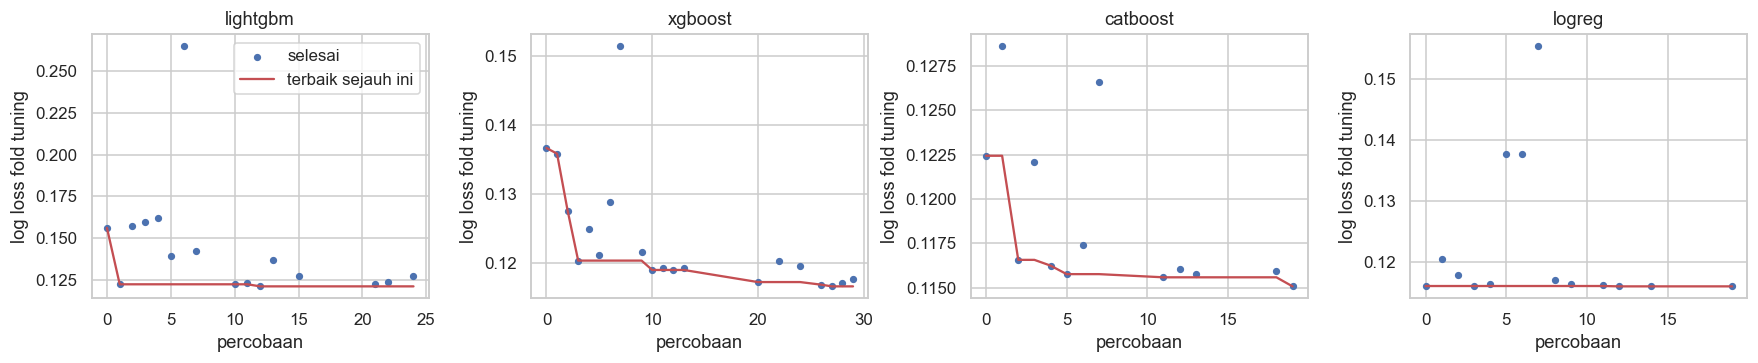

,lightgbm,xgboost,catboost,logreg
min_child_samples,0.690468,0.000000,0.000000,0.0
bagging_fraction,0.168676,0.000000,0.000000,0.0
num_leaves,0.054227,0.000000,0.000000,0.0
learning_rate,0.048038,0.726452,0.412980,0.0
feature_fraction,0.021900,0.000000,0.000000,0.0
n_estimators,0.015824,0.097735,0.000000,0.0
lambda_l2,0.000867,0.000000,0.000000,0.0
max_depth,0.000000,0.062741,0.000000,0.0
colsample_bytree,0.000000,0.047348,0.000000,0.0
min_child_weight,0.000000,0.038747,0.000000,0.0


In [30]:
def ruang(kind, t):
    if kind == 'logreg':
        return dict(LR_MAIN, C=t.suggest_float('C', 1e-3, 10, log=True))
    if kind == 'lightgbm':
        return dict(LGB_MAIN, learning_rate=t.suggest_float('learning_rate', 0.01, 0.1, log=True),
                    num_leaves=t.suggest_int('num_leaves', 15, 127), min_child_samples=t.suggest_int('min_child_samples', 5, 100),
                    feature_fraction=t.suggest_float('feature_fraction', 0.4, 1.0), bagging_fraction=t.suggest_float('bagging_fraction', 0.5, 1.0),
                    lambda_l2=t.suggest_float('lambda_l2', 1e-3, 10, log=True), n_estimators=t.suggest_int('n_estimators', 300, 1500, step=100))
    if kind == 'catboost':
        return dict(CAT_MAIN, depth=t.suggest_int('depth', 4, 8), learning_rate=t.suggest_float('learning_rate', 0.02, 0.15, log=True),
                    l2_leaf_reg=t.suggest_float('l2_leaf_reg', 1, 10, log=True), iterations=t.suggest_int('iterations', 300, 1200, step=100),
                    random_strength=t.suggest_float('random_strength', 0.1, 2.0))
    if kind == 'xgboost':
        return dict(XGB_MAIN, max_depth=t.suggest_int('max_depth', 3, 9), learning_rate=t.suggest_float('learning_rate', 0.01, 0.1, log=True),
                    subsample=t.suggest_float('subsample', 0.5, 1.0), colsample_bytree=t.suggest_float('colsample_bytree', 0.4, 1.0),
                    min_child_weight=t.suggest_float('min_child_weight', 1, 20, log=True), reg_lambda=t.suggest_float('reg_lambda', 1e-3, 10, log=True),
                    n_estimators=t.suggest_int('n_estimators', 300, 1500, step=100))
AWAL = {'logreg': dict(C=0.5),
        'lightgbm': dict(learning_rate=0.03, num_leaves=31, min_child_samples=20, feature_fraction=0.7, bagging_fraction=0.8, lambda_l2=1.0, n_estimators=900),
        'catboost': dict(depth=6, learning_rate=0.04, l2_leaf_reg=3.0, iterations=1200, random_strength=1.0),
        'xgboost': dict(max_depth=6, learning_rate=0.03, subsample=0.8, colsample_bytree=0.7, min_child_weight=1.0, reg_lambda=1.0, n_estimators=900)}

def tuning(kind):
    def objektif(trial):
        params = ruang(kind, trial); ls = []
        for k, ((a, b), d) in enumerate(zip(SPLITS_TUNE, DESAIN['tune'])):
            ta = ~F1_TR[a]
            p = pred_member(fit_member(kind, params, d['Xa'][ta], Y[a][ta], SEED, n_bag=1), d['Xb'])
            m = np.isnan(d['ex']) & ~F1_TR[b] & ~F0_TR[b]
            ls.append(log_loss(Y[b][m], np.clip(p[m], 1e-6, 1 - 1e-6)))
            trial.report(float(np.mean(ls)), k)
            if trial.should_prune(): raise optuna.TrialPruned()
        return float(np.mean(ls))
    st = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED),
                             pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=1))
    st.enqueue_trial(AWAL[kind])
    st.optimize(objektif, n_trials=N_TRIALS[kind])
    return st
STUDI = {kind: cache(f'optuna_{kind}', lambda: tuning(kind)) for kind in ['lightgbm', 'xgboost', 'catboost', 'logreg']}

ringkas_optuna = []
for kind, st in STUDI.items():
    df_ = st.trials_dataframe(attrs=('number', 'value', 'state'))
    awal = df_.loc[df_.number == 0, 'value'].iloc[0]
    ringkas_optuna.append(dict(model=kind, percobaan=len(df_), selesai=int((df_.state == 'COMPLETE').sum()),
                               dipangkas=int((df_.state == 'PRUNED').sum()), logloss_awal=awal, logloss_terbaik=st.best_value,
                               percobaan_terbaik=st.best_trial.number))
    st.trials_dataframe().to_csv(os.path.join(LAPORAN_DIR, 'tabel', f'optuna_riwayat_{kind}.csv'), index=False)
simpan_tabel(pd.DataFrame(ringkas_optuna).set_index('model'), 'optuna_ringkasan', desimal=5)
simpan_tabel(pd.DataFrame({k: pd.Series(v.best_params) for k, v in STUDI.items()}), 'optuna_parameter_terbaik', desimal=5)

fig, ax = plt.subplots(1, 4, figsize=(16, 3.4))
for k, (kind, st) in enumerate(STUDI.items()):
    df_ = st.trials_dataframe(attrs=('number', 'value', 'state'))
    ok = df_[df_.state == 'COMPLETE']
    ax[k].scatter(ok.number, ok.value, s=14, color='#4C72B0', label='selesai')
    ax[k].plot(ok.number, ok.value.cummin(), color='#C44E52', label='terbaik sejauh ini')
    ax[k].set_title(kind); ax[k].set_xlabel('percobaan'); ax[k].set_ylabel('log loss fold tuning')
ax[0].legend(); plt.tight_layout(); simpan_gambar('08_optuna_riwayat')

imp_rows = {}
for kind, st in STUDI.items():
    try:
        imp_rows[kind] = optuna.importance.get_param_importances(st, evaluator=optuna.importance.FanovaImportanceEvaluator(seed=SEED))
    except Exception as e:
        print(kind, 'importance tidak bisa dihitung:', e)
simpan_tabel(pd.DataFrame(imp_rows).fillna(0), 'optuna_kepentingan_parameter')

In [31]:
PARAM_TUNED = {kind: ruang(kind, optuna.trial.FixedTrial(st.best_params)) for kind, st in STUDI.items()}
for kind in ['logreg', 'lightgbm', 'catboost', 'xgboost']:
    OOF[f'{kind} (tuned)'] = cache(f'oof_{kind}_tuned', lambda: oof_member(kind, PARAM_TUNED[kind]))
HASIL_TUNED = pd.DataFrame({k: nilai(OOF[k]) for k in [f'{m} ({s})' for m in ['logreg', 'lightgbm', 'catboost', 'xgboost'] for s in ['awal', 'tuned']]}).T
simpan_tabel(HASIL_TUNED, 'hasil_tuning_per_model')

[cache] oof_logreg_tuned dimuat
[cache] oof_lightgbm_tuned dimuat
[cache] oof_catboost_tuned dimuat
[cache] oof_xgboost_tuned dimuat


,ambang,margin,OOF,OOF_ulangan0,OOF_ulangan1,OOF_tanpa_pasangan,AUC,AP_palsu,logloss
logreg (awal),0.540,0.05,0.9580,0.9588,0.9573,0.9573,0.9811,0.9384,0.1159
logreg (tuned),0.545,0.05,0.9579,0.9588,0.9569,0.9569,0.9810,0.9384,0.1160
lightgbm (awal),0.395,0.05,0.9548,0.9555,0.9541,0.9535,0.9803,0.9386,0.1502
lightgbm (tuned),0.405,0.05,0.9527,0.9517,0.9537,0.9512,0.9824,0.9396,0.1189
catboost (awal),0.395,0.05,0.9546,0.9558,0.9534,0.9528,0.9823,0.9378,0.1205
catboost (tuned),0.535,0.05,0.9557,0.9559,0.9556,0.9541,0.9820,0.9384,0.1128
xgboost (awal),0.440,0.15,0.9543,0.9546,0.9540,0.9529,0.9821,0.9390,0.1328
xgboost (tuned),0.525,0.10,0.9552,0.9557,0.9547,0.9538,0.9837,0.9423,0.1149


## 10. Ensemble multimodel dan pemilihan model final

Kami membandingkan beberapa cara menggabungkan model:

1. **rata-rata sederhana** dari dua sampai empat model,
2. **rata-rata berbobot**, dengan bobot dicari di grid simplex (langkah 0,1) yang meminimalkan log loss OOF,
3. **stacking** [16], yaitu regresi logistik di atas logit peluang tiap model.

Bobot dan stacker dinilai secara *cross-fit*: dipelajari dari OOF ulangan 0 lalu dinilai di ulangan 1, dan sebaliknya. Dengan begitu skornya tidak ikut dioptimasi.

**Aturan pemilihan.**

1. Cari OOF macro-F1 tertinggi. Semua susunan yang berselisih tidak lebih dari 0,002 darinya dianggap seri, karena 0,002 kira-kira sebesar variasi skor antar seed dan antar ulangan (bagian 13).
2. Di antara yang seri, pilih yang log loss-nya paling rendah. Log loss mengukur kualitas peluang secara menyeluruh dan juga target optimasi di bagian 9. Peluang yang lebih baik biasanya lebih tahan ketika data berganti.
3. Susunan terpilih hanya dipakai bila unggul lebih dari 0,002 atas konfigurasi dasar (LightGBM + CatBoost dengan setelan awal). Kalau tidak, konfigurasi dasar yang dipakai.

Aturan kedua kami tambahkan setelah melihat bahwa dua susunan teratas hanya berselisih 0,0002 macro-F1, yaitu jauh di dalam derau. Keputusan ini sepenuhnya memakai OOF train.

bobot LightGBM + CatBoost + XGBoost (tuned): bobot atau koefisien per ulangan {0: (0.0, 0.7, 0.3), 1: (0.0, 0.6, 0.4)}
bobot regresi logistik + LightGBM + CatBoost + XGBoost (tuned): bobot atau koefisien per ulangan {0: (0.4, 0.0, 0.5, 0.1), 1: (0.4, 0.0, 0.4, 0.2)}
stacking LightGBM + CatBoost + XGBoost (tuned): bobot atau koefisien per ulangan {0: [[-0.059, 0.687, 0.412]], 1: [[-0.053, 0.635, 0.455]]}
stacking regresi logistik + LightGBM + CatBoost + XGBoost (tuned): bobot atau koefisien per ulangan {0: [[0.357, -0.033, 0.469, 0.225]], 1: [[0.364, -0.04, 0.399, 0.296]]}
susunan yang seri dengan OOF tertinggi:
                                                                      OOF  logloss     AUC  AP_palsu
stacking regresi logistik + LightGBM + CatBoost + XGBoost (tuned)  0.9578   0.1077  0.9850    0.9458
bobot regresi logistik + LightGBM + CatBoost + XGBoost (tuned)     0.9576   0.1091  0.9839    0.9441
regresi logistik + LightGBM + CatBoost (tuned)                     0.9570   0.

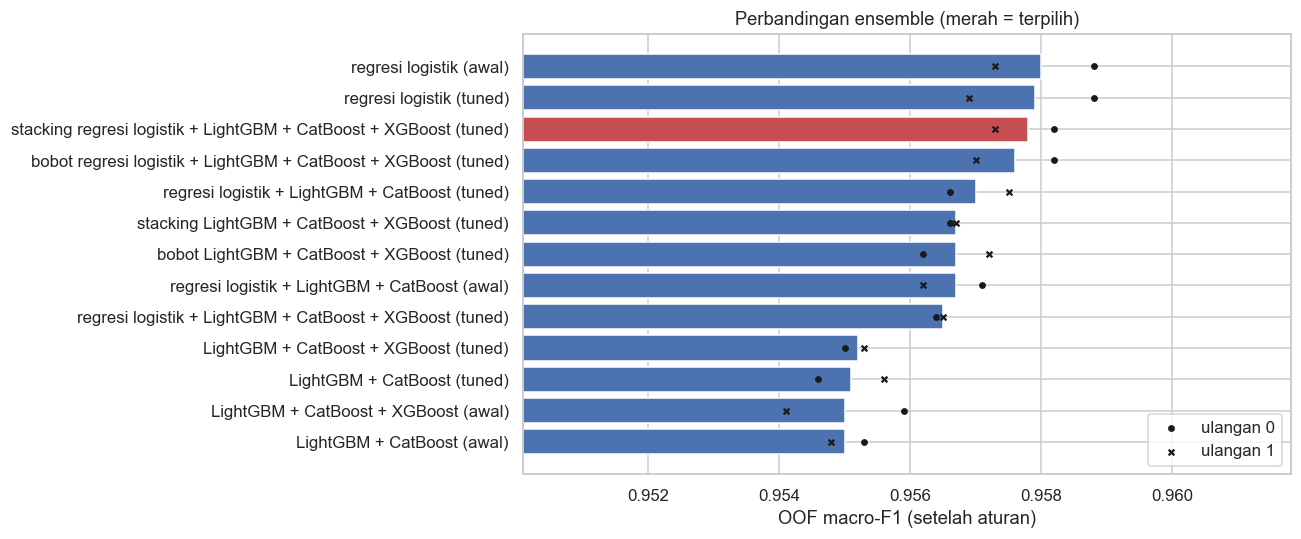

In [32]:
def logit(p): p = np.clip(p, 1e-6, 1 - 1e-6); return np.log(p / (1 - p))
def cari_bobot(Ps, rs):
    m = np.concatenate([MASK_MODEL[r] for r in rs]); y = np.concatenate([Y for _ in rs])[m]
    stack = [np.concatenate([P[r] for r in rs])[m] for P in Ps]
    G = [tuple(k / 10 for k in w) for w in itertools.product(range(11), repeat=len(Ps)) if sum(w) == 10]
    return min(G, key=lambda w: log_loss(y, np.clip(sum(wi * s for wi, s in zip(w, stack)), 1e-6, 1 - 1e-6)))
def latih_stacker(Ps, rs):
    X = np.column_stack([np.concatenate([logit(P[r]) for r in rs]) for P in Ps])
    m = np.concatenate([MASK_MODEL[r] for r in rs]); y = np.concatenate([Y for _ in rs])
    return LogisticRegression(C=1.0, max_iter=2000).fit(X[m], y[m])
def crossfit(Ps, cara):
    out = np.zeros((N_REPEATS, NTR)); info = {}
    for r in range(N_REPEATS):
        lain = [q for q in range(N_REPEATS) if q != r]
        if cara == 'bobot':
            w = cari_bobot(Ps, lain); out[r] = sum(wi * P[r] for wi, P in zip(w, Ps)); info[r] = w
        else:
            s = latih_stacker(Ps, lain); out[r] = s.predict_proba(np.column_stack([logit(P[r]) for P in Ps]))[:, 1]; info[r] = s.coef_.round(3).tolist()
    return out, info
def param_anggota(kind, s): return KANDIDAT[kind] if s == 'awal' else PARAM_TUNED[kind]
def gabung(ps, kf):
    if kf['cara'] == 'rata': return np.mean(ps, 0)
    if kf['cara'] == 'bobot': return sum(w * p for w, p in zip(kf['bobot'], ps))
    if np.ndim(ps[0]) == 2:
        return np.array([kf['stacker'].predict_proba(np.column_stack([logit(p[r]) for p in ps]))[:, 1] for r in range(len(ps[0]))])
    return kf['stacker'].predict_proba(np.column_stack([logit(p) for p in ps]))[:, 1]

NAMA_M = {'logreg': 'regresi logistik', 'lightgbm': 'LightGBM', 'catboost': 'CatBoost', 'xgboost': 'XGBoost'}
SUSUNAN = [(['lightgbm', 'catboost'], 'awal', 'rata'), (['logreg'], 'awal', 'rata'), (['logreg'], 'tuned', 'rata'),
           (['lightgbm', 'catboost'], 'tuned', 'rata'), (['lightgbm', 'catboost', 'xgboost'], 'awal', 'rata'),
           (['lightgbm', 'catboost', 'xgboost'], 'tuned', 'rata'), (['logreg', 'lightgbm', 'catboost'], 'awal', 'rata'),
           (['logreg', 'lightgbm', 'catboost'], 'tuned', 'rata'), (['logreg', 'lightgbm', 'catboost', 'xgboost'], 'tuned', 'rata'),
           (['lightgbm', 'catboost', 'xgboost'], 'tuned', 'bobot'), (['logreg', 'lightgbm', 'catboost', 'xgboost'], 'tuned', 'bobot'),
           (['lightgbm', 'catboost', 'xgboost'], 'tuned', 'stack'), (['logreg', 'lightgbm', 'catboost', 'xgboost'], 'tuned', 'stack')]
KONFIG, INFO_CF = {}, {}
for ms, s, cara in SUSUNAN:
    nama = {'rata': '', 'bobot': 'bobot ', 'stack': 'stacking '}[cara] + ' + '.join(NAMA_M[m] for m in ms) + f' ({s})'
    Ps = [OOF[f'{m} ({s})'] for m in ms]
    if cara == 'rata': P = np.mean(Ps, 0)
    else: P, INFO_CF[nama] = crossfit(Ps, cara)
    KONFIG[nama] = dict(anggota=[(m, s) for m in ms], cara=cara, P=P)
HASIL_ENS = pd.DataFrame({k: nilai(v['P']) for k, v in KONFIG.items()}).T
simpan_tabel(HASIL_ENS, 'perbandingan_ensemble')
for k, v in INFO_CF.items(): print(f'{k}: bobot atau koefisien per ulangan {v}')

DASAR = 'LightGBM + CatBoost (awal)'
oof_ = HASIL_ENS.OOF.astype(float)
SERI = HASIL_ENS[oof_ >= oof_.max() - 0.002]
terbaik = SERI.logloss.astype(float).idxmin()
FINAL = terbaik if float(HASIL_ENS.loc[terbaik, 'OOF']) - float(HASIL_ENS.loc[DASAR, 'OOF']) > 0.002 else DASAR
print('susunan yang seri dengan OOF tertinggi:'); print(SERI[['OOF', 'logloss', 'AUC', 'AP_palsu']].sort_values('logloss').to_string())
KF = KONFIG[FINAL]
THR_F, MARGIN_F = float(HASIL_ENS.loc[FINAL, 'ambang']), float(HASIL_ENS.loc[FINAL, 'margin'])
P_OOF = KF['P']
if KF['cara'] == 'bobot': KF['bobot'] = cari_bobot([OOF[f'{m} ({s})'] for m, s in KF['anggota']], list(range(N_REPEATS)))
if KF['cara'] == 'stack': KF['stacker'] = latih_stacker([OOF[f'{m} ({s})'] for m, s in KF['anggota']], list(range(N_REPEATS)))
KUNCI_F = re.sub(r'[^a-z0-9]+', '_', FINAL.lower()).strip('_')
print(f'OOF tertinggi: {terbaik} ({float(HASIL_ENS.loc[terbaik, "OOF"]):.4f}) | dasar: {float(HASIL_ENS.loc[DASAR, "OOF"]):.4f}')
print(f'MODEL FINAL: {FINAL} | ambang {THR_F} | margin aturan pasangan {MARGIN_F} | OOF macro-F1 {float(HASIL_ENS.loc[FINAL, "OOF"]):.4f}')

fig, ax = plt.subplots(figsize=(9, 5.2))
h_ = HASIL_ENS[['OOF_ulangan0', 'OOF_ulangan1', 'OOF']].astype(float).sort_values('OOF')
ax.barh(h_.index, h_.OOF, color=['#C44E52' if i == FINAL else '#4C72B0' for i in h_.index])
ax.scatter(h_.OOF_ulangan0, h_.index, color='k', s=12, zorder=3, label='ulangan 0')
ax.scatter(h_.OOF_ulangan1, h_.index, color='k', marker='x', s=14, zorder=3, label='ulangan 1')
ax.set_xlim(h_[['OOF_ulangan0', 'OOF_ulangan1']].min().min() - 0.004, h_[['OOF_ulangan0', 'OOF_ulangan1']].max().max() + 0.003)
ax.set_xlabel('OOF macro-F1 (setelah aturan)'); ax.set_title('Perbandingan ensemble (merah = terpilih)'); ax.legend(loc='lower right')
simpan_gambar('09_perbandingan_ensemble')

## 11. Hasil validasi silang

Semua angka di bagian ini berasal dari prediksi OOF model final. Setiap baris train diprediksi oleh model yang tidak pernah melihatnya, dan kondisi memorinya sama seperti di test.

In [33]:
OOF_PRED = np.array([oof_pred(P_OOF[r], r, THR_F, MARGIN_F) for r in range(N_REPEATS)])
def ringkas_prediksi(y, p):
    cm = confusion_matrix(y, p, labels=[0, 1]); f = f1_score(y, p, average=None, labels=[0, 1])
    return dict(macro_F1=(f[0] + f[1]) / 2, F1_palsu=f[0], F1_asli=f[1], presisi_palsu=cm[0, 0] / max(cm[:, 0].sum(), 1),
                recall_palsu=cm[0, 0] / max(cm[0].sum(), 1), tebak_palsu=int(cm[:, 0].sum()), palsu_tertangkap=int(cm[0, 0]),
                palsu_lolos=int(cm[0, 1]), asli_dituduh=int(cm[1, 0]))
per_ulangan = pd.DataFrame({f'ulangan {r}': ringkas_prediksi(Y, OOF_PRED[r]) for r in range(N_REPEATS)}).T
simpan_tabel(per_ulangan, 'hasil_oof_per_ulangan')

rows_ = []
for g in REGIMES:
    m = REG[0] == g
    rows_.append(dict(regime=g, baris=int(m.sum()), porsi_palsu=Y0[m].mean(), tebak_palsu=int((OOF_PRED[0][m] == 0).sum()),
                      tertangkap=int(((OOF_PRED[0] == 0) & (Y == 0) & m).sum()), lolos=int(((OOF_PRED[0] == 1) & (Y == 0) & m).sum()),
                      dituduh=int(((OOF_PRED[0] == 0) & (Y == 1) & m).sum())))
per_regime = pd.DataFrame(rows_).set_index('regime')
per_regime['recall_palsu'] = per_regime.tertangkap / per_regime[['tertangkap', 'lolos']].sum(1).replace(0, np.nan)
per_regime['presisi_palsu'] = per_regime.tertangkap / per_regime.tebak_palsu.replace(0, np.nan)
simpan_tabel(per_regime, 'hasil_oof_per_regime')

fold_sc = []
for r in range(N_REPEATS):
    for k, (a, b) in enumerate(SPLITS[r]): fold_sc.append(dict(ulangan=r, fold=k, macro_F1=f1_score(Y[b], OOF_PRED[r][b], average='macro')))
fold_sc = pd.DataFrame(fold_sc)
rng = np.random.RandomState(SEED); bs = []
for _ in range(1000):
    i = rng.randint(0, NTR, NTR); bs.append(f1_score(Y[i], OOF_PRED[0][i], average='macro'))
CI = np.percentile(bs, [2.5, 97.5])
print(f'macro-F1 per fold: rata-rata {fold_sc.macro_F1.mean():.4f}, simpangan baku {fold_sc.macro_F1.std():.4f}, rentang {fold_sc.macro_F1.min():.4f} sampai {fold_sc.macro_F1.max():.4f}')
print(f'interval kepercayaan bootstrap 95% (ulangan 0): {CI[0]:.4f} sampai {CI[1]:.4f}')
simpan_tabel(fold_sc, 'hasil_oof_per_fold', index=False)

macro-F1 per fold: rata-rata 0.9577, simpangan baku 0.0058, rentang 0.9491 sampai 0.9642
interval kepercayaan bootstrap 95% (ulangan 0): 0.9522 sampai 0.9637


,ulangan,fold,macro_F1
0,0,0,0.964167
1,0,1,0.949083
2,0,2,0.959665
3,0,3,0.954249
4,0,4,0.963698
5,1,0,0.959534
6,1,1,0.960610
7,1,2,0.950017
8,1,3,0.963934
9,1,4,0.952373


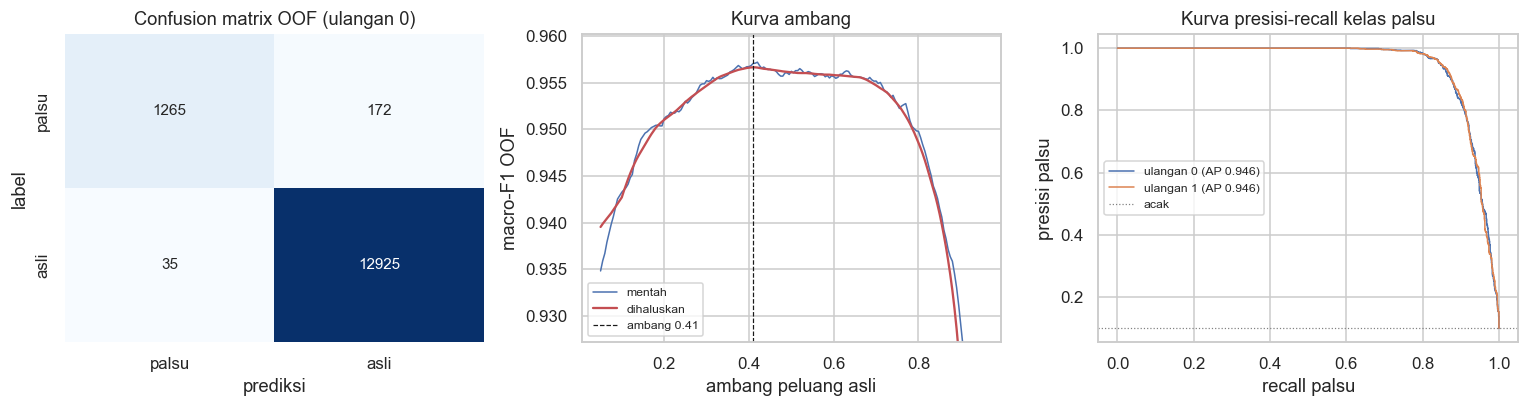

cek teori Lipton: F1 palsu / 2 = 0.462, ambang peluang palsu yang dipakai = 0.590


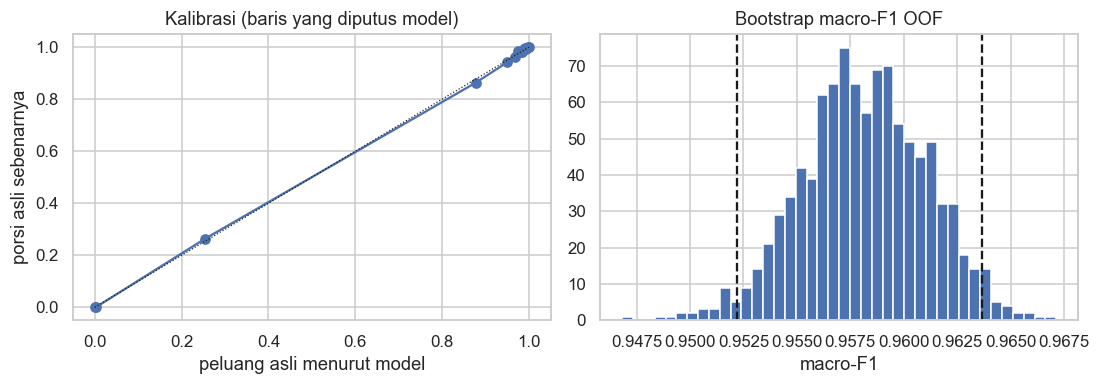

,macro-F1 OOF
tebak semua asli,0.473736
overlap kata judul di konten,0.518380
TF-IDF + regresi logistik,0.513294
tahap 1 saja (fitur judul dan konten),0.672219
logreg (awal),0.958000
lightgbm (awal),0.954800
catboost (awal),0.954600
xgboost (awal),0.954300
LightGBM + CatBoost (awal),0.955000
MODEL FINAL: stacking regresi logistik + LightGBM + CatBoost + XGBoost (tuned),0.957800


In [34]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
cm = confusion_matrix(Y, OOF_PRED[0], labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax[0], xticklabels=['palsu', 'asli'], yticklabels=['palsu', 'asli'])
ax[0].set_xlabel('prediksi'); ax[0].set_ylabel('label'); ax[0].set_title('Confusion matrix OOF (ulangan 0)')

thr_, sc_, grid_, curve_ = best_thr(P_OOF.ravel(), EXLAB.ravel(), np.tile(Y, N_REPEATS), f1=np.tile(F1_TR, N_REPEATS), f0=np.tile(F0_TR, N_REPEATS))
sm_ = np.array([curve_[max(0, i - 10):i + 11].mean() for i in range(len(curve_))])
ax[1].plot(grid_, curve_, color='#4C72B0', lw=1, label='mentah'); ax[1].plot(grid_, sm_, color='#C44E52', label='dihaluskan')
ax[1].axvline(THR_F, color='k', ls='--', lw=0.8, label=f'ambang {THR_F}')
ax[1].set_xlabel('ambang peluang asli'); ax[1].set_ylabel('macro-F1 OOF'); ax[1].set_ylim(curve_.max() - 0.03, curve_.max() + 0.003)
ax[1].set_title('Kurva ambang'); ax[1].legend(fontsize=8)

for r in range(N_REPEATS):
    pr, rc, _ = precision_recall_curve(Y0, 1 - P_OOF[r]); ax[2].plot(rc, pr, lw=1, label=f'ulangan {r} (AP {APS(Y0, 1 - P_OOF[r]):.3f})')
ax[2].axhline(Y0.mean(), color='grey', ls=':', lw=0.8, label='acak')
ax[2].set_xlabel('recall palsu'); ax[2].set_ylabel('presisi palsu'); ax[2].set_title('Kurva presisi-recall kelas palsu'); ax[2].legend(fontsize=8)
plt.tight_layout(); simpan_gambar('10_hasil_oof')

f0_ = per_ulangan.F1_palsu.mean()
print(f'cek teori Lipton: F1 palsu / 2 = {f0_ / 2:.3f}, ambang peluang palsu yang dipakai = {1 - THR_F:.3f}')

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
pm = P_OOF[MASK_MODEL]; ym = np.tile(Y, (N_REPEATS, 1))[MASK_MODEL]
fp_, mp_ = calibration_curve(ym, pm, n_bins=15, strategy='quantile')
ax[0].plot(mp_, fp_, 'o-', color='#4C72B0'); ax[0].plot([0, 1], [0, 1], 'k:', lw=0.8)
ax[0].set_xlabel('peluang asli menurut model'); ax[0].set_ylabel('porsi asli sebenarnya'); ax[0].set_title('Kalibrasi (baris yang diputus model)')
ax[1].hist(bs, bins=40, color='#4C72B0'); ax[1].axvline(CI[0], color='k', ls='--'); ax[1].axvline(CI[1], color='k', ls='--')
ax[1].set_title('Bootstrap macro-F1 OOF'); ax[1].set_xlabel('macro-F1')
plt.tight_layout(); simpan_gambar('11_kalibrasi_bootstrap')

pembanding = pd.Series({**BASELINE, **{f'{k}': float(HASIL_ALGO.loc[k, 'OOF']) for k in HASIL_ALGO.index},
                        f'MODEL FINAL: {FINAL}': float(HASIL_ENS.loc[FINAL, 'OOF'])}, name='macro-F1 OOF').to_frame()
simpan_tabel(pembanding, 'perbandingan_baseline')

**Cara membaca hasil.**

1. Skor per fold bervariasi sekitar ±0,006 di sekitar rata-rata. Variasi ini wajar untuk fold berisi sekitar 2.900 baris dengan hanya sekitar 290 judul palsu. Skor dua ulangan penuh jauh lebih rapat (selisihnya di bawah 0,001), jadi performa model tidak bergantung pada pembagian data tertentu.
2. Teori Lipton memberi patokan ambang peluang palsu sebesar setengah F1 kelas palsu, dengan syarat peluangnya terkalibrasi sempurna. Ambang dari kurva OOF bisa bergeser dari patokan itu karena peluang hasil stacking dan aturan keras ikut memengaruhi keputusan. Kurva di sekitar ambang cukup datar (bagian 13), jadi pergeseran ini hampir tidak mengubah skor.
3. Kesalahan terbesar ada di regime `A_single`, konten baru yang muncul sekali. Di sini model tidak punya judul pembanding sehingga harus mengandalkan detektor token, detektor celah, dan fitur konsistensi.
4. Regime dengan memori (`C_exact`, `B_haspos`) hampir sempurna karena label train lain untuk konten yang sama sangat informatif.

## 12. Ablasi komponen

Setiap percobaan membuang satu komponen, lalu semua anggota model final dilatih ulang dengan validasi 5×2 yang sama dan digabung dengan cara yang sama (untuk stacking, stacker juga dilatih ulang secara cross-fit). Selisih OOF terhadap model lengkap menunjukkan sumbangan komponen itu. Dua komponen berupa aturan keputusan (aturan pasangan dan salin label pasangan persis) cukup dimatikan tanpa melatih ulang.

Kamus domain bekerja lewat detektor token, jadi ablasinya melatih ulang detektor token tanpa fitur kamus.

[cache] ablasi_token_tanpa_kamus dimuat
[cache] ablasi_stacking_regresi_logistik_lightgbm_catboost_xgboost_tuned dimuat


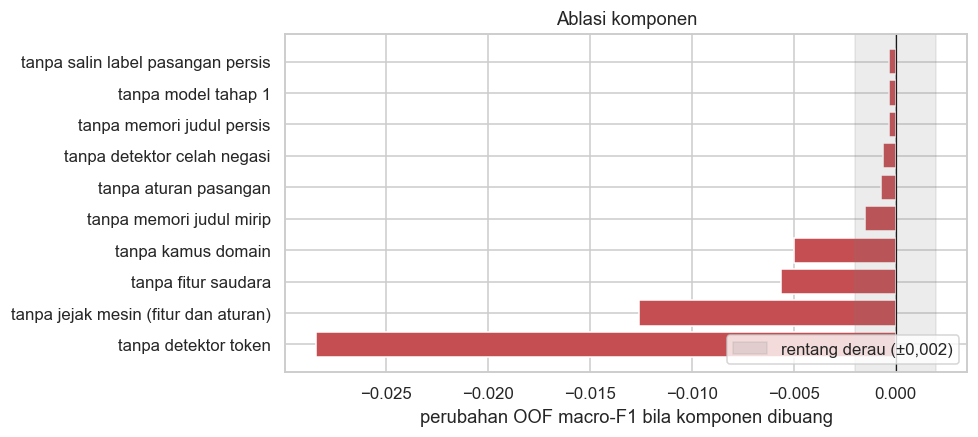

In [35]:
def token_tanpa_kamus():
    X2 = np.column_stack([TOKF[TCOLS].values, EXT_TOK]); cols2 = TCOLS + EXTRA_COLS
    s, _ = token_ronde2(X2, cols2, LT2, W2)
    return ringkas_token(s)
TOKROW_NK = cache('ablasi_token_tanpa_kamus', token_tanpa_kamus)

def final_oof(**kw):
    Ps = [oof_member(kind, param_anggota(kind, s), **kw) for kind, s in KF['anggota']]
    return np.mean(Ps, 0) if KF['cara'] == 'rata' else crossfit(Ps, KF['cara'])[0]
ABLASI_DEF = [
    ('tanpa detektor token', dict(kolom_buang=['tok_max', 'tok_mean', 'tok_2nd'])),
    ('tanpa kamus domain', dict(ganti={c: TOKROW_NK[c].values for c in ['tok_max', 'tok_mean', 'tok_2nd']})),
    ('tanpa detektor celah negasi', dict(kolom_buang=['gap_max'])),
    ('tanpa memori judul mirip', dict(kolom_buang=['tmf_pos', 'tmf_neg', 'orphan'])),
    ('tanpa memori judul persis', dict(kolom_buang=['tm_pos', 'tm_neg'])),
    ('tanpa fitur saudara', dict(kolom_buang=SIB_COLS)),
    ('tanpa model tahap 1', dict(kolom_buang=['p_cons'])),
    ('tanpa jejak mesin (fitur dan aturan)', dict(kolom_buang=list(SURF.columns), pakai_aturan=False))]
def jalankan_ablasi():
    P0 = KF['P']
    hasil = {'model lengkap': nilai(P0)}
    for nama, kw in ABLASI_DEF:
        hasil[nama] = nilai(final_oof(**kw), aturan=kw.get('pakai_aturan', True))
        print(nama, hasil[nama]['OOF'])
    hasil['tanpa aturan pasangan'] = nilai(P0, margins=(TANPA_PASANGAN,))
    hasil['tanpa salin label pasangan persis'] = nilai(P0, pakai_cex=False)
    return pd.DataFrame(hasil).T
ABLASI = cache(f'ablasi_{KUNCI_F}', jalankan_ablasi)
ABLASI['selisih_OOF'] = ABLASI.OOF.astype(float) - float(ABLASI.loc['model lengkap', 'OOF'])
ABLASI['selisih_AP_palsu'] = ABLASI.AP_palsu.astype(float) - float(ABLASI.loc['model lengkap', 'AP_palsu'])
simpan_tabel(ABLASI[['OOF', 'OOF_ulangan0', 'OOF_ulangan1', 'AP_palsu', 'selisih_OOF', 'selisih_AP_palsu', 'ambang']], 'ablasi')

fig, ax = plt.subplots(figsize=(8, 4))
a_ = ABLASI.drop('model lengkap').selisih_OOF.astype(float).sort_values()
ax.barh(a_.index, a_.values, color=['#C44E52' if v < 0 else '#55A868' for v in a_.values])
ax.axvline(0, color='k', lw=0.8); ax.axvspan(-0.002, 0.002, color='grey', alpha=0.15, label='rentang derau (±0,002)')
ax.set_xlabel('perubahan OOF macro-F1 bila komponen dibuang'); ax.set_title('Ablasi komponen'); ax.legend(loc='lower right')
simpan_gambar('12_ablasi')

**Membaca hasil ablasi.** Ablasi hanya melepas komponen sementara untuk mengukur sumbangannya. Model final tetap memakai semua komponen.

Komponen dengan sumbangan besar adalah detektor token, jejak mesin, kamus domain, dan fitur saudara. Beberapa komponen lain tampak hampir tidak menyumbang bila dilepas sendirian. Itu bukan berarti tidak berguna, melainkan informasinya tumpang tindih dengan komponen lain:

1. **Memori judul persis** sudah tercakup memori judul mirip, karena judul yang sama persis punya kemiripan 1,0.
2. **Model tahap 1** meringkas fitur konsistensi yang juga masuk langsung ke model utama.
3. **Detektor celah negasi** menyasar kasus yang sebagian besar sudah tertangkap lewat memori dan saudara, karena pasangan negasi di train biasanya punya judul asli yang ikut terlihat.

Komponen ini tetap kami pakai. Masing-masing punya alasan domain yang jelas, tidak menurunkan skor, dan menjadi cadangan bila struktur data berubah. Contohnya, di data baru yang judul aslinya tidak ikut terlihat, detektor celah menjadi satu-satunya penangkap negasi yang dihapus.

## 13. Ketahanan model

Skor privat leaderboard berbobot 70% dari skor Kaggle, jadi model harus stabil, bukan hanya bagus di satu pembagian data. Kami memeriksa tiga hal:

1. **Seed.** Model final dilatih ulang dengan tiga seed lain pada pembagian ulangan 0, lalu dilatih akhir dengan seed yang sama untuk melihat berapa prediksi test yang berubah.
2. **Ambang.** Seberapa turun skor bila ambang meleset sedikit.
3. **Variasi antar fold**, dari bagian 11.

In [36]:
SEED_UJI = [SEED + 1000, SEED + 2000, SEED + 3000]
def uji_seed():
    out = {}
    d = DESAIN['akhir']
    for sd in SEED_UJI:
        oofs, tes = [], []
        for kind, s in KF['anggota']:
            oofs.append(oof_member(kind, param_anggota(kind, s), seed=sd, ulangan=[0])[0])
            tes.append(pred_member(fit_member(kind, param_anggota(kind, s), d['Xtr'][~F1_TR], Y[~F1_TR], sd), d['Xte']))
        out[sd] = dict(oof=gabung(oofs, KF), te=gabung(tes, KF))
    return out
SEED_HASIL = cache(f'ketahanan_seed_{KUNCI_F}', uji_seed)
seed_tab = pd.DataFrame({f'seed {sd}': ringkas_prediksi(Y, oof_pred(v['oof'], 0, THR_F, MARGIN_F)) for sd, v in SEED_HASIL.items()}).T
seed_tab.loc[f'seed {SEED} (utama)'] = ringkas_prediksi(Y, OOF_PRED[0])
simpan_tabel(seed_tab, 'ketahanan_seed')
print(f'rentang macro-F1 OOF antar seed: {seed_tab.macro_F1.min():.4f} sampai {seed_tab.macro_F1.max():.4f} (selisih {seed_tab.macro_F1.max() - seed_tab.macro_F1.min():.4f})')

sens = []
for dt in [-0.15, -0.1, -0.05, -0.02, 0, 0.02, 0.05, 0.1, 0.15]:
    t = float(np.clip(THR_F + dt, 0.05, 0.95))
    sens.append(dict(ambang=round(t, 3), macro_F1=np.mean([f1_score(Y, oof_pred(P_OOF[r], r, t, MARGIN_F), average='macro') for r in range(N_REPEATS)])))
sens = pd.DataFrame(sens).set_index('ambang'); sens['selisih'] = sens.macro_F1 - sens.loc[round(THR_F, 3), 'macro_F1']
simpan_tabel(sens, 'kepekaan_ambang')

[cache] ketahanan_seed_stacking_regresi_logistik_lightgbm_catboost_xgboost_tuned dimuat
rentang macro-F1 OOF antar seed: 0.9574 sampai 0.9582 (selisih 0.0008)


,macro_F1,selisih
ambang,,
0.26,0.954934,-0.002833
0.31,0.956458,-0.001310
0.36,0.957411,-0.000356
0.39,0.957617,-0.000150
0.41,0.957767,0.000000
0.43,0.957433,-0.000335
0.46,0.957328,-0.000439
0.51,0.957429,-0.000338
0.56,0.956996,-0.000771


Selisih antar seed dan antar ambang di sekitar titik terpilih kecil. Ini yang membuat kami memakai batas 0,002 saat memilih model di bagian 10: perbedaan sekecil itu bisa muncul hanya karena seed.

## 14. Latih akhir dan submission

Model final dilatih ulang di seluruh train (tanpa baris yang sudah pasti asli). Memori test adalah seluruh train. Ambang dan margin aturan pasangan diambil dari OOF di bagian 10, lalu aturan keras diterapkan dengan urutan: ambang, jejak mesin, salin label pasangan persis, aturan pasangan.

In [37]:
def latih_akhir(kind, params, seed=SEED):
    d = DESAIN['akhir']
    ms = fit_member(kind, params, d['Xtr'][~F1_TR], Y[~F1_TR], seed)
    return ms, pred_member(ms, d['Xte'])
AKHIR = {}
for kind, s in KF['anggota']:
    AKHIR[(kind, s)] = cache(f'akhir_{kind}_{s}', lambda: latih_akhir(kind, param_anggota(kind, s)))
P_TE = gabung([AKHIR[a][1] for a in KF['anggota']], KF)
PRED_TE = test_pred(P_TE, THR_F, MARGIN_F)

sub = pd.DataFrame({'id': te.id.values, 'label': PRED_TE})
assert len(sub) == NTE and set(sub.label.unique()) <= {0, 1} and set(sub.id) == set(sample.id)
sub = sub.set_index('id').loc[sample.id].reset_index()
sub.to_csv(os.path.join(OUT_DIR, 'submission.csv'), index=False)
pd.DataFrame({'id': te.id.values, 'p_asli': P_TE, 'regime': REG_TE, 'label': PRED_TE}).to_csv(os.path.join(OUT_DIR, 'test_proba.csv'), index=False)
pd.DataFrame({'id': tr.id.values, 'p_asli_oof': P_OOF.mean(0), 'regime': REG[0], 'prediksi_oof': OOF_PRED[0], 'label': Y}).to_csv(os.path.join(OUT_DIR, 'oof.csv'), index=False)
with open(os.path.join(OUT_DIR, 'model_final.pkl'), 'wb') as f:
    pickle.dump(dict(konfigurasi=FINAL, anggota=KF['anggota'], model={f'{k}_{s}': AKHIR[(k, s)][0] for k, s in KF['anggota']},
                     cara=KF['cara'], bobot=KF.get('bobot'), stacker=KF.get('stacker'), ambang=THR_F, margin=MARGIN_F, fitur=FEATS), f)
print('submission:', sub.shape, '| tebak palsu =', int((sub.label == 0).sum()), f'({(sub.label == 0).mean():.2%})')

cek = pd.DataFrame({'baris test': pd.Series(REG_TE).value_counts(), 'tebak palsu test': pd.Series(PRED_TE == 0).groupby(REG_TE).sum(),
                    'porsi tebak palsu test': pd.Series(PRED_TE == 0).groupby(REG_TE).mean(),
                    'porsi tebak palsu OOF': pd.Series(OOF_PRED[0] == 0).groupby(REG[0]).mean()}).reindex(REGIMES)
cek.loc['total'] = [NTE, int((PRED_TE == 0).sum()), (PRED_TE == 0).mean(), (OOF_PRED[0] == 0).mean()]
simpan_tabel(cek, 'cek_submission_per_regime')
flip = {f'seed {sd}': int((test_pred(v['te'], THR_F, MARGIN_F) != PRED_TE).sum()) for sd, v in SEED_HASIL.items()}
print('prediksi test yang berubah bila seed diganti:', flip, f'dari {NTE} baris')

[cache] akhir_logreg_tuned dimuat
[cache] akhir_lightgbm_tuned dimuat
[cache] akhir_catboost_tuned dimuat


[cache] akhir_xgboost_tuned dimuat
submission: (3603, 2) | tebak palsu = 322 (8.94%)


prediksi test yang berubah bila seed diganti: {'seed 1042': 4, 'seed 2042': 2, 'seed 3042': 1} dari 3603 baris


Porsi tebakan palsu per regime di test mirip dengan di OOF. Tidak ada regime yang tiba-tiba ditebak jauh lebih banyak atau lebih sedikit, jadi prediksi test konsisten dengan perilaku model saat validasi.

## 15. Analisis pasca prediksi

### 15.1 Kesalahan menurut jenis pemalsuan

Untuk judul palsu yang punya pasangan minimal di train, jenis pemalsuannya diketahui dari sensus bagian 4.4. Kami hitung berapa persen tiap jenis yang tertangkap di OOF.

Catatan penting: baris seperti ini hampir selalu berada di regime yang mudah, karena judul asli pasangannya ikut terlihat di memori atau sebagai saudara. Kesalahan nyata terkumpul di `A_single`, dan di sana jenis pemalsuannya tidak diketahui langsung. Karena itu tabel kedua memberi **perkiraan jenis dari jejak teks** untuk judul palsu `A_single`: judul lebih cocok ke konten lain berarti judul pinjaman, ada kata judul yang tidak muncul di konten berarti ganti kata, ada celah negasi berarti hapus negasi, sisanya lain-lain.

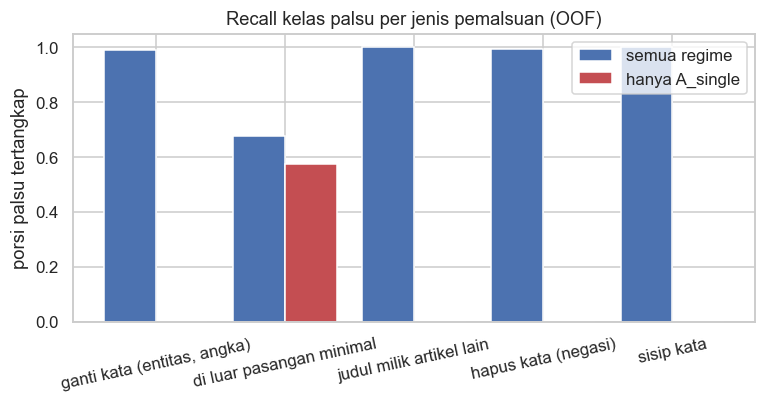

,judul_palsu,tertangkap,recall,porsi_dari_yang_lolos
judul milik artikel lain (perkiraan),197,125,0.634518,0.493151
ganti kata (perkiraan),132,69,0.522727,0.431507
"lain-lain (parafrasa, tukar peran)",7,1,0.142857,0.041096
hapus negasi (perkiraan),6,1,0.166667,0.034247


In [38]:
JENIS_ROW = np.array(['asli' if Y[i] == 1 else JENIS_KEY.get((TH[i], CH[i]), 'di luar pasangan minimal') for i in range(NTR)], dtype=object)
JENIS_ROW = np.array([NAMA_JENIS.get(j, j) for j in JENIS_ROW], dtype=object)
jr = []
for j in [x for x in pd.Series(JENIS_ROW).value_counts().index if x != 'asli']:
    m = JENIS_ROW == j
    rc = [((OOF_PRED[r] == 0) & m).sum() / m.sum() for r in range(N_REPEATS)]
    jr.append(dict(jenis=j, judul_palsu=int(m.sum()), recall_rata2=np.mean(rc),
                   recall_A_single=((OOF_PRED[0] == 0) & m & (REG[0] == 'A_single')).sum() / max((m & (REG[0] == 'A_single')).sum(), 1),
                   baris_A_single=int((m & (REG[0] == 'A_single')).sum())))
JENIS_TAB = pd.DataFrame(jr).set_index('jenis')
simpan_tabel(JENIS_TAB, 'recall_per_jenis')
fig, ax = plt.subplots(figsize=(8, 3.4))
x_ = np.arange(len(JENIS_TAB))
ax.bar(x_ - 0.2, JENIS_TAB.recall_rata2, 0.4, label='semua regime', color='#4C72B0')
ax.bar(x_ + 0.2, JENIS_TAB.recall_A_single, 0.4, label='hanya A_single', color='#C44E52')
ax.set_xticks(x_); ax.set_xticklabels(JENIS_TAB.index, rotation=12); ax.set_ylabel('porsi palsu tertangkap'); ax.legend()
ax.set_title('Recall kelas palsu per jenis pemalsuan (OOF)'); simpan_gambar('13_recall_per_jenis')

def perkiraan_jenis(i):
    if VEC.ret_margin.values[i] < 0: return 'judul milik artikel lain (perkiraan)'
    if CONS.n_miss_ns.values[i] > 0: return 'ganti kata (perkiraan)'
    if GAPROW.gap_max.values[i] > 0: return 'hapus negasi (perkiraan)'
    return 'lain-lain (parafrasa, tukar peran)'
ms_ = (REG[0] == 'A_single') & (Y == 0)
PJ = pd.Series([perkiraan_jenis(i) for i in np.where(ms_)[0]], index=np.where(ms_)[0])
PJ_TAB = pd.DataFrame({'judul_palsu': PJ.value_counts(),
                       'tertangkap': pd.Series(OOF_PRED[0][PJ.index] == 0, index=PJ.index).groupby(PJ).sum()})
PJ_TAB['recall'] = PJ_TAB.tertangkap / PJ_TAB.judul_palsu
PJ_TAB['porsi_dari_yang_lolos'] = (PJ_TAB.judul_palsu - PJ_TAB.tertangkap) / (PJ_TAB.judul_palsu - PJ_TAB.tertangkap).sum()
simpan_tabel(PJ_TAB.sort_values('judul_palsu', ascending=False), 'recall_A_single_perkiraan_jenis')

### 15.2 Contoh kesalahan

Contoh judul palsu yang lolos dengan keyakinan paling tinggi, dan judul asli yang dituduh palsu. Untuk judul palsu dari pasangan minimal, judul aslinya ikut ditampilkan supaya jelas apa yang diubah.

In [39]:
ASLI_DARI = {(nh(b), nh(c)): a for a, b, c in PAIRS}
pm0 = P_OOF.mean(0)
def potong(s, n=22): w = str(s).split(); return ' '.join(w[:n]) + (' ...' if len(w) > n else '')
fn_ = np.where((Y == 0) & (OOF_PRED[0] == 1))[0]; fn_ = fn_[np.argsort(-pm0[fn_])][:10]
fp_ = np.where((Y == 1) & (OOF_PRED[0] == 0))[0]; fp_ = fp_[np.argsort(pm0[fp_])][:8]
CONTOH_FN = pd.DataFrame({'id': tr.id.values[fn_], 'regime': REG[0][fn_], 'jenis': JENIS_ROW[fn_], 'p_asli': pm0[fn_].round(3),
                          'judul (palsu)': tr.title.values[fn_], 'judul asli pasangannya': [ASLI_DARI.get((TH[i], CH[i]), '-') for i in fn_],
                          'awal konten': [potong(tr.content.values[i]) for i in fn_]})
CONTOH_FP = pd.DataFrame({'id': tr.id.values[fp_], 'regime': REG[0][fp_], 'p_asli': pm0[fp_].round(3),
                          'judul (asli)': tr.title.values[fp_], 'awal konten': [potong(tr.content.values[i]) for i in fp_]})
simpan_tabel(CONTOH_FN, 'contoh_palsu_lolos', index=False); simpan_tabel(CONTOH_FP, 'contoh_asli_dituduh', index=False)
print('PALSU YANG LOLOS'); print(CONTOH_FN.drop(columns='awal konten').to_string(index=False))
print('\nASLI YANG DITUDUH PALSU'); print(CONTOH_FP.drop(columns='awal konten').to_string(index=False))

PALSU YANG LOLOS
     id   regime                    jenis  p_asli                                                                                   judul (palsu) judul asli pasangannya
tr02729 A_single di luar pasangan minimal   0.994                           4 Poin Pernyataan Maaf Pihak Klinik Bumame Farmasi soal Pemalsuan PCR                      -
tr01103 A_single di luar pasangan minimal   0.994                                       Satgas COVID 19 Kembali Imbau Bepergian Jika Tak Mendesak                      -
tr07789 A_single di luar pasangan minimal   0.993                                     Polda Jabar Tetapkan Tersangka Kasus Kerumunan Habib Rizieq                      -
tr08756 A_single di luar pasangan minimal   0.993                             PMI Surabaya Terima 1 200 Kantong Plasma Konvalesen Hingga Saat Ini                      -
tr01661 A_single di luar pasangan minimal   0.990                               Ini Alasan Polisi Tetapkan Nakes Wisma Atlet Jadi Tersangk

### 15.3 Cara kerja satu prediksi

Kami ambil satu baris test di regime `A_single` yang ditebak palsu dengan skor detektor token tertinggi, lalu mengikuti jalannya keputusan: skor setiap kata judul, kandidat kata asli dari awal konten, dan fitur yang paling mendorong keputusan. Kontribusi dihitung per anggota model final dalam satuan log-odds. Untuk regresi logistik kontribusinya adalah koefisien dikali nilai fitur yang sudah distandardisasi, dan untuk model pohon dipakai nilai SHAP bawaan librarinya.

In [40]:
cand_ = np.where((REG_TE == 'A_single') & (PRED_TE == 0) & ~F0_TE)[0]
k_ = cand_[np.argmax(TOKROW.tok_max.values[NTR + cand_])]; i_ = NTR + k_
print('id:', te.id.values[k_], '| peluang asli:', round(P_TE[k_], 3), '| prediksi:', PRED_TE[k_])
print('judul :', te.title.values[k_])
print('konten:', potong(te.content.values[k_], 45))
tk = TOKF[TOKF.row == i_].assign(skor_pengganti=TOK_S[TOKF.row.values == i_])
lw_, M_, _, _, _ = lead_info(CH[i_], ALL.content.values[i_]); S_ = set(TH[i_].split())
def kandidat_asli(w):
    v = vec(w); c = [x for x in lw_ if x not in S_]
    if v is None or not c: return '-'
    s = np.array([vec(x) @ v for x in c]); return f'{c[int(np.argmax(s))]} ({s.max():.2f})'
tk['kandidat kata asli di awal konten'] = [kandidat_asli(w) for w in tk.kata]
TOKEN_DEMO = tk[['kata', 'skor_pengganti', 'in_c', 'first', 'kandidat kata asli di awal konten']].rename(columns={'in_c': 'ada di konten', 'first': 'posisi pertama'})
simpan_tabel(TOKEN_DEMO.round(3), 'demo_skor_token', index=False); print(TOKEN_DEMO.round(3).to_string(index=False))

def fitur_dasar(n): return n.replace('missingindicator_', '')
def kontribusi(kind, ms, X):
    if kind == 'logreg':
        pre, lr = ms[0][:-1], ms[0][-1]
        c = pd.Series(lr.coef_[0] * pre.transform(X)[0], index=pre.get_feature_names_out())
        return c.groupby(c.index.map(fitur_dasar)).sum().reindex(FEATS)
    if kind == 'lightgbm':
        return pd.Series(np.mean([m.predict(X, pred_contrib=True)[0][:-1] for m in ms], 0), index=FEATS)
    if kind == 'catboost':
        return pd.Series(ms[0].get_feature_importance(cb.Pool(X), type='ShapValues')[0][:-1], index=FEATS)
    return pd.Series(ms[0].get_booster().predict(xgb.DMatrix(X), pred_contribs=True)[0][:-1], index=FEATS)
xr = DESAIN['akhir']['Xte'].iloc[[k_]]
KONTRIB = pd.DataFrame({f'{NAMA_M[k]} ({s})': kontribusi(k, AKHIR[(k, s)][0], xr) for k, s in KF['anggota']})
KONTRIB['rata-rata'] = KONTRIB.mean(1)
KONTRIB = KONTRIB.loc[KONTRIB['rata-rata'].abs().sort_values(ascending=False).index].head(12)
KONTRIB.insert(0, 'nilai fitur', xr.iloc[0][KONTRIB.index].values); KONTRIB.insert(0, 'kelompok', KONTRIB.index.map(KELOMPOK))
simpan_tabel(KONTRIB.round(4), 'demo_kontribusi_fitur'); print(KONTRIB.round(4).to_string())

id: te01137 | peluang asli: 0.034 | prediksi: 0
judul : WNA Asal Rusia Meninggal di Timika Papua Diduga Akibat COVID 19
konten: Seorang WNA asal Ukraina bernama Mr Volodymyr Pedenko 58 meninggal di Timika Papua Pedenko meninggal diduga akibat COVID 19 Iya benar dia orang Ukraina kru De Monim Air meninggal diduga Corona Kata Kepala Imigrasi Kelas II TPI Mimika Jesaja Samuel Enock kepada wartawan Selasa 17 ...
     kata  skor_pengganti  ada di konten  posisi pertama kandidat kata asli di awal konten
      wna             0.0            1.0           0.007                   imigrasi (0.54)
     asal             0.0            1.0           0.015                    seorang (0.55)
    rusia             1.0            0.0           1.500                    ukraina (0.67)
meninggal             0.0            1.0           0.066                  volodymyr (0.57)
   timika             0.0            1.0           0.080                    pedenko (0.80)
    papua             0.0            1.0  

                               kelompok  nilai fitur  regresi logistik (tuned)  LightGBM (tuned)  CatBoost (tuned)  XGBoost (tuned)  rata-rata
tok_max                  detektor token       1.0000                   -2.2321           -3.6131           -3.3283          -2.6593    -2.9582
tok_mean                 detektor token       0.1000                   -2.8431           -2.5976           -3.3536          -2.5391    -2.8333
n_pair                       struktural       1.0000                   -0.5358           -0.6341           -0.2456          -0.2902    -0.4264
n_th                         struktural       1.0000                   -0.5005           -0.1772           -0.1802           0.0012    -0.2142
ent_first_max  konsistensi judul-konten       1.0000                    0.8273            0.0137           -0.0329          -0.0081     0.2000
n_ent          konsistensi judul-konten       5.0000                    0.2218            0.1089            0.2149           0.2087     0.1886

Kontribusi negatif mendorong ke arah palsu, kontribusi positif ke arah asli.

### 15.4 Fitur terpenting secara global

Setiap anggota punya ukuran kepentingan sendiri: besar koefisien terstandardisasi untuk regresi logistik, gain untuk LightGBM dan XGBoost, dan kepentingan bawaan CatBoost. Semuanya dinormalkan menjadi porsi lalu dirata-rata.

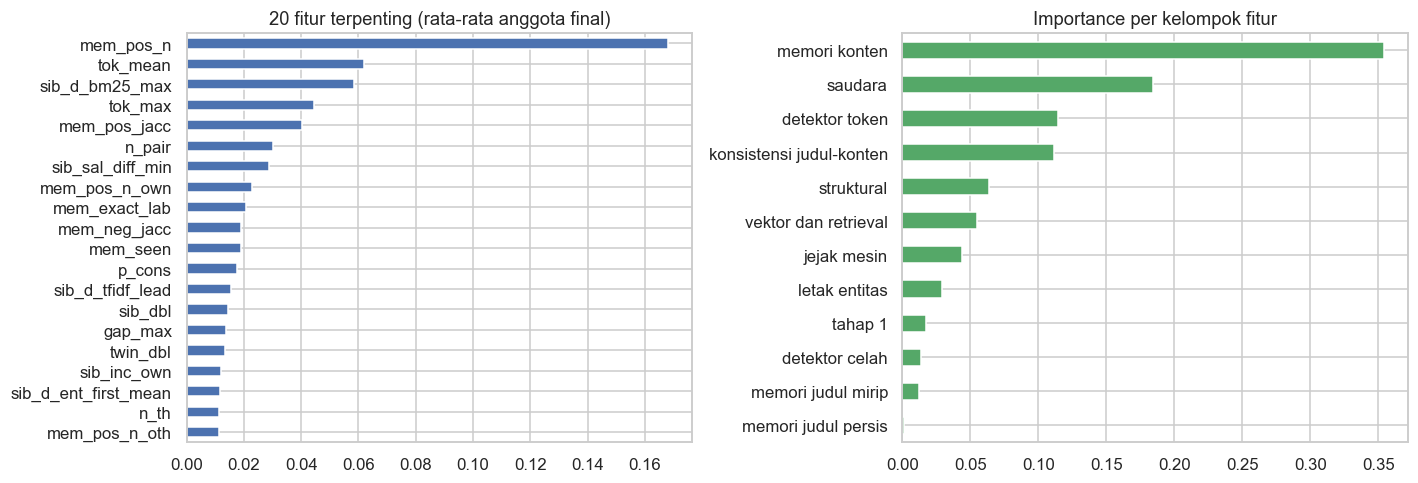

In [41]:
def importance(kind, ms):
    if kind == 'logreg':
        pre, lr = ms[0][:-1], ms[0][-1]
        c = pd.Series(np.abs(lr.coef_[0]), index=pre.get_feature_names_out())
        v = c.groupby(c.index.map(fitur_dasar)).sum().reindex(FEATS).fillna(0)
    elif kind == 'lightgbm':
        v = pd.concat([pd.Series(m.booster_.feature_importance('gain'), index=FEATS) for m in ms], axis=1).mean(1)
    elif kind == 'catboost':
        v = pd.Series(ms[0].get_feature_importance(), index=FEATS)
    else:
        v = pd.Series(ms[0].get_booster().get_score(importance_type='gain')).reindex(FEATS).fillna(0)
    return v / v.sum()
IMP_M = pd.DataFrame({f'{NAMA_M[k]} ({s})': importance(k, AKHIR[(k, s)][0]) for k, s in KF['anggota']})
IMP_M['rata-rata'] = IMP_M.mean(1)
per_kel = IMP_M.groupby(pd.Series(KELOMPOK)).sum().sort_values('rata-rata', ascending=False)
simpan_tabel(IMP_M.sort_values('rata-rata', ascending=False).head(25), 'importance_top25')
simpan_tabel(per_kel, 'importance_per_kelompok')
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
IMP_M['rata-rata'].sort_values().tail(20).plot.barh(ax=ax[0], color='#4C72B0'); ax[0].set_title('20 fitur terpenting (rata-rata anggota final)')
per_kel['rata-rata'].sort_values().plot.barh(ax=ax[1], color='#55A868'); ax[1].set_title('Importance per kelompok fitur')
plt.tight_layout(); simpan_gambar('14_importance')

### 15.5 Sebaran skor test dibanding OOF

Kalau sebaran skor test sangat berbeda dari OOF, ambang yang dipilih dari OOF bisa kurang pas. Kami bandingkan porsi baris di bawah ambang per regime (hanya baris yang diputus model) dan jumlah baris test yang skornya dekat ambang.

In [42]:
geser = []
for g in REGIMES:
    mo = (REG[0] == g) & np.isnan(EXLAB[0]) & ~F1_TR & ~F0_TR; mt = (REG_TE == g) & np.isnan(EXT) & ~F1_TE & ~F0_TE
    if mo.sum() < 5 or mt.sum() < 5: continue
    geser.append(dict(regime=g, baris_oof=int(mo.sum()), baris_test=int(mt.sum()), di_bawah_ambang_oof=(P_OOF[0][mo] < THR_F).mean(),
                      di_bawah_ambang_test=(P_TE[mt] < THR_F).mean(), p_KS=ks_2samp(P_OOF[0][mo], P_TE[mt]).pvalue))
simpan_tabel(pd.DataFrame(geser).set_index('regime'), 'sebaran_test_vs_oof')
dekat = np.abs(P_TE - THR_F) < 0.05
print(f'tebak palsu: OOF {(OOF_PRED[0] == 0).sum()} dari {(Y == 0).sum()} label palsu (rasio {(OOF_PRED[0] == 0).sum() / (Y == 0).sum():.3f}) | '
      f'test {(PRED_TE == 0).sum()} dari harapan {Y0.mean() * NTE:.0f} (rasio {(PRED_TE == 0).sum() / (Y0.mean() * NTE):.3f})')
print(f'baris test dengan skor dalam ±0,05 dari ambang: {dekat.sum()} ({dekat.mean():.2%})')

tebak palsu: OOF 1300 dari 1437 label palsu (rasio 0.905) | test 322 dari harapan 360 (rasio 0.895)
baris test dengan skor dalam ±0,05 dari ambang: 10 (0.28%)


### 15.6 Keterbatasan

1. **Judul milik artikel lain** yang topiknya mirip tetap sulit. Judul seperti ini konsisten dengan kontennya, jadi tanpa sumber artikel aslinya model hanya bisa mengandalkan memori judul dan kemiripan lintas konten.
2. **Negasi yang dihapus lalu diparafrasakan** ("tidak memaksa" menjadi "Paksa") tidak selalu tertangkap detektor celah, karena kata di judul tidak persis sama dengan kata sesudah negasi di konten.
3. **Tukar peran** (pelaku dan korban bertukar tempat) tidak mengubah himpunan kata, sehingga fitur berbasis kata hampir buta terhadapnya. Ini butuh pemahaman struktur kalimat.
4. **Jejak spasi adalah artefak dataset ini**, bukan ciri umum judul palsu. Di dunia nyata aturan ini tidak berlaku (bagian 16).
5. Kamus domain berisi tokoh dan istilah 2020 sampai 2021. Untuk data dari periode lain, kamus perlu diperbarui.

## 16. Rekomendasi strategis

Model ini bisa dipakai di tiga tempat: **redaksi berita** (memeriksa judul sebelum terbit), **platform cek fakta** (memprioritaskan artikel yang perlu diperiksa), dan **platform media sosial atau agregator berita** (memberi label "judul mungkin tidak sesuai isi").

Di dunia nyata biaya kesalahannya tidak seimbang. Menuduh judul asli sebagai palsu merusak kepercayaan pada redaksi, sedangkan meloloskan judul palsu merugikan pembaca. Karena itu kami tidak menyarankan satu ambang saja, melainkan beberapa titik operasi. Tingkat "tandai otomatis" memakai ambang terbesar yang presisinya masih minimal 98%, jadi hampir tidak ada judul asli yang ikut diberi label. Tingkat "antrean tinjau" memakai ambang terkecil yang sudah menangkap 95% judul palsu, dengan konsekuensi lebih banyak artikel yang harus diperiksa manusia.

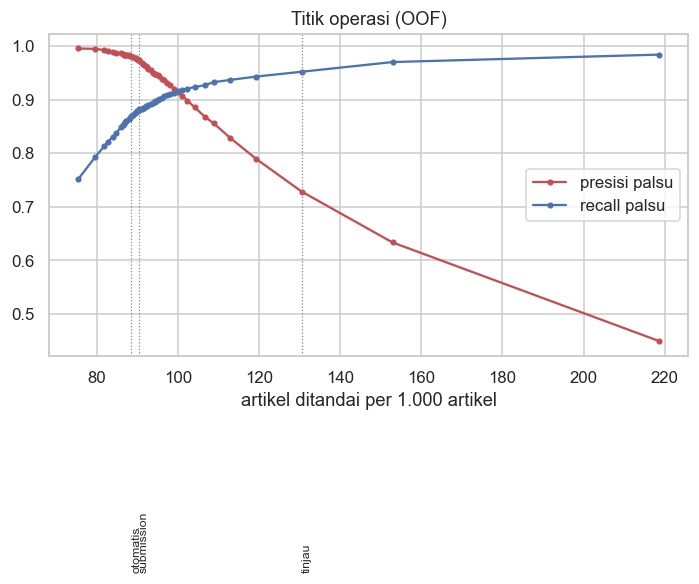

In [43]:
def titik_operasi(t, r=0):
    p = oof_pred(P_OOF[r], r, t, MARGIN_F)
    tp = ((p == 0) & (Y == 0)).sum(); fp = ((p == 0) & (Y == 1)).sum()
    return dict(ambang=t, ditandai_per_1000=1000 * (p == 0).mean(), presisi_palsu=tp / max(tp + fp, 1), recall_palsu=tp / (Y == 0).sum(),
                macro_F1=f1_score(Y, p, average='macro'))
TO = pd.DataFrame([titik_operasi(float(t)) for t in sorted(set(np.round(np.arange(0.02, 0.99, 0.02), 2)) | {THR_F})]).set_index('ambang')
t_otomatis = float(TO[TO.presisi_palsu >= 0.98].index.max()) if (TO.presisi_palsu >= 0.98).any() else float(TO.index.min())
t_luas = float(TO[TO.recall_palsu >= 0.95].index.min()) if (TO.recall_palsu >= 0.95).any() else float(TO.recall_palsu.idxmax())
TINGKAT = pd.DataFrame([dict(tingkat='tandai otomatis', syarat=f'peluang asli < {t_otomatis:.2f}', **titik_operasi(t_otomatis)),
                        dict(tingkat='titik skor terbaik (dipakai di submission)', syarat=f'peluang asli < {THR_F:.2f}', **titik_operasi(THR_F)),
                        dict(tingkat='antrean tinjau manusia', syarat=f'peluang asli < {t_luas:.2f}', **titik_operasi(t_luas))]).set_index('tingkat')
simpan_tabel(TINGKAT, 'tingkat_operasi')
simpan_tabel(TO.loc[[t for t in TO.index if round(t * 100) % 10 == 0 or t == THR_F]], 'titik_operasi')

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(TO.ditandai_per_1000, TO.presisi_palsu, 'o-', ms=3, label='presisi palsu', color='#C44E52')
ax.plot(TO.ditandai_per_1000, TO.recall_palsu, 'o-', ms=3, label='recall palsu', color='#4C72B0')
for nm, t in [('otomatis', t_otomatis), ('submission', THR_F), ('tinjau', t_luas)]:
    x = titik_operasi(t)['ditandai_per_1000']; ax.axvline(x, color='grey', ls=':', lw=0.8); ax.text(x, 0.02, nm, rotation=90, fontsize=8)
ax.set_xlabel('artikel ditandai per 1.000 artikel'); ax.set_title('Titik operasi (OOF)'); ax.legend()
simpan_gambar('15_titik_operasi')

**Rekomendasi**

1. **Pakai tiga tingkat, bukan satu keputusan.** Artikel di tingkat "tandai otomatis" presisinya sangat tinggi dan bisa langsung diberi label peringatan. Tingkat "antrean tinjau" menangkap lebih banyak judul palsu dengan presisi lebih rendah, jadi sebaiknya diperiksa editor atau pemeriksa fakta. Sisanya dibiarkan lolos. Dengan cara ini beban kerja manusia hanya puluhan artikel per 1.000, bukan seluruhnya.
2. **Tampilkan alasannya.** Detektor token menunjuk kata judul yang paling mungkin diganti beserta kandidat kata aslinya di awal konten (bagian 15.3). Editor bisa memeriksa satu kata itu, bukan membaca ulang seluruh artikel.
3. **Prioritaskan pemeriksaan pada kata yang paling sering dipalsukan.** Nama wilayah, tokoh, lembaga, angka, dan kata negasi adalah titik rawan. Redaksi bisa menjadikan kecocokan kata-kata ini dengan paragraf pembuka sebagai daftar periksa wajib sebelum terbit.
4. **Sambungkan dengan arsip judul.** Memori judul menunjukkan judul yang sudah pernah dipakai artikel lain adalah tanda kuat judul pinjaman. Platform yang punya arsip artikel sendiri bisa memakai pencocokan judul lintas artikel sebagai pemeriksaan murah.
5. **Jangan membawa jejak spasi ke dunia nyata.** Aturan spasi ganda sangat kuat di dataset ini karena cara panitia membuat judul palsu, bukan karena sifat judul palsu pada umumnya. Sistem produksi harus dilatih ulang tanpa fitur ini dan dengan contoh pemalsuan dari kasus nyata.
6. **Perbarui kamus secara berkala.** Pengganti yang paling sering adalah entitas sejenis. Kamus wilayah, jabatan, dan tokoh yang mutakhir langsung meningkatkan kemampuan detektor token.

## 17. Reproducibility

Hash SHA-256 berkas keluaran bisa dibandingkan antar run. Dua eksekusi dengan lingkungan yang sama menghasilkan hash yang sama. Profil waktu menunjukkan tahap mana yang paling berat, dan daftar cache menunjukkan pickle yang dipakai run berikutnya.

In [44]:
def sha(p):
    with open(p, 'rb') as f: return hashlib.sha256(f.read()).hexdigest()[:16]
HASH = pd.DataFrame([(f, sha(os.path.join(OUT_DIR, f))) for f in ['submission.csv', 'test_proba.csv', 'oof.csv']], columns=['berkas', 'sha256 (16 karakter)'])
print(HASH.to_string(index=False))
print(json.dumps(dict(SEED=SEED, N_SPLITS=N_SPLITS, N_REPEATS=N_REPEATS, N_TRIALS=N_TRIALS, N_THREADS=N_THREADS, PAKAI_CACHE=PAKAI_CACHE, **VERSI), indent=1))
prof = pd.Series(TIMES, name='detik').sort_values(ascending=False).to_frame()
prof['menit'] = prof.detik / 60
print(prof.round(1).to_string())
isi = pd.DataFrame([(f, os.path.getsize(os.path.join(CACHE_DIR, f)) / 1e6) for f in sorted(os.listdir(CACHE_DIR))], columns=['pickle', 'MB'])
print(isi.round(1).to_string(index=False), f'\ntotal cache {isi.MB.sum():.0f} MB | total waktu run ini {(time.time() - T0) / 60:.1f} menit')

        berkas sha256 (16 karakter)
submission.csv     7d6bd9883e83bea1
test_proba.csv     ac0253f097c2b054
       oof.csv     e24ba068169e4b19
{
 "SEED": 42,
 "N_SPLITS": 5,
 "N_REPEATS": 2,
 "N_TRIALS": {
  "lightgbm": 30,
  "xgboost": 30,
  "catboost": 20,
  "logreg": 20
 },
 "N_THREADS": 15,
 "PAKAI_CACHE": true,
 "python": "3.13.1",
 "numpy": "2.2.1",
 "pandas": "2.2.3",
 "scikit-learn": "1.6.1",
 "lightgbm": "4.6.0",
 "catboost": "1.2.8",
 "xgboost": "3.0.0",
 "optuna": "4.4.0",
 "gensim": "4.4.0",
 "matplotlib": "3.10.0"
}
                  detik  menit
baseline tfidf     31.5    0.5
statistik korpus    4.7    0.1
fitur saudara       0.4    0.0
                                                                      pickle    MB
                                            ablasi_regresi_logistik_awal.pkl   0.0
        ablasi_stacking_regresi_logistik_lightgbm_catboost_xgboost_tuned.pkl   0.0
                                                ablasi_token_tanpa_kamus.pkl   0.4
        

## 18. Kesimpulan dan arah lanjut

In [45]:
RINGKAS = pd.Series({
    'model final': FINAL, 'jumlah fitur model utama': len(FEATS), 'ambang peluang asli': THR_F, 'margin aturan pasangan': MARGIN_F,
    'OOF macro-F1 (rata-rata 2 ulangan)': float(HASIL_ENS.loc[FINAL, 'OOF']),
    'interval bootstrap 95%': f'{CI[0]:.4f} sampai {CI[1]:.4f}',
    'baseline TF-IDF + regresi logistik': round(BASELINE['TF-IDF + regresi logistik'], 4),
    'tebak palsu di test': int((PRED_TE == 0).sum())}, name='nilai').to_frame()
simpan_tabel(RINGKAS, 'ringkasan_akhir')

,nilai
model final,stacking regresi logistik + LightGBM + CatBoost + XGBoost (tuned)
jumlah fitur model utama,112
ambang peluang asli,0.41
margin aturan pasangan,0.05
OOF macro-F1 (rata-rata 2 ulangan),0.9578
interval bootstrap 95%,0.9522 sampai 0.9637
baseline TF-IDF + regresi logistik,0.5133
tebak palsu di test,322


### Kesimpulan

1. Judul palsu di dataset ini dibuat dengan perubahan kecil yang disengaja: mengganti satu kata dengan kata sejenis, memakai judul artikel lain, atau menghapus negasi. Karena itu bag-of-words hampir tidak berguna, dan pendekatan yang berhasil adalah meniru cara pemalsuan itu dibuat.
2. Komponen kunci model adalah detektor token gaya ELECTRA yang dilatih dari pasangan minimal, kamus domain yang memberi pengetahuan tentang wilayah, lembaga, dan tokoh, detektor celah negasi, memori konten dan judul yang dihitung per fold, serta aturan jejak mesin pemalsuan.
3. Desain validasi yang meniru test (fold acak dengan memori per fold) membuat skor OOF bisa dipercaya sebagai perkiraan skor test. Porsi regime dan porsi tebakan palsu di test sama dengan di validasi.
4. Optuna dan ensemble multimodel dinilai dengan jujur memakai fold terpisah dan cross-fit. Pilihan akhirnya ditentukan aturan yang ditulis terbuka di bagian 10 dan sepenuhnya memakai OOF train. Pemecah seri berbasis log loss di aturan itu ditambahkan setelah terlihat bahwa dua susunan teratas seri, dan hal ini kami tulis terbuka.
5. Sisa kesalahan terbesar ada pada konten baru yang muncul sekali, terutama judul pinjaman yang konsisten dengan kontennya, negasi yang diparafrasakan, dan tukar peran.

### Yang sudah dicoba dan tidak dipakai

Angka berikut berasal dari eksperimen terpisah dengan desain validasi 5×2 yang sama. Kami mengadopsi perubahan hanya bila skornya naik jelas melebihi variasi antar seed.

| percobaan | sebelum | sesudah | keputusan |
|---|---|---|---|
| negatif sintetis ala FactCC/CLIFF untuk model tahap 1 (bobot 0,1 dan 0,3) | AP 0,231 | AP 0,219 dan 0,193 | tidak dipakai |
| positif sintetis untuk detektor token (tetangga word2vec) | AP 0,42 | AP 0,27 | tidak dipakai |
| negasi versi lanjut (akar kata luluh, kata bantu, afinitas negasi) | OOF 0,9532 | 0,9525 sampai 0,9531 | tidak dipakai |
| pengecualian konten advertorial | OOF 0,9532 | 0,9529 | tidak dipakai |
| kelas lembaga pada detektor token | OOF 0,9538 | 0,9543 | tidak dipakai (dalam derau) |
| tukar peran berjangkar kata kerja | OOF 0,9538 | 0,9542 | tidak dipakai (dalam derau) |
| jendela bukti (penyelarasan judul dengan kalimat konten) | OOF 0,9538 | 0,9540 | tidak dipakai (dalam derau) |
| pelaku utama di awal konten | OOF 0,9538 | 0,9539 | tidak dipakai (dalam derau) |
| gabungan semua komponen di atas | OOF 0,9550 | 0,9564 | tidak dipakai, empat komponen tambahan untuk selisih yang masih dalam derau |

### Setelah submission

1. **Cocokkan skor leaderboard publik dengan OOF.** Kalau selisihnya jauh melebihi interval bootstrap, periksa pergeseran sebaran skor (bagian 15.5) sebelum mengubah apa pun. Jangan menyetel ambang dari skor publik karena bagian publik hanya sebagian kecil test, dan skor privat lebih menentukan.
2. **Satu submission final.** Kami memilih satu submission saja, yaitu model final notebook ini, supaya yang dinilai di leaderboard sama persis dengan yang dijelaskan di makalah.
3. **Untuk babak final dengan dataset baru**, notebook ini bisa dipakai ulang: ganti `DATA_DIR`, set `PAKAI_CACHE = False`, lalu jalankan. Bagian yang wajib diperiksa ulang adalah sensus mutasi (bagian 4.4), apakah jejak spasi masih berlaku (bagian 4.5 dan 7.8, matikan aturannya bila tidak), dan cakupan kamus domain untuk periode berita yang baru.

### Arah lanjut

1. **Korpus judul berita publik** untuk judul pinjaman. Judul artikel lain yang bertopik sama bisa dicari di arsip judul, lalu dibandingkan dengan konten. Korpus seperti ini harus dipublikasikan agar memenuhi aturan data eksternal.
2. **Pemahaman peran dalam kalimat** untuk tukar peran, misalnya pelabelan subjek dan objek sederhana yang dilatih dari nol.
3. **Parafrasa negasi**, dengan kamus antonim dan kata kerja berlawanan ("paksa" dan "tidak memaksa").
4. **Pembelajaran aktif**, yaitu meminta anotasi manusia untuk baris yang skornya dekat ambang, karena di situlah satu label tambahan paling berharga.

## Lampiran

In [46]:
simpan_tabel(pd.DataFrame({'fitur': FEATS, 'kelompok': [KELOMPOK.get(f, '-') for f in FEATS]}), 'lampiran_daftar_fitur', index=False)
PARAM_FINAL = {f'{k} ({s})': {p: v for p, v in param_anggota(k, s).items() if p not in ('verbose', 'n_jobs', 'thread_count', 'allow_writing_files', 'verbosity')}
               for k, s in KF['anggota']}
with open(os.path.join(LAPORAN_DIR, 'tabel', 'lampiran_hyperparameter_final.json'), 'w') as f: json.dump(PARAM_FINAL, f, indent=1, default=str)
print(json.dumps(PARAM_FINAL, indent=1, default=str))
np.savez_compressed(os.path.join(LAPORAN_DIR, 'data_gambar.npz'), Y=Y, P_OOF=P_OOF, OOF_PRED=OOF_PRED, EXLAB=EXLAB, REG=REG.astype(str),
                    F1_TR=F1_TR, F0_TR=F0_TR, P_TE=P_TE, PRED_TE=PRED_TE, REG_TE=REG_TE.astype(str), grid=grid_, kurva=curve_,
                    bootstrap=np.array(bs), pos_asli=np.array(pos_asli), pos_sisip=np.array(pos_sisip), cov_judul=cov_judul[:NTR],
                    ambang=THR_F, margin=MARGIN_F, nt_ch=ALL.nt_ch.values[:NTR], n_pair=ALL.n_pair.values[:NTR])
print('\nberkas laporan:')
for sub_ in ['gambar', 'tabel']:
    fs = sorted(os.listdir(os.path.join(LAPORAN_DIR, sub_)))
    print(f'  {sub_} ({len(fs)}):', ', '.join(f for f in fs if not f.endswith('.pdf') and not f.endswith('.tex')))

{
 "logreg (tuned)": {
  "C": 0.6087951913361199
 },
 "lightgbm (tuned)": {
  "objective": "binary",
  "learning_rate": 0.02200472744827706,
  "num_leaves": 103,
  "min_child_samples": 100,
  "feature_fraction": 0.8707441515805141,
  "bagging_fraction": 0.6010807595833223,
  "bagging_freq": 1,
  "lambda_l2": 0.0010366794669919542,
  "n_estimators": 300,
  "deterministic": true,
  "force_row_wise": true
 },
 "catboost (tuned)": {
  "iterations": 700,
  "depth": 7,
  "learning_rate": 0.04410280228879771,
  "l2_leaf_reg": 9.316866059282885,
  "random_strength": 0.38485336882973686
 },
 "xgboost (tuned)": {
  "n_estimators": 300,
  "learning_rate": 0.026561921998907796,
  "max_depth": 4,
  "min_child_weight": 2.7442692918090716,
  "subsample": 0.9520345582652191,
  "colsample_bytree": 0.8432132911889143,
  "reg_lambda": 0.1794452012253415,
  "tree_method": "hist",
  "eval_metric": "logloss"
 }
}

berkas laporan:
  gambar (30): 01_label_dan_kosong.png, 02_panjang_teks.png, 03_overlap_judul_